# Text Mining UAS – No 1
## Menggunakan IndoBERT + PyTorch (Model 1-Stage & Model 2-Stage)
**Dataset:** 2276 berita olahraga dari Detik, Kompas, Liputan6  
**Label:** liga_inggris · liga_italia · liga_spanyol · liga_indonesia · non_sepak_bola  
**Model:** indobenchmark/indobert-base-p1

In [1]:
# !pip install transformers torch sastrawi wordcloud pyarabic seaborn matplotlib --quiet


In [2]:
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.5.1+cu121


## Dataset

Dataset yang digunakan merupakan hasil web scraping berita olahraga Indonesia dari Detik, Kompas, dan Liputan6

In [3]:
# Konfigurasi path dan style visualisasi
DATASET_PATH = 'output/dataset_final.csv'
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

# Load dataset asli hasil scraping
df_raw = pd.read_csv(DATASET_PATH)
df = df_raw.copy()

print('Shape Dataset:')
print(df.shape)
print('\nKolom Dataset:')
print(df.columns.tolist())

Shape Dataset:
(2276, 5)

Kolom Dataset:
['text', 'media', 'label', 'url', 'date']


In [ ]:
df.head()

,text,media,label,url,date
0,Enzo Fernandez dan Joao Pedro Mau Cabut dari C...,detik,liga_inggris,https://sport.detik.com/sepakbola/liga-inggris...,NaN
1,Liverpool Tertinggal 0-1 dari Aston Villa di B...,detik,liga_inggris,https://sport.detik.com/sepakbola/liga-inggris...,NaN
2,Apa Bruno Fernandes Sudah Samakan Rekor Assist...,detik,liga_inggris,https://sport.detik.com/sepakbola/liga-inggris...,NaN
3,Schmeichel Sebut Alasan Arsenal Tak Pantas Pun...,detik,liga_inggris,https://sport.detik.com/sepakbola/liga-inggris...,NaN
4,"MU Lolos UCL, Sejumlah Pemain Naik Gaji!. Tagi...",detik,liga_inggris,https://sport.detik.com/sepakbola/liga-inggris...,NaN


Dataset berhasil dimuat dengan struktur kolom yang sesuai untuk tugas klasifikasi teks. Kolom `text` menjadi input utama model, sedangkan `label` menjadi target klasifikasi dan `media` digunakan untuk memahami sumber data.

## Dataset Information

Bagian ini menampilkan informasi dasar dataset, meliputi tipe data, jumlah nilai non-null, dan statistik deskriptif. Pemeriksaan ini diperlukan untuk memastikan data siap dianalisis sebelum masuk ke preprocessing dan pemodelan.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2276 entries, 0 to 2275
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    2276 non-null   object 
 1   media   2276 non-null   object 
 2   label   2276 non-null   object 
 3   url     2276 non-null   object 
 4   date    0 non-null      float64
dtypes: float64(1), object(4)
memory usage: 89.0+ KB


In [ ]:
df.describe(include='all')

,text,media,label,url,date
count,2276,2276,2276,2276,0.0
unique,2276,3,5,2276,NaN
top,Enzo Fernandez dan Joao Pedro Mau Cabut dari C...,detik,non_sepak_bola,https://sport.detik.com/sepakbola/liga-inggris...,NaN
freq,1,1052,761,1,NaN
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN


Informasi dataset menunjukkan bahwa data terdiri dari kolom teks dan kategori yang relevan dengan tugas klasifikasi. Statistik deskriptif membantu memeriksa jumlah kategori unik pada `media` dan `label`, sekaligus memberi gambaran awal mengenai konsistensi data hasil scraping.

## Missing Value

Missing value diperiksa untuk menentukan kolom yang dapat digunakan dalam analisis. Kolom `date` diketahui kosong seluruhnya sehingga akan dihapus setelah pemeriksaan missing value.

,missing_count,missing_percentage
date,2276,100.0
text,0,0.0
media,0,0.0
label,0,0.0
url,0,0.0


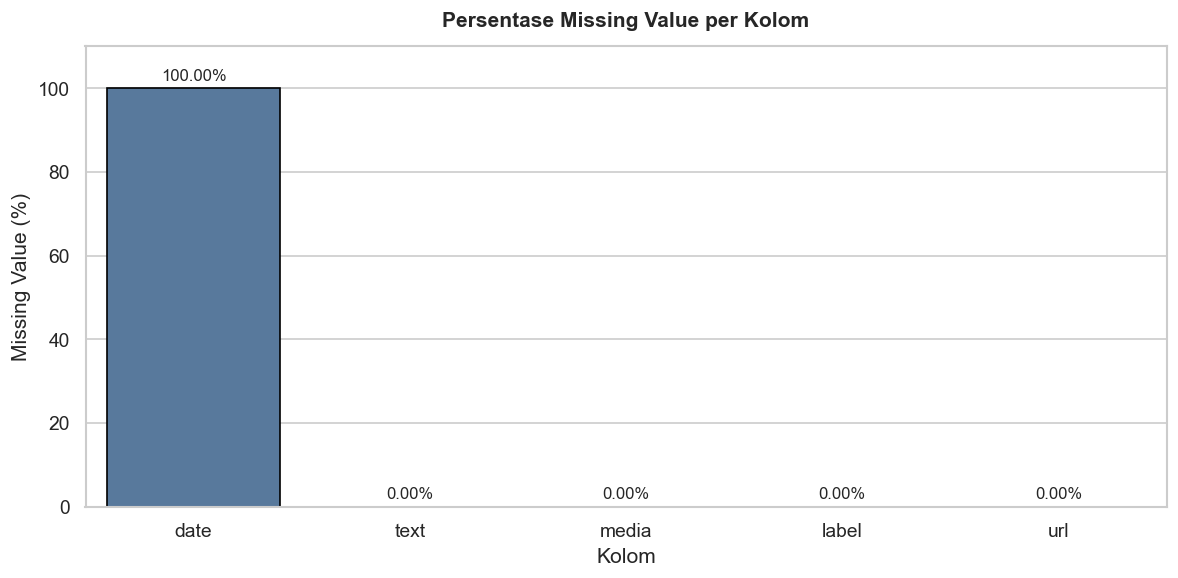

In [ ]:
missing_table = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100).round(2)
}).sort_values('missing_percentage', ascending=False)

display(missing_table)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=missing_table.reset_index(),
    x='index',
    y='missing_percentage',
    color='#4C78A8',
    edgecolor='black',
    ax=ax
)
ax.set_title('Persentase Missing Value per Kolom', pad=12)
ax.set_xlabel('Kolom')
ax.set_ylabel('Missing Value (%)')
ax.set_ylim(0, 110)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_missing_value.png', dpi=300, bbox_inches="tight")
plt.show()

Visualisasi menunjukkan bahwa kolom `date` memiliki missing value 100%, sedangkan kolom utama lainnya lengkap. Karena `date` tidak memberikan informasi yang dapat digunakan, kolom tersebut dihapus agar dataset lebih bersih sebelum EDA lanjutan dan pemodelan.

In [ ]:
if 'date' in df.columns:
    df = df.drop(columns=['date'])

print('Kolom setelah penghapusan date:')
print(df.columns.tolist())
print(f'Shape dataset: {df.shape}')

Kolom setelah penghapusan date:
['text', 'media', 'label', 'url']
Shape dataset: (2276, 4)


## Duplicate Check

Duplikasi diperiksa berdasarkan kolom `text` karena teks artikel merupakan unit observasi utama. Artikel yang duplikat dapat menyebabkan kebocoran informasi jika muncul pada data latih dan data uji.

In [ ]:
duplicate_count = df.duplicated(subset='text').sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f'Jumlah duplicate text     : {duplicate_count}')
print(f'Persentase duplicate text : {duplicate_percentage:.2f}%')

df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Shape setelah duplicate check: {df.shape}')

Jumlah duplicate text     : 0
Persentase duplicate text : 0.00%
Shape setelah duplicate check: (2276, 4)


Hasil duplicate check menunjukkan bahwa tidak terdapat teks artikel yang berulang. Kondisi ini penting karena model dapat dievaluasi dengan lebih adil tanpa risiko mempelajari artikel yang sama pada subset data yang berbeda.

## Exploratory Data Analysis (EDA)

EDA dilakukan secara ringkas untuk memahami karakteristik dataset sebelum preprocessing. Analisis difokuskan pada distribusi label, distribusi media, hubungan media dan label, panjang artikel, kata dominan, serta WordCloud.

In [ ]:
label_order = ['liga_indonesia', 'liga_inggris', 'liga_italia', 'liga_spanyol', 'non_sepak_bola']
media_order = ['detik', 'kompas', 'liputan6']
label_order = [label for label in label_order if label in df['label'].unique()]
media_order = [media for media in media_order if media in df['media'].unique()]

label_palette = {
    'liga_indonesia': '#4C78A8',
    'liga_inggris': '#F58518',
    'liga_italia': '#54A24B',
    'liga_spanyol': '#E45756',
    'non_sepak_bola': '#72B7B2'
}
media_palette = {
    'detik': '#4C78A8',
    'kompas': '#F58518',
    'liputan6': '#54A24B'
}

df['char_len'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()

print(f'Total artikel : {len(df)}')
print(f'Jumlah label  : {df["label"].nunique()}')
print(f'Jumlah media  : {df["media"].nunique()}')

Total artikel : 2276
Jumlah label  : 5
Jumlah media  : 3


### Distribusi Label

,label,count,percentage
0,liga_indonesia,367,16.12
1,liga_inggris,376,16.52
2,liga_italia,386,16.96
3,liga_spanyol,386,16.96
4,non_sepak_bola,761,33.44


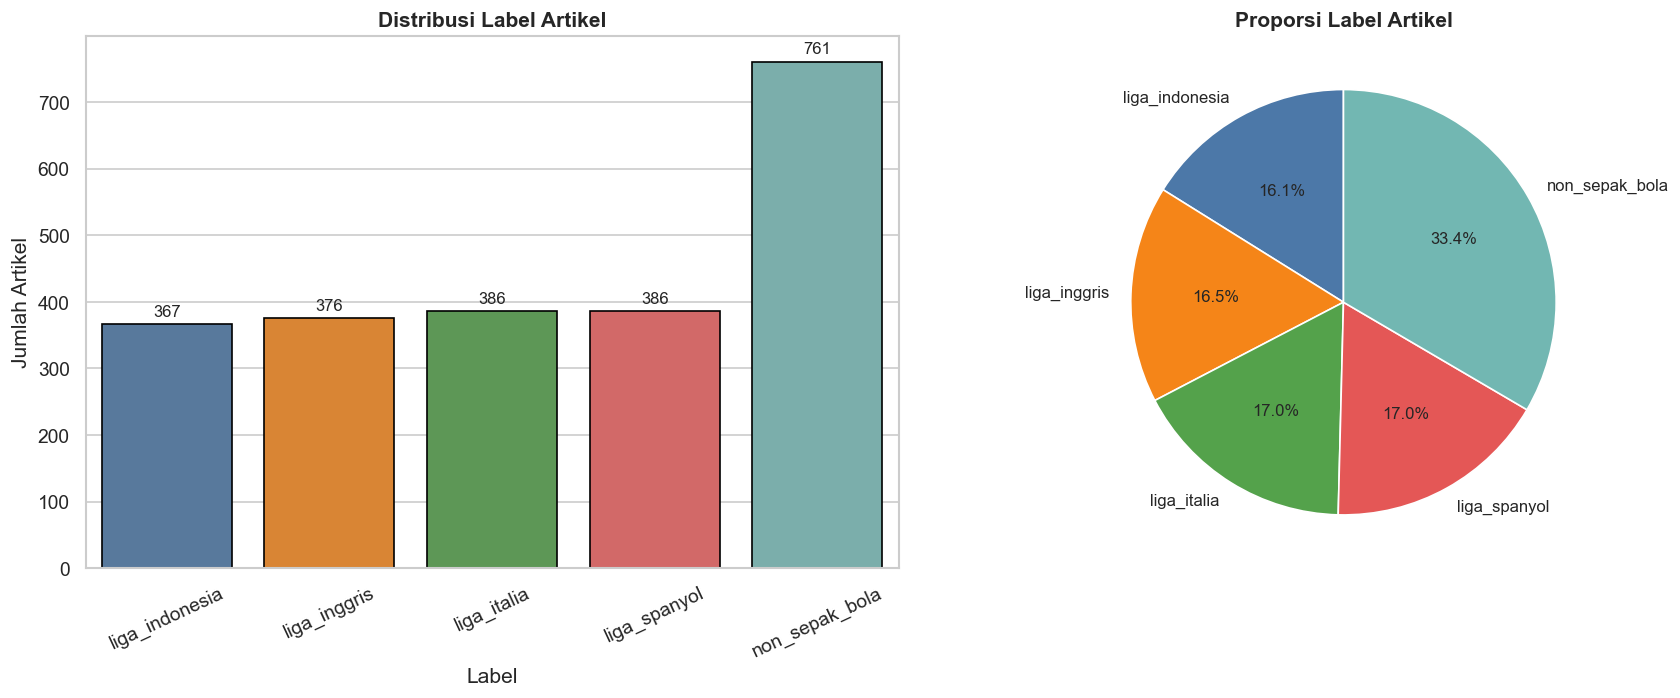

In [ ]:
label_counts = df['label'].value_counts().reindex(label_order)
label_dist = pd.DataFrame({
    'label': label_counts.index,
    'count': label_counts.values,
    'percentage': (label_counts.values / len(df) * 100).round(2)
})

display(label_dist)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = [label_palette[label] for label in label_dist['label']]

sns.barplot(data=label_dist, x='label', y='count', palette=colors, edgecolor='black', ax=axes[0])
axes[0].set_title('Distribusi Label Artikel')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].tick_params(axis='x', rotation=25)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3, fontsize=10)

axes[1].pie(
    label_dist['count'],
    labels=label_dist['label'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10}
)
axes[1].set_title('Proporsi Label Artikel')

plt.tight_layout()
plt.savefig('dist_label.png', dpi=300, bbox_inches="tight")
plt.savefig(f'{OUTPUT_DIR}/eda_label_distribution.png', dpi=300, bbox_inches="tight")
plt.show()

Distribusi label menunjukkan bahwa kelas `non_sepak_bola` memiliki jumlah artikel paling besar, sedangkan empat kelas liga relatif berdekatan. Pola ini perlu diperhatikan saat evaluasi model karena terdapat ketidakseimbangan kelas, sehingga metrik seperti macro F1-score lebih informatif daripada akurasi saja.

### Distribusi Media

,media,count,percentage
0,detik,1052,46.22
1,kompas,992,43.59
2,liputan6,232,10.19


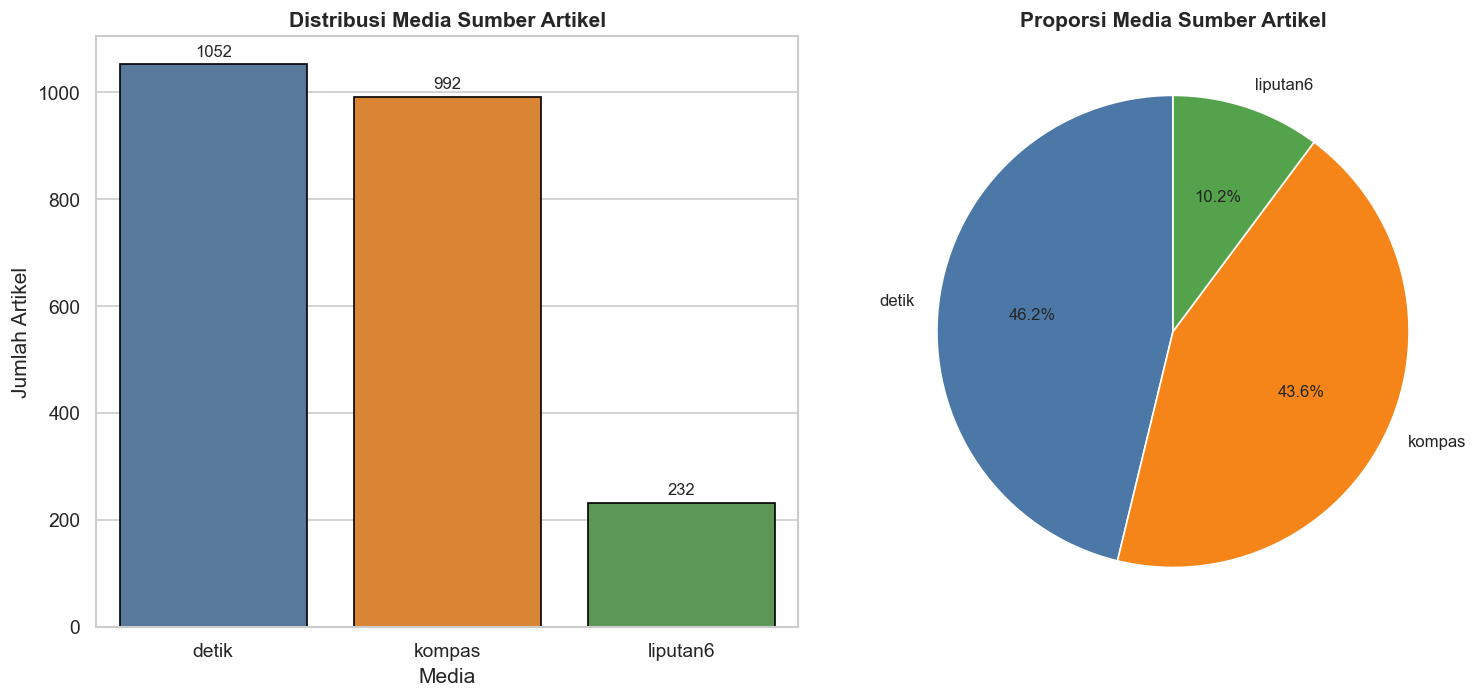

In [ ]:
media_counts = df['media'].value_counts().reindex(media_order)
media_dist = pd.DataFrame({
    'media': media_counts.index,
    'count': media_counts.values,
    'percentage': (media_counts.values / len(df) * 100).round(2)
})

display(media_dist)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
colors = [media_palette[media] for media in media_dist['media']]

sns.barplot(data=media_dist, x='media', y='count', palette=colors, edgecolor='black', ax=axes[0])
axes[0].set_title('Distribusi Media Sumber Artikel')
axes[0].set_xlabel('Media')
axes[0].set_ylabel('Jumlah Artikel')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3, fontsize=10)

axes[1].pie(
    media_dist['count'],
    labels=media_dist['media'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10}
)
axes[1].set_title('Proporsi Media Sumber Artikel')

plt.tight_layout()
plt.savefig('dist_media.png', dpi=300, bbox_inches="tight")
plt.savefig(f'{OUTPUT_DIR}/eda_media_distribution.png', dpi=300, bbox_inches="tight")
plt.show()

Distribusi media menunjukkan bahwa Detik dan Kompas mendominasi jumlah artikel, sedangkan Liputan6 berjumlah lebih sedikit. Informasi ini penting karena perbedaan gaya penulisan antar media dapat memengaruhi pola teks yang dipelajari oleh model.

### Cross Tabulation Media vs Label

label,liga_indonesia,liga_inggris,liga_italia,liga_spanyol,non_sepak_bola
media,,,,,
detik,100,100,100,100,652
kompas,242,226,236,236,52
liputan6,25,50,50,50,57


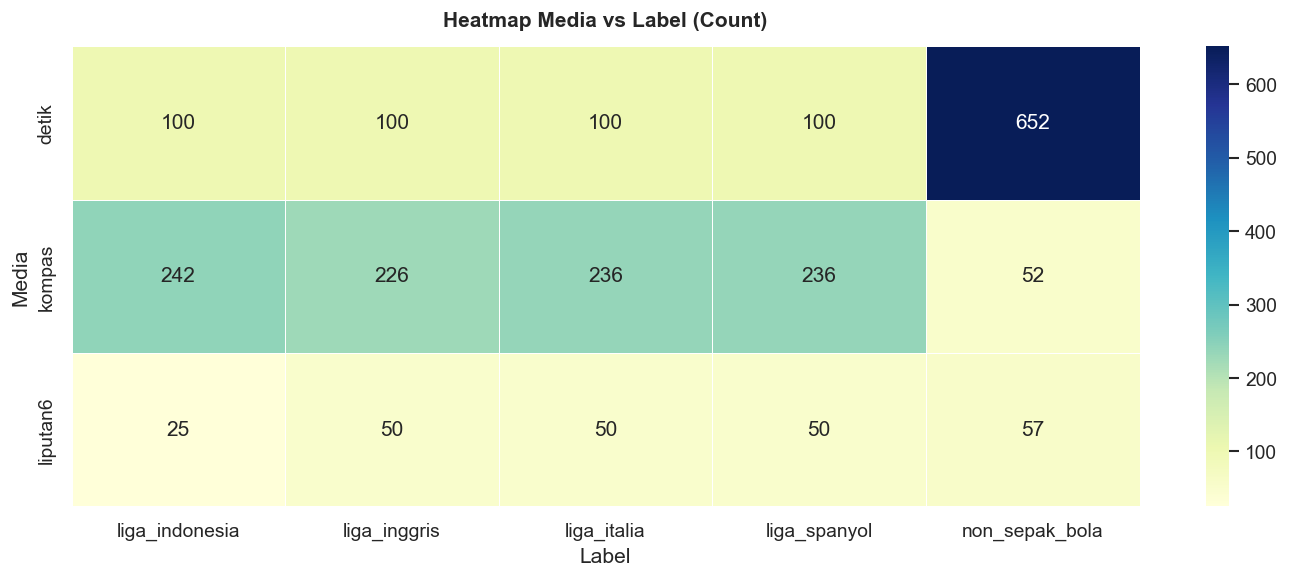

In [ ]:
ct_count = pd.crosstab(df['media'], df['label']).reindex(index=media_order, columns=label_order)

display(ct_count)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    ct_count,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)
ax.set_title('Heatmap Media vs Label (Count)', pad=12)
ax.set_xlabel('Label')
ax.set_ylabel('Media')
plt.tight_layout()
plt.savefig('crosstab_media_label.png', dpi=300, bbox_inches="tight")
plt.savefig(f'{OUTPUT_DIR}/eda_crosstab_heatmap.png', dpi=300, bbox_inches="tight")
plt.show()

Heatmap memperlihatkan sebaran jumlah artikel pada kombinasi media dan label. Visualisasi ini membantu memastikan bahwa setiap label memiliki representasi dari beberapa media, sehingga model tidak hanya belajar dari satu sumber tertentu.

### Panjang Artikel

,char_len,word_count
count,2276.00,2276.00
mean,2309.50,327.16
std,692.10,95.56
min,779.00,104.00
25%,1790.25,258.00
50%,2310.50,328.00
75%,2765.25,387.00
max,7038.00,1004.00


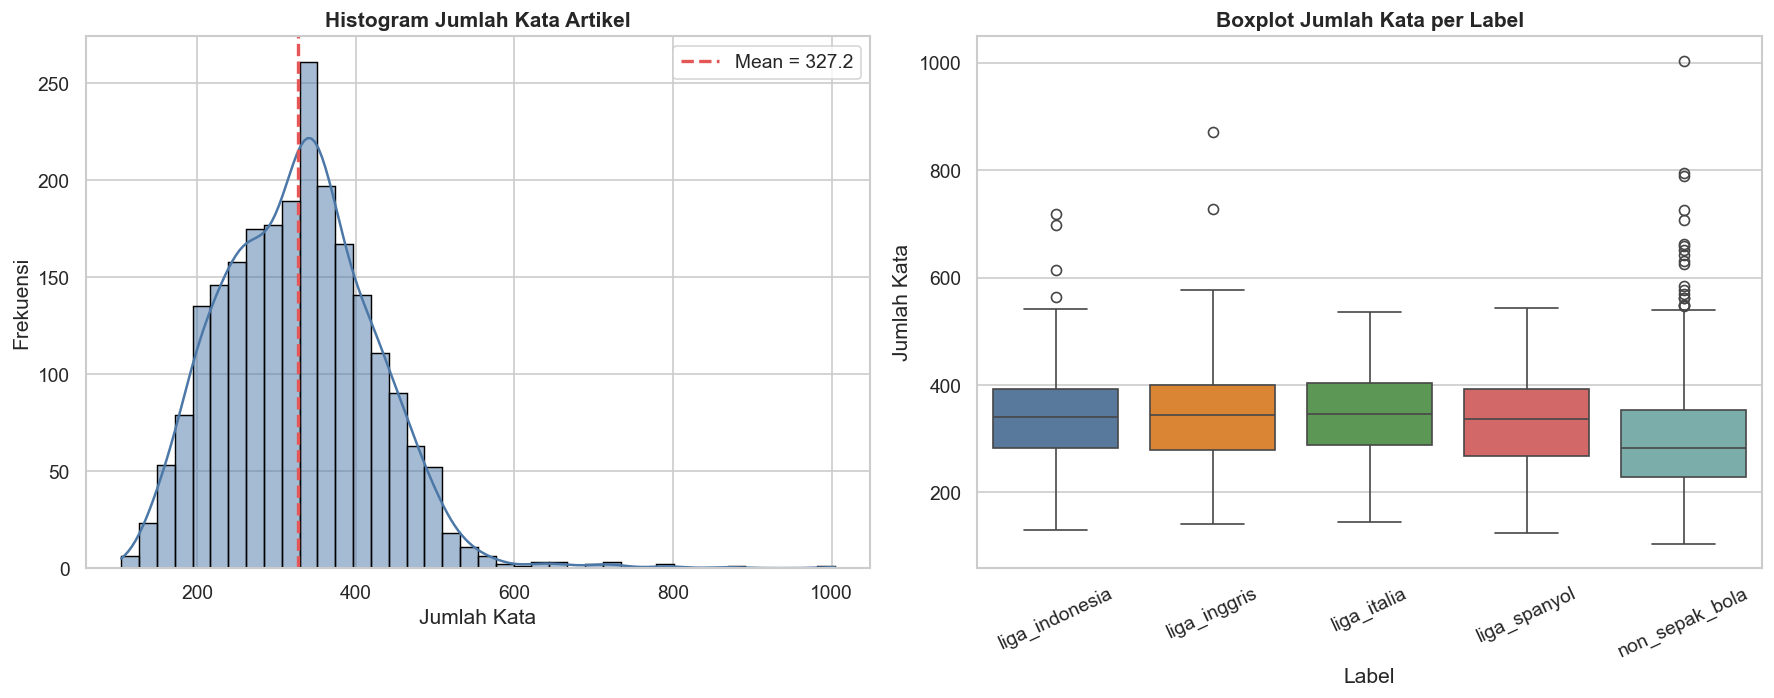

In [ ]:
length_summary = df[['char_len', 'word_count']].describe().round(2)
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['word_count'], bins=40, kde=True, color='#4C78A8', edgecolor='black', ax=axes[0])
axes[0].axvline(df['word_count'].mean(), color='#E45756', linestyle='--', linewidth=2, label=f'Mean = {df["word_count"].mean():.1f}')
axes[0].set_title('Histogram Jumlah Kata Artikel')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

sns.boxplot(data=df, x='label', y='word_count', order=label_order, palette=label_palette, ax=axes[1])
axes[1].set_title('Boxplot Jumlah Kata per Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah Kata')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('text_length.png', dpi=300, bbox_inches="tight")
plt.savefig(f'{OUTPUT_DIR}/eda_word_count_distribution.png', dpi=300, bbox_inches="tight")
plt.show()

Histogram menunjukkan variasi panjang artikel berdasarkan jumlah kata, sedangkan garis rata-rata memberi gambaran pusat distribusi. Boxplot per label penting untuk melihat apakah ada kelas yang cenderung memiliki artikel lebih panjang, karena panjang teks dapat memengaruhi proses tokenisasi dan pemilihan `max_length` pada model LLM.

### Top 20 Kata Sebelum Preprocessing

,word,frequency
0,di,16996
1,yang,12953
2,dan,11808
3,dengan,7430
4,ini,7266
5,dari,6227
6,untuk,6130
7,juga,5840
8,2026,5694
9,pada,5230


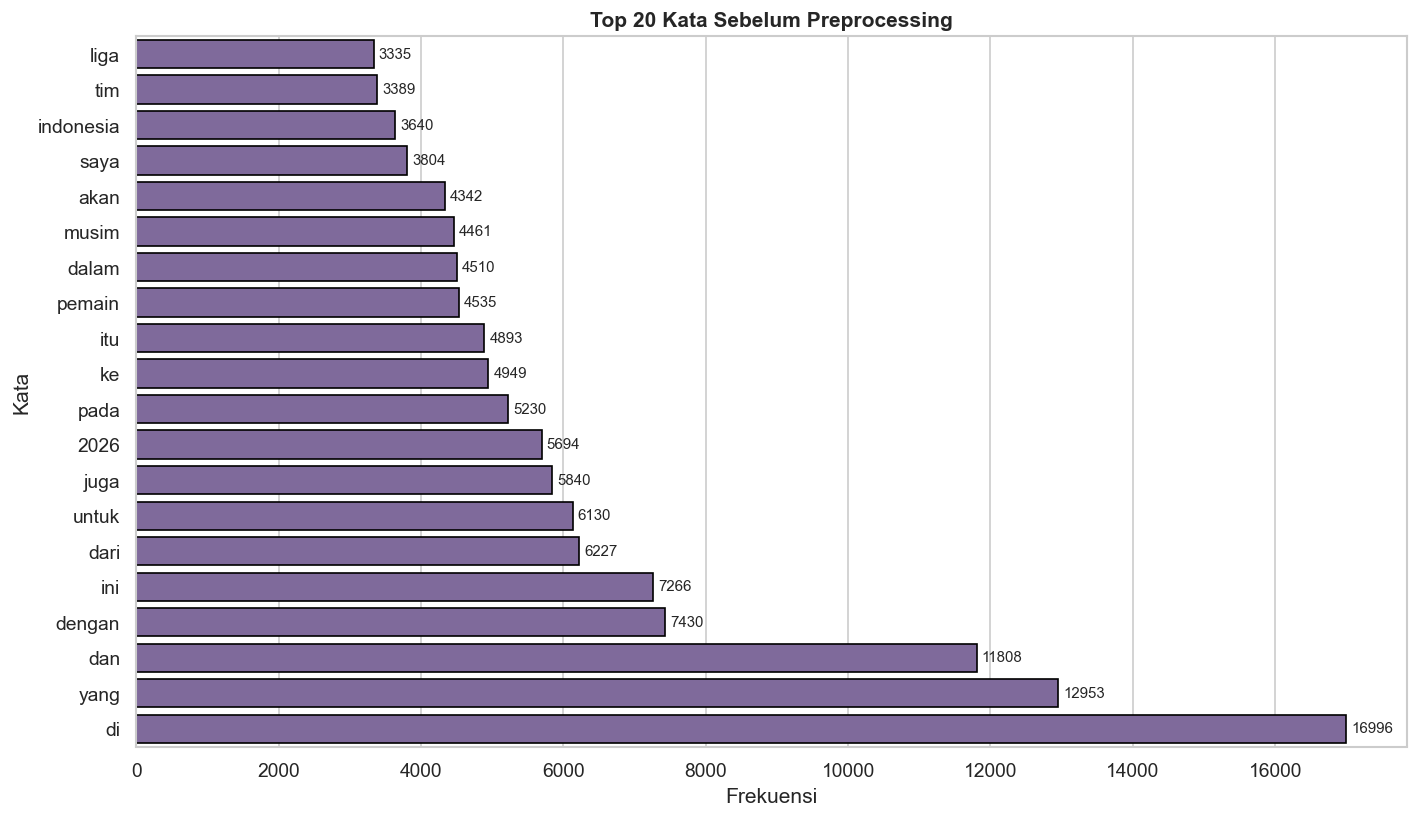

In [ ]:
raw_tokens = df['text'].astype(str).str.lower().str.findall(r'(?u)\b\w+\b')
flat_tokens = [token for tokens in raw_tokens for token in tokens]
top20_words = pd.DataFrame(Counter(flat_tokens).most_common(20), columns=['word', 'frequency'])

display(top20_words)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top20_words.sort_values('frequency'), x='frequency', y='word', color='#7E62A3', edgecolor='black', ax=ax)
ax.set_title('Top 20 Kata Sebelum Preprocessing')
ax.set_xlabel('Frekuensi')
ax.set_ylabel('Kata')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('top20_words_before.png', dpi=300, bbox_inches="tight")
plt.savefig(f'{OUTPUT_DIR}/eda_top20_words_before.png', dpi=300, bbox_inches="tight")
plt.show()

Top 20 kata sebelum preprocessing masih memuat kata umum yang sering muncul dalam struktur berita. Hasil ini mendukung kebutuhan preprocessing seperti stopword removal dan normalisasi agar teks yang masuk ke tahap analisis berikutnya lebih informatif.

### WordCloud Sebelum Preprocessing

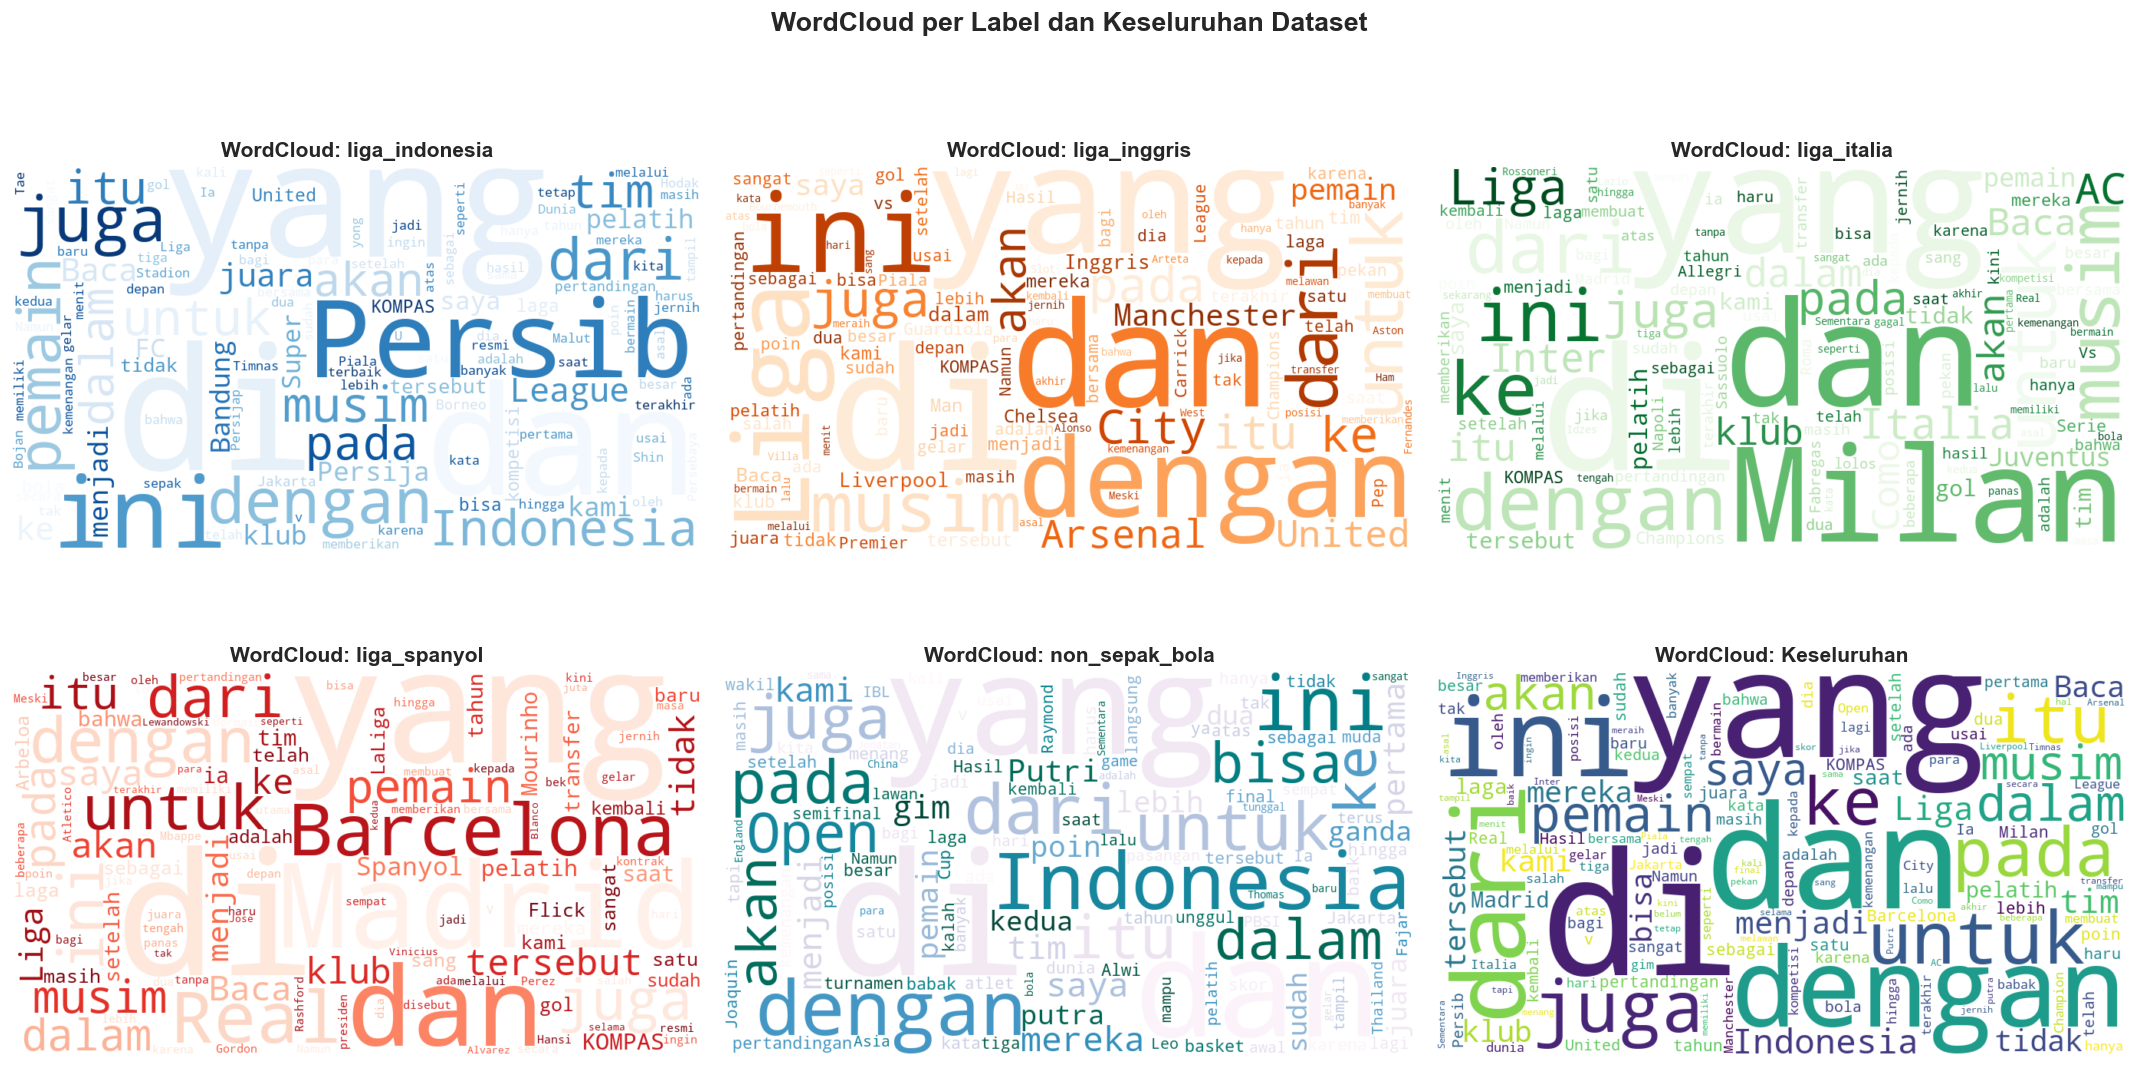

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
wordcloud_colormaps = {
    'liga_indonesia': 'Blues',
    'liga_inggris': 'Oranges',
    'liga_italia': 'Greens',
    'liga_spanyol': 'Reds',
    'non_sepak_bola': 'PuBuGn'
}

for i, label in enumerate(label_order):
    label_text = ' '.join(df.loc[df['label'] == label, 'text'].astype(str))
    wc = WordCloud(
        width=900,
        height=500,
        background_color='white',
        max_words=120,
        colormap=wordcloud_colormaps.get(label, 'viridis'),
        collocations=False,
        random_state=42
    ).generate(label_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'WordCloud: {label}')
    axes[i].axis('off')

all_text = ' '.join(df['text'].astype(str))
wc_all = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=150,
    colormap='viridis',
    collocations=False,
    random_state=42
).generate(all_text)
axes[len(label_order)].imshow(wc_all, interpolation='bilinear')
axes[len(label_order)].set_title('WordCloud: Keseluruhan')
axes[len(label_order)].axis('off')

for j in range(len(label_order) + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('WordCloud per Label dan Keseluruhan Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_labels.png', dpi=300, bbox_inches="tight")
plt.savefig(f'{OUTPUT_DIR}/eda_wordcloud_labels.png', dpi=300, bbox_inches="tight")
plt.show()

WordCloud memberikan gambaran visual mengenai kata yang dominan pada setiap label dan keseluruhan dataset. Karena visualisasi ini dibuat sebelum preprocessing, sebagian kata umum masih muncul dan akan ditangani pada tahap pembersihan teks.

### Contoh Artikel Sebelum Preprocessing

Sebelum dilakukan proses preprocessing, beberapa contoh artikel ditampilkan untuk memberikan gambaran kondisi awal data hasil web scraping. Tahap ini memudahkan perbandingan dengan hasil setelah proses cleansing, tokenization, stopword removal, dan stemming pada bagian preprocessing.

In [ ]:
print("=" * 100)
print("CONTOH ARTIKEL SEBELUM PREPROCESSING")
print("=" * 100)

sample_df = df[['media', 'label', 'text']].head(3)

for i, row in sample_df.iterrows():
    print(f"\nContoh Artikel {i+1}")
    print("-" * 100)
    print(f"Media : {row['media']}")
    print(f"Label : {row['label']}")
    print()
    print("Original Text:")
    print(row['text'])
    print("-" * 100)

CONTOH ARTIKEL SEBELUM PREPROCESSING

Contoh Artikel 1
----------------------------------------------------------------------------------------------------
Media : detik
Label : liga_inggris

Original Text:
Enzo Fernandez dan Joao Pedro Mau Cabut dari Chelsea?. Rumor transfer dari Chelsea. Dua pemain skuad utamanya, Enzo Fernandez dan Joao Pedro kabarnya mau pergi!
Chelsea babak belur di musim 2025/26. Dua kali ganti manajer, Si Biru gagal dapat trofi.
Chelsea kalah dari Man City di final Piala FA. Mereka sementara duduk di peringkat kedelapan klasemen Liga Inggris, cuma tersisa kans main di UEFA Conference League atau di Liga Europa musim depan.
Xabi Alonso sudah didatangkan jadi manajer baru Chelsea, mulai bekerja di musim depan. Dirangkum dari media-media Inggris, rumornya Enzo Fernandez dan Joao Pedro malah mau pergi!
Diketahui, Alonso mau dua pemain itu bertahan. Tapi diyakini, Enzo dan Joao sudah cukup gerah dengan performa tim.
Real Madrid dan Manchester City kabarnya tertarik d

## Kesimpulan Exploratory Data Analysis (EDA)

Berdasarkan hasil eksplorasi data, dapat disimpulkan bahwa dataset yang digunakan terdiri dari **2.276 artikel berita olahraga** hasil web scraping dari **tiga media**, yaitu **Detik, Kompas, dan Liputan6**. Setiap artikel memiliki informasi berupa isi berita (`text`), sumber media (`media`), label kategori (`label`), serta URL artikel. Sementara itu, kolom `date` memiliki missing value sebesar **100%**, sehingga tidak digunakan pada proses analisis maupun pemodelan.

Dari sisi kualitas data, dataset berada dalam kondisi yang cukup baik. Tidak ditemukan missing value pada kolom utama (`text`, `media`, `label`, dan `url`) serta tidak terdapat artikel yang duplikat berdasarkan isi teks. Hal ini menunjukkan bahwa data hasil scraping sudah cukup bersih dan siap untuk diproses lebih lanjut.

Distribusi label menunjukkan bahwa kategori **non_sepak_bola** memiliki jumlah artikel paling banyak, yaitu sekitar **33,44%** dari keseluruhan data. Sementara itu, empat kategori liga sepak bola (**Liga Indonesia, Liga Inggris, Liga Italia, dan Liga Spanyol**) memiliki jumlah data yang relatif seimbang, masing-masing sekitar **16–17%**. Kondisi ini menunjukkan adanya sedikit ketidakseimbangan kelas (class imbalance), namun masih dalam batas yang wajar sehingga tetap dapat digunakan untuk proses klasifikasi.

Dari sisi sumber data, artikel paling banyak berasal dari **Detik (46,22%)**, diikuti **Kompas (43,59%)**, sedangkan **Liputan6 (10,19%)** memiliki jumlah artikel yang lebih sedikit. Meskipun demikian, seluruh media tetap berkontribusi terhadap berbagai kategori berita sehingga dataset memiliki variasi sumber penulisan yang cukup baik.

Analisis panjang artikel menunjukkan bahwa sebagian besar berita memiliki panjang sekitar **327 kata** atau sekitar **2.310 karakter**. Walaupun terdapat beberapa artikel yang jauh lebih panjang dibandingkan mayoritas data (outlier), secara umum distribusi panjang artikel masih relatif konsisten pada setiap kategori. Informasi ini nantinya dapat menjadi pertimbangan dalam menentukan parameter seperti **maximum sequence length (`max_length`)** saat proses tokenisasi pada model berbasis Large Language Model (LLM).

Visualisasi **Top 20 Kata** dan **WordCloud** sebelum preprocessing memperlihatkan bahwa kata-kata umum seperti *di*, *yang*, *dan*, *dengan*, serta *ini* masih mendominasi isi artikel. Selain itu, masih terdapat angka, nama tim, dan kata-kata yang sering muncul karena gaya penulisan berita. Temuan ini menunjukkan bahwa proses **text preprocessing** masih diperlukan agar teks menjadi lebih bersih dan kata-kata yang dipertahankan benar-benar merepresentasikan informasi penting dari setiap artikel.

Secara keseluruhan, hasil EDA menunjukkan bahwa dataset memiliki kualitas yang baik, struktur yang jelas, serta distribusi data yang cukup representatif untuk membangun model klasifikasi teks. Oleh karena itu, tahap berikutnya akan difokuskan pada proses **text preprocessing**, meliputi *text cleansing*, *tokenization*, *stopword removal*, dan *stemming*, sehingga data menjadi lebih siap untuk digunakan pada proses pelatihan model LLM.

## 2. Text Preprocessing

Tahap preprocessing dilakukan untuk menyiapkan teks berita sebelum masuk ke proses representasi dan pemodelan. Karena data berasal dari web scraping, teks masih dapat mengandung elemen yang kurang relevan seperti tag HTML, URL, mention, hashtag, angka, tanda baca, emoji, dan spasi berlebih.

Berdasarkan hasil EDA dan audit dataset, ditemukan juga beberapa artefak khas web scraping, seperti prefix nama media, bagian `Baca juga`, kode editor, advertisement, serta tautan atau embed media sosial. Elemen-elemen tersebut tidak merepresentasikan isi utama berita, sehingga dilakukan cleansing tambahan agar model lebih berfokus pada konten artikel.

Pada notebook ini, alur preprocessing tetap dibuat sederhana sesuai kebutuhan tugas NLP, yaitu Case Folding, Remove Scraping Artifacts, Remove HTML, Remove URL, Remove Mention, Remove Hashtag, Remove Number, Remove Punctuation, Remove Emoji, Remove Extra Whitespace, Tokenization, Stopword Removal, dan Stemming menggunakan Sastrawi. Hasil akhirnya disimpan pada kolom `clean_text`, sedangkan kolom `text` tetap dipertahankan sebagai teks asli.


### Fungsi Preprocessing

Fungsi berikut menjalankan tahapan preprocessing secara berurutan. Selain cleansing umum, ditambahkan fungsi `remove_scraping_artifacts()` untuk menghapus boilerplate yang memang ditemukan pada dataset, seperti prefix media, penanda artikel terkait, advertisement, ajakan video, kode editor, dan sisa URL. Penambahan ini tetap termasuk tahap cleansing dan tidak mengubah tujuan utama preprocessing.


In [ ]:
import re
def remove_scraping_artifacts(text):
    text = re.sub(r'\bkompas\.com\s*-\s*', ' ', text)
    text = re.sub(r'\bliputan6\.com,\s*jakarta\s*-\s*', ' ', text)

    text = re.sub(r'\bbaca\s+juga\s*:\s*', ' ', text)
    text = re.sub(r'\bbaca\s+artikel(?:\s+terkait)?\s*:?\s*', ' ', text)

    text = re.sub(r'\badvertisement\b', ' ', text)

    text = re.sub(r'\btonton\s+juga\s+video\s*:?\s*"[^"]{0,180}"', ' ', text)
    text = re.sub(r'\btonton\s+juga\s+video\s*:?\s*', ' ', text)
    text = re.sub(r'\bsimak\s+video\s*:?\s*', ' ', text)

    text = re.sub(r'\([a-z]{2,5}/[a-z]{2,5}\)', ' ', text)

    text = re.sub(r'pic\.twitter\.com/\S+', ' ', text)

    return text

def preprocess_text(text):
    text = text.lower()
    text = remove_scraping_artifacts(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)

    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE,
    )
    text = emoji_pattern.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

### Penerapan Preprocessing

Preprocessing diterapkan pada seluruh isi kolom `text`. Proses ini dapat membutuhkan waktu karena setiap artikel melalui tahap filtering dan stemming. Oleh karena itu, waktu eksekusi dicatat agar prosesnya lebih mudah dievaluasi ketika notebook dijalankan ulang.

In [ ]:
print('Memulai preprocessing...')

start_time = time.time()
tqdm.pandas()
df['clean_text'] = df['text'].progress_apply(preprocess_text)
end_time = time.time()

preprocessing_time = end_time - start_time
print(f'Preprocessing selesai dalam {preprocessing_time:.2f} detik')
print(f'Shape dataset setelah preprocessing: {df.shape}')

Memulai preprocessing...


100%|██████████| 2276/2276 [00:00<00:00, 3054.36it/s]

Preprocessing selesai dalam 0.75 detik
Shape dataset setelah preprocessing: (2276, 7)


### Validasi Hasil

Setelah kolom `clean_text` terbentuk, perlu dilakukan pengecekan singkat untuk memastikan hasil preprocessing tidak menimbulkan masalah baru. Validasi ini meliputi missing value, teks kosong, duplikasi hasil preprocessing, dan jumlah vocabulary yang tersisa setelah teks dibersihkan.

In [ ]:
clean_missing = df['clean_text'].isna().sum()
clean_empty = (df['clean_text'].astype(str).str.strip() == '').sum()
clean_duplicate = df.duplicated(subset='clean_text').sum()
clean_tokens = ' '.join(df['clean_text'].astype(str)).split()
clean_vocabulary = len(set(clean_tokens))

print('=' * 60)
print('VALIDASI HASIL PREPROCESSING')
print('=' * 60)
print(f'Shape dataset                    : {df.shape}')
print(f'Missing value pada clean_text    : {clean_missing}')
print(f'Empty clean_text                 : {clean_empty}')
print(f'Duplicate clean_text             : {clean_duplicate}')
print(f'Total vocabulary clean_text      : {clean_vocabulary}')
print('=' * 60)

VALIDASI HASIL PREPROCESSING
Shape dataset                    : (2276, 7)
Missing value pada clean_text    : 0
Empty clean_text                 : 0
Duplicate clean_text             : 0
Total vocabulary clean_text      : 41551


Hasil validasi memberikan gambaran apakah teks hasil preprocessing sudah layak digunakan pada tahap berikutnya. Jika jumlah teks kosong sangat kecil atau tidak ada, maka proses pembersihan dapat dianggap tidak menghilangkan isi artikel secara berlebihan.

### Preview Dataset Setelah Preprocessing

Preview berikut ditampilkan agar hasil preprocessing dapat dilihat langsung pada level data. Kolom `text` berisi artikel asli, sedangkan `clean_text` berisi versi yang sudah dibersihkan dan akan digunakan pada tahap berikutnya.

In [ ]:
display(df[['text', 'clean_text', 'label']].head())

,text,clean_text,label
0,Enzo Fernandez dan Joao Pedro Mau Cabut dari C...,enzo fernandez dan joao pedro mau cabut dari c...,liga_inggris
1,Liverpool Tertinggal 0-1 dari Aston Villa di B...,liverpool tertinggal 0-1 dari aston villa di b...,liga_inggris
2,Apa Bruno Fernandes Sudah Samakan Rekor Assist...,apa bruno fernandes sudah samakan rekor assist...,liga_inggris
3,Schmeichel Sebut Alasan Arsenal Tak Pantas Pun...,schmeichel sebut alasan arsenal tak pantas pun...,liga_inggris
4,"MU Lolos UCL, Sejumlah Pemain Naik Gaji!. Tagi...","mu lolos ucl, sejumlah pemain naik gaji!. tagi...",liga_inggris


### Contoh Sebelum vs Sesudah

Contoh berikut memperlihatkan perubahan teks secara lebih detail. Perbandingan ini membantu memastikan bahwa proses preprocessing tidak hanya berjalan secara teknis, tetapi juga menghasilkan teks yang lebih ringkas dan lebih fokus pada kata-kata penting.

In [ ]:
for number, idx in enumerate(df.head(3).index, start=1):
    original_text = str(df.loc[idx, 'text'])
    clean_text = str(df.loc[idx, 'clean_text'])
    original_word_count = len(original_text.split())
    clean_word_count = len(clean_text.split())

    print('=' * 80)
    print(f'Contoh {number}')
    print('-' * 80)
    print(f'Media : {df.loc[idx, "media"]}')
    print(f'Label : {df.loc[idx, "label"]}')
    print()
    print('Original Text:')
    print(original_text[:700] + ('...' if len(original_text) > 700 else ''))
    print()
    print('Clean Text:')
    print(clean_text[:700] + ('...' if len(clean_text) > 700 else ''))
    print()
    print(f'Jumlah kata sebelum : {original_word_count}')
    print(f'Jumlah kata sesudah : {clean_word_count}')
    print('=' * 80)
    print()

Contoh 1
--------------------------------------------------------------------------------
Media : detik
Label : liga_inggris

Original Text:
Enzo Fernandez dan Joao Pedro Mau Cabut dari Chelsea?. Rumor transfer dari Chelsea. Dua pemain skuad utamanya, Enzo Fernandez dan Joao Pedro kabarnya mau pergi!
Chelsea babak belur di musim 2025/26. Dua kali ganti manajer, Si Biru gagal dapat trofi.
Chelsea kalah dari Man City di final Piala FA. Mereka sementara duduk di peringkat kedelapan klasemen Liga Inggris, cuma tersisa kans main di UEFA Conference League atau di Liga Europa musim depan.
Xabi Alonso sudah didatangkan jadi manajer baru Chelsea, mulai bekerja di musim depan. Dirangkum dari media-media Inggris, rumornya Enzo Fernandez dan Joao Pedro malah mau pergi!
Diketahui, Alonso mau dua pemain itu bertahan. Tapi diyakini, Enzo dan Jo...

Clean Text:
enzo fernandez dan joao pedro mau cabut dari chelsea?. rumor transfer dari chelsea. dua pemain skuad utamanya, enzo fernandez dan joao pedro k

### Statistik Sebelum vs Sesudah

Pada bagian ini, jumlah kata sebelum dan sesudah preprocessing dibandingkan untuk melihat dampak proses pembersihan terhadap panjang teks. Perbandingan ini tidak digunakan sebagai fitur tambahan pada model, tetapi hanya sebagai evaluasi untuk memastikan bahwa preprocessing berhasil menghilangkan elemen-elemen yang tidak relevan tanpa mengubah isi utama artikel.

In [ ]:
word_count_comparison = pd.DataFrame({
    'Original Word Count': df['text'].astype(str).str.split().str.len(),
    'Clean Word Count': df['clean_text'].astype(str).str.split().str.len()
})

avg_original_words = word_count_comparison['Original Word Count'].mean()
avg_clean_words = word_count_comparison['Clean Word Count'].mean()
avg_removed_words = avg_original_words - avg_clean_words
reduction_percentage = (avg_removed_words / avg_original_words) * 100

preprocessing_summary = pd.DataFrame({
    'Metrik': [
        'Rata-rata kata sebelum preprocessing',
        'Rata-rata kata sesudah preprocessing',
        'Rata-rata kata yang terhapus',
        'Persentase reduksi jumlah kata'
    ],
    'Nilai': [
        round(avg_original_words, 2),
        round(avg_clean_words, 2),
        round(avg_removed_words, 2),
        f'{reduction_percentage:.2f}%'
    ]
})

display(preprocessing_summary)
display(word_count_comparison.describe().round(2))

,Metrik,Nilai
0,Rata-rata kata sebelum preprocessing,327.16
1,Rata-rata kata sesudah preprocessing,323.33
2,Rata-rata kata yang terhapus,3.84
3,Persentase reduksi jumlah kata,1.17%


,Original Word Count,Clean Word Count
count,2276.00,2276.00
mean,327.16,323.33
std,95.56,93.94
min,104.00,103.00
25%,258.00,256.00
50%,328.00,324.00
75%,387.00,382.00
max,1004.00,1003.00


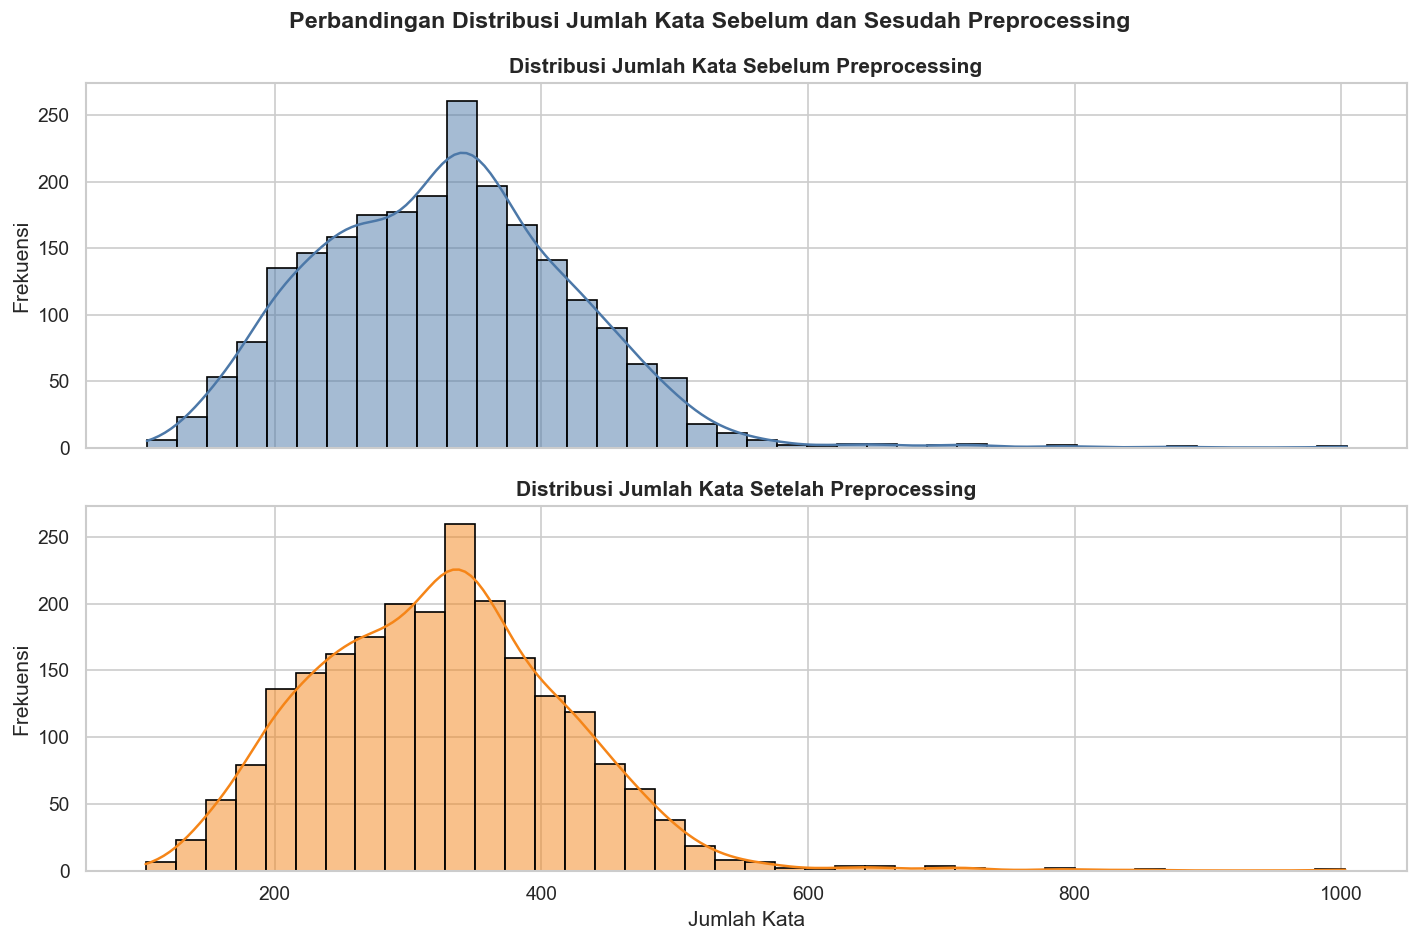

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.histplot(
    word_count_comparison['Original Word Count'],
    bins=40,
    kde=True,
    color='#4C78A8',
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title('Distribusi Jumlah Kata Sebelum Preprocessing')
axes[0].set_ylabel('Frekuensi')

sns.histplot(
    word_count_comparison['Clean Word Count'],
    bins=40,
    kde=True,
    color='#F58518',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Distribusi Jumlah Kata Setelah Preprocessing')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Perbandingan Distribusi Jumlah Kata Sebelum dan Sesudah Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preprocessing_word_count_comparison.png', dpi=300, bbox_inches="tight")
plt.show()

Dari perbandingan jumlah kata terlihat bahwa preprocessing hanya mengurangi panjang teks dalam jumlah yang relatif kecil, yaitu sekitar **1,17%**. Hal ini menunjukkan bahwa proses yang dilakukan berfokus pada pembersihan noise hasil web scraping, seperti URL, HTML, emoji, mention, dan artefak lainnya, tanpa menghapus sebagian besar isi artikel. Dengan demikian, struktur kalimat dan konteks bahasa tetap dipertahankan sehingga lebih sesuai untuk proses tokenisasi menggunakan IndoBERT.

### Top 20 Kata Setelah Preprocessing

Frekuensi kata setelah preprocessing digunakan untuk melihat token yang paling sering muncul pada kolom `clean_text`. Analisis ini bertujuan untuk mengevaluasi hasil preprocessing serta memastikan bahwa teks yang digunakan sebagai input model telah terbebas dari noise hasil web scraping, namun tetap mempertahankan konteks bahasa Indonesia.

,word,frequency
0,di,16883
1,yang,12844
2,dan,11747
3,dengan,7392
4,dari,6204
5,untuk,6070
6,pada,5190
7,ini,4724
8,dalam,4467
9,akan,4329


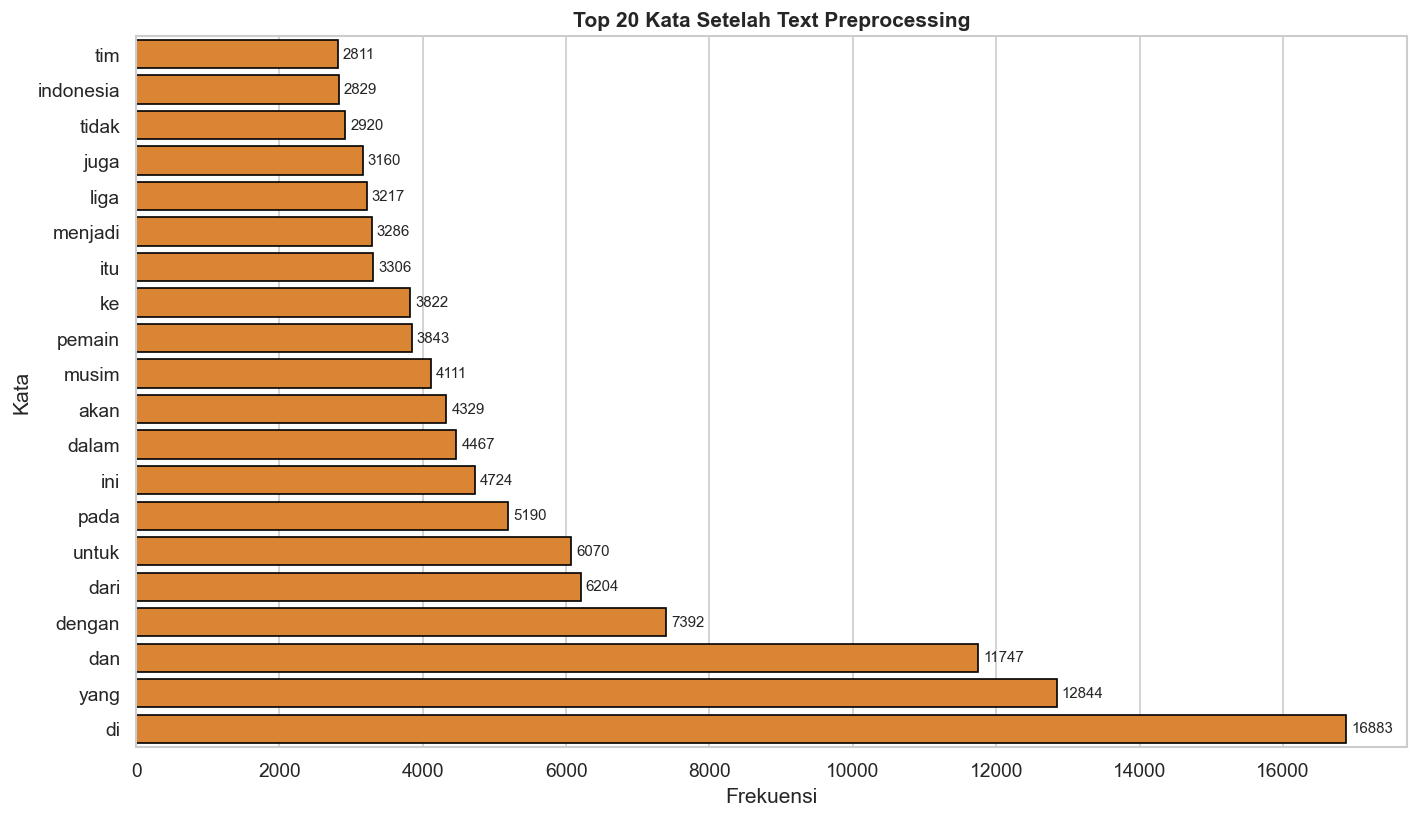

In [ ]:
all_words_clean = ' '.join(df['clean_text'].astype(str)).split()
word_freq_clean = Counter(all_words_clean).most_common(20)
top20_clean_words = pd.DataFrame(word_freq_clean, columns=['word', 'frequency'])

display(top20_clean_words)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=top20_clean_words.sort_values('frequency'),
    x='frequency',
    y='word',
    color='#F58518',
    edgecolor='black',
    ax=ax
)
ax.set_title('Top 20 Kata Setelah Text Preprocessing')
ax.set_xlabel('Frekuensi')
ax.set_ylabel('Kata')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preprocessing_top20_words_after.png', dpi=300, bbox_inches="tight")
plt.show()

Top 20 kata setelah preprocessing menunjukkan bahwa kata-kata umum seperti *di*, *yang*, *dan*, *dengan*, dan *untuk* masih sering muncul. Hal ini merupakan hasil yang diharapkan karena penelitian ini menerapkan **light preprocessing**, sehingga stopword tidak dihapus. Pendekatan tersebut dipilih agar struktur kalimat dan hubungan antar kata tetap terjaga, sesuai dengan karakteristik IndoBERT yang memanfaatkan informasi kontekstual selama proses pemahaman bahasa. Selain itu, kata-kata yang berkaitan dengan topik berita olahraga, seperti **musim**, **pemain**, **liga**, **tim**, dan **Indonesia**, juga terlihat dominan sehingga menunjukkan bahwa isi utama artikel tetap dipertahankan setelah proses pembersihan.

### WordCloud Setelah Preprocessing

WordCloud dibuat hanya dari kolom `clean_text`. Visualisasi ini digunakan sebagai pemeriksaan visual sederhana untuk melihat kata dominan setelah teks melalui proses pembersihan, filtering, dan stemming.

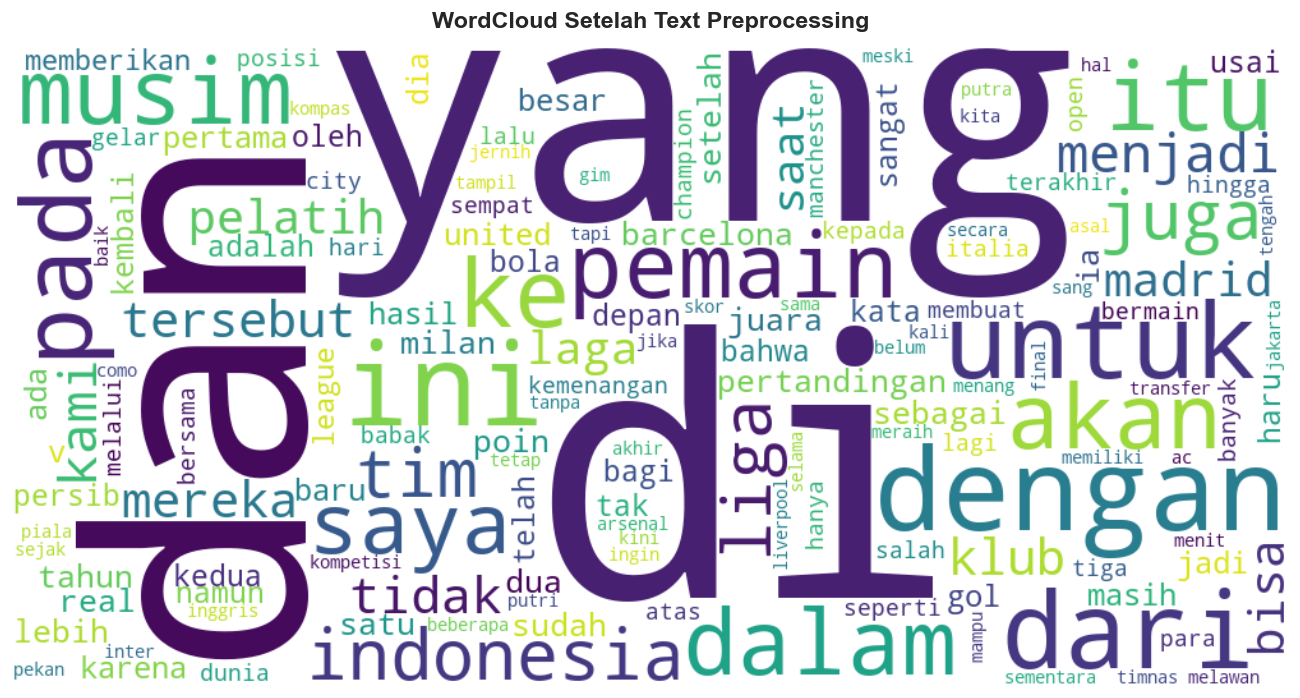

In [ ]:
clean_text_all = ' '.join(df['clean_text'].astype(str))

wordcloud_clean = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=150,
    colormap='viridis',
    collocations=False,
    random_state=42
).generate(clean_text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.title('WordCloud Setelah Text Preprocessing', fontsize=14, fontweight='bold', pad=12)
plt.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preprocessing_wordcloud_clean_text.png', dpi=300, bbox_inches="tight")
plt.show()

WordCloud setelah preprocessing memperlihatkan distribusi kata-kata yang paling sering muncul pada kolom `clean_text`. Terlihat bahwa kata-kata umum masih mendominasi visualisasi karena stopword sengaja dipertahankan dalam proses preprocessing. Kondisi ini sesuai dengan tujuan penggunaan light preprocessing pada IndoBERT, yaitu menjaga konteks kalimat tetap utuh agar representasi bahasa yang dipelajari oleh model tetap mendekati data saat proses pretraining.

### Kesimpulan Text Preprocessing

Tahap text preprocessing berhasil membersihkan teks berita hasil web scraping sehingga menjadi lebih konsisten sebelum digunakan pada proses klasifikasi menggunakan IndoBERT. Berbeda dengan pendekatan preprocessing agresif, penelitian ini menerapkan **light preprocessing** yang mempertahankan struktur alami kalimat agar sesuai dengan karakteristik pretrained language model. Tahapan yang dilakukan meliputi **case folding**, **penghapusan artefak hasil scraping (boilerplate)**, **HTML**, **URL**, **mention**, **simbol hashtag**, **emoji**, serta **spasi berlebih**. Sementara itu, **angka, tanda baca, stopword, dan proses stemming sengaja dipertahankan** agar informasi kontekstual pada teks tidak hilang. Seluruh hasil preprocessing disimpan pada kolom `clean_text`, sedangkan kolom `text` tetap dipertahankan sebagai referensi.

Berdasarkan hasil validasi, proses preprocessing berjalan dengan baik. Kolom `clean_text` berhasil dibuat tanpa menghasilkan **missing value**, **teks kosong**, maupun **duplicate text**, sehingga seluruh **2.276 artikel** tetap dapat digunakan pada tahap pemodelan. Selain itu, diperoleh sekitar **41.551 kosakata unik (vocabulary)** yang menunjukkan bahwa variasi informasi pada dataset tetap terjaga setelah proses pembersihan.

Perbandingan jumlah kata sebelum dan sesudah preprocessing menunjukkan bahwa rata-rata panjang artikel hanya berkurang dari **327,16 kata** menjadi **323,33 kata**, atau sekitar **1,17%**. Hasil ini menunjukkan bahwa preprocessing yang diterapkan hanya menghilangkan elemen-elemen yang tidak relevan akibat proses web scraping, tanpa mengubah isi utama maupun struktur kalimat pada artikel.

Visualisasi **Top 20 Kata** dan **WordCloud** setelah preprocessing juga memperlihatkan bahwa kata-kata umum seperti *di*, *yang*, *dan*, *dengan*, dan *untuk* masih sering muncul. Kondisi ini memang diharapkan karena model **IndoBERT** memanfaatkan hubungan antar kata dalam suatu kalimat untuk memahami konteks. Oleh karena itu, stopword tidak dihapus sehingga informasi linguistik tetap dipertahankan sesuai dengan proses pretraining IndoBERT.

Secara keseluruhan, tahap preprocessing berhasil menghasilkan teks yang lebih bersih tanpa menghilangkan informasi penting yang dibutuhkan oleh model berbasis Transformer. Pendekatan **light preprocessing** ini menghasilkan representasi teks yang lebih sesuai untuk proses tokenisasi menggunakan tokenizer IndoBERT, sehingga model dapat memanfaatkan konteks kalimat secara lebih optimal pada tahap fine-tuning dan klasifikasi berita olahraga.

### Menyimpan Dataset Hasil Preprocessing

Dataset yang telah melalui seluruh tahapan preprocessing disimpan agar dapat langsung digunakan pada proses pemodelan tanpa perlu menjalankan ulang preprocessing. Dataset yang disimpan tetap mempertahankan kolom asli (`text`) dan menambahkan kolom `clean_text` sebagai hasil preprocessing.

In [28]:
PREPROCESSED_PATH = os.path.join(OUTPUT_DIR, "dataset_preprocessed.csv")

df.to_csv(
    PREPROCESSED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(f"Lokasi      : {PREPROCESSED_PATH}")
print(f"Jumlah data : {len(df)}")
print(f"Kolom       : {list(df.columns)}")

Lokasi      : output\dataset_preprocessed.csv
Jumlah data : 2276
Kolom       : ['text', 'media', 'label', 'url', 'char_len', 'word_count', 'clean_text']


## Label Encoding

Label encoding dilakukan untuk mengubah label kategorikal menjadi nilai numerik agar dapat digunakan pada proses training BERT. Pada notebook ini, encoding dibuat secara manual menggunakan dictionary agar mapping label untuk Model 1 dan Model 2 tetap jelas serta mudah dicek kembali.

Tahap ini diperlukan karena model tidak dapat langsung memproses label dalam bentuk teks seperti `liga_inggris` atau `non_sepak_bola`. Untuk menyesuaikan dengan soal UAS, encoding dibuat untuk dua skenario, yaitu Model 1 dengan 5 kelas secara langsung dan Model 2 dengan alur two-stage.

### Mapping Label

Mapping label ditentukan secara manual agar urutan kelas konsisten dari tahap training sampai evaluasi. Cara ini juga memudahkan pembacaan hasil prediksi karena setiap angka memiliki pasangan label yang jelas.

In [ ]:
labels_model1 = {
    'liga_inggris'  : 0,
    'liga_italia'   : 1,
    'liga_spanyol'  : 2,
    'liga_indonesia': 3,
    'non_sepak_bola': 4
}

labels_stage1 = {
    'sepak_bola'    : 0,
    'non_sepak_bola': 1
}

labels_stage2 = {
    'liga_inggris'  : 0,
    'liga_italia'   : 1,
    'liga_spanyol'  : 2,
    'liga_indonesia': 3
}

print('Mapping Label Model 1:')
print(labels_model1)
print()
print('Mapping Label Model 2 Stage 1:')
print(labels_stage1)
print()
print('Mapping Label Model 2 Stage 2:')
print(labels_stage2)


Mapping Label Model 1:
{'liga_inggris': 0, 'liga_italia': 1, 'liga_spanyol': 2, 'liga_indonesia': 3, 'non_sepak_bola': 4}

Mapping Label Model 2 Stage 1:
{'sepak_bola': 0, 'non_sepak_bola': 1}

Mapping Label Model 2 Stage 2:
{'liga_inggris': 0, 'liga_italia': 1, 'liga_spanyol': 2, 'liga_indonesia': 3}


### Label Encoding Model 1

Model 1 melakukan klasifikasi langsung ke dalam 5 kelas. Oleh karena itu, seluruh data tetap digunakan dan setiap nilai pada kolom `label` dipetakan ke kolom numerik `label_model1`.

In [ ]:
df['label_model1'] = df['label'].map(labels_model1)

print('Distribusi label_model1:')
print(df[['label', 'label_model1']].value_counts().sort_index())

Distribusi label_model1:
label           label_model1
liga_indonesia  3               367
liga_inggris    0               376
liga_italia     1               386
liga_spanyol    2               386
non_sepak_bola  4               761
Name: count, dtype: int64


Encoding Model 1 mempertahankan seluruh kelas pada dataset. Kolom `label_model1` akan menjadi target saat model BERT dilatih untuk klasifikasi 5 kelas secara langsung.

### Label Encoding Model 2

Model 2 menggunakan pendekatan two-stage. Stage 1 membedakan artikel sepak bola dan non-sepak bola, sedangkan Stage 2 hanya memproses artikel sepak bola untuk diklasifikasikan ke empat liga.

In [ ]:
df['label_stage1'] = df['label'].apply(
    lambda label: labels_stage1['non_sepak_bola'] if label == 'non_sepak_bola' else labels_stage1['sepak_bola']
)

df_stage2 = df[df['label'] != 'non_sepak_bola'].copy()
df_stage2['label_stage2'] = df_stage2['label'].map(labels_stage2)

print('Distribusi label_stage1:')
print(df[['label', 'label_stage1']].value_counts().sort_index())
print()
print('Jumlah data Stage 2 (hanya sepak bola):')
print(len(df_stage2))
print()
print('Distribusi label_stage2:')
print(df_stage2[['label', 'label_stage2']].value_counts().sort_index())


Distribusi label_stage1:
label           label_stage1
liga_indonesia  0               367
liga_inggris    0               376
liga_italia     0               386
liga_spanyol    0               386
non_sepak_bola  1               761
Name: count, dtype: int64

Jumlah data Stage 2 (hanya sepak bola):
1515

Distribusi label_stage2:
label           label_stage2
liga_indonesia  3               367
liga_inggris    0               376
liga_italia     1               386
liga_spanyol    2               386
Name: count, dtype: int64


Pada Stage 2, data `non_sepak_bola` tidak digunakan karena kelas tersebut sudah dipisahkan pada Stage 1. Dengan cara ini, model kedua hanya fokus membedakan liga sepak bola tanpa terganggu oleh artikel olahraga non-sepak bola.

### Validasi

Validasi dilakukan untuk memastikan semua label berhasil dikonversi menjadi angka dan tidak ada nilai kosong setelah proses encoding. Pengecekan ini penting karena kesalahan mapping label dapat menyebabkan error pada training atau evaluasi model.

In [ ]:
print('=' * 60)
print('VALIDASI LABEL ENCODING')
print('=' * 60)
print(f'Jumlah kelas Model 1         : {df["label_model1"].nunique()}')
print(f'Jumlah kelas Stage 1         : {df["label_stage1"].nunique()}')
print(f'Jumlah kelas Stage 2         : {df_stage2["label_stage2"].nunique()}')
print('-' * 60)
print(f'Missing label_model1         : {df["label_model1"].isna().sum()}')
print(f'Missing label_stage1         : {df["label_stage1"].isna().sum()}')
print(f'Missing label_stage2         : {df_stage2["label_stage2"].isna().sum()}')
print('-' * 60)
print(f'Total data Model 1           : {len(df)}')
print(f'Total data Stage 1           : {len(df)}')
print(f'Total data Stage 2           : {len(df_stage2)}')
print('=' * 60)

if df['label_model1'].isna().sum() == 0 and df['label_stage1'].isna().sum() == 0 and df_stage2['label_stage2'].isna().sum() == 0:
    print('Semua label berhasil diencoding.')
else:
    print('Masih terdapat label yang belum berhasil diencoding. Periksa kembali mapping label.')

VALIDASI LABEL ENCODING
Jumlah kelas Model 1         : 5
Jumlah kelas Stage 1         : 2
Jumlah kelas Stage 2         : 4
------------------------------------------------------------
Missing label_model1         : 0
Missing label_stage1         : 0
Missing label_stage2         : 0
------------------------------------------------------------
Total data Model 1           : 2276
Total data Stage 1           : 2276
Total data Stage 2           : 1515
Semua label berhasil diencoding.


Hasil validasi memastikan bahwa jumlah kelas sudah sesuai dengan desain model. Model 1 memiliki 5 kelas, Stage 1 memiliki 2 kelas, dan Stage 2 memiliki 4 kelas khusus sepak bola.

### Preview Dataset

Preview dataset digunakan untuk melihat hasil encoding secara langsung. Bagian ini membantu memastikan bahwa label teks dan label numerik sudah berada pada baris yang sesuai.

In [ ]:
display(df[['clean_text', 'label', 'label_model1', 'label_stage1']].head())

display(df_stage2[['clean_text', 'label', 'label_stage2']].head())

,clean_text,label,label_model1,label_stage1
0,enzo fernandez dan joao pedro mau cabut dari c...,liga_inggris,0,0
1,liverpool tertinggal 0-1 dari aston villa di b...,liga_inggris,0,0
2,apa bruno fernandes sudah samakan rekor assist...,liga_inggris,0,0
3,schmeichel sebut alasan arsenal tak pantas pun...,liga_inggris,0,0
4,"mu lolos ucl, sejumlah pemain naik gaji!. tagi...",liga_inggris,0,0


,clean_text,label,label_stage2
0,enzo fernandez dan joao pedro mau cabut dari c...,liga_inggris,0
1,liverpool tertinggal 0-1 dari aston villa di b...,liga_inggris,0
2,apa bruno fernandes sudah samakan rekor assist...,liga_inggris,0
3,schmeichel sebut alasan arsenal tak pantas pun...,liga_inggris,0
4,"mu lolos ucl, sejumlah pemain naik gaji!. tagi...",liga_inggris,0


Preview menunjukkan bahwa `clean_text` tetap menjadi input utama, sedangkan kolom label numerik menjadi target training. Untuk Stage 2, preview hanya berisi label liga sepak bola karena data non-sepak bola sudah dikeluarkan.

### Kesimpulan
### Hasil Label Encoding

Tahap label encoding berhasil mengubah seluruh label kategorikal menjadi representasi numerik yang dapat digunakan pada proses training model. Pendekatan ini dibuat mengikuti dua skenario klasifikasi yang akan dibandingkan pada penelitian ini.

Untuk **Model 1**, seluruh artikel langsung dipetakan ke dalam **5 kelas**, yaitu *liga_inggris*, *liga_italia*, *liga_spanyol*, *liga_indonesia*, dan *non_sepak_bola*. Seluruh **2.276 artikel** berhasil memperoleh label numerik tanpa ada nilai yang hilang (missing value), sehingga dataset siap digunakan untuk proses klasifikasi multiclass secara langsung.

Sementara itu, **Model 2** menggunakan pendekatan **two-stage classification**. Pada **Stage 1**, seluruh artikel dikelompokkan terlebih dahulu menjadi dua kelas, yaitu **sepak_bola** dan **non_sepak_bola**. Setelah itu, hanya artikel yang termasuk kategori sepak bola yang diteruskan ke **Stage 2** untuk diklasifikasikan kembali ke dalam empat liga, yaitu Liga Inggris, Liga Italia, Liga Spanyol, dan Liga Indonesia. Dari total 2.276 artikel, terdapat **1.515 artikel sepak bola** yang digunakan pada tahap kedua.

Hasil validasi menunjukkan bahwa seluruh proses encoding berjalan dengan baik. Tidak ditemukan missing value pada setiap kolom label numerik, jumlah kelas pada masing-masing model telah sesuai dengan rancangan, dan seluruh data berhasil dipetakan ke label yang benar. Preview dataset juga memperlihatkan bahwa setiap artikel pada kolom `clean_text` telah memiliki pasangan label numerik yang konsisten.

Dengan demikian, dataset telah siap digunakan pada tahap berikutnya, yaitu pembagian data (training, validation, dan testing), proses tokenisasi menggunakan tokenizer dari pretrained BERT, serta pembangunan model klasifikasi menggunakan pendekatan **LLM 1-stage** dan **LLM 2-stage** sesuai dengan ketentuan pada soal.

## Train / Validation / Test Split
Rasio: **80% train · 10% validation · 10% test** dengan stratifikasi per label.

In [ ]:
df_train_m1, df_temp_m1 = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

df_val_m1, df_test_m1 = train_test_split(
    df_temp_m1, test_size=0.5, random_state=42, stratify=df_temp_m1['label']
)

print('=== Distribusi Split Model 1 ===')
print(f'Train : {len(df_train_m1)} ({len(df_train_m1)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val_m1)} ({len(df_val_m1)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test_m1)} ({len(df_test_m1)/len(df)*100:.1f}%)')
print()
print('Distribusi label pada Train:')
print(df_train_m1['label'].value_counts())

=== Distribusi Split Model 1 ===
Train : 1820 (80.0%)
Val   : 228 (10.0%)
Test  : 228 (10.0%)

Distribusi label pada Train:
label
non_sepak_bola    608
liga_italia       309
liga_spanyol      309
liga_inggris      301
liga_indonesia    293
Name: count, dtype: int64


In [ ]:
df_s1_train, df_s1_temp = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_stage1']
)
df_s1_val, df_s1_test = train_test_split(
    df_s1_temp, test_size=0.5, random_state=42, stratify=df_s1_temp['label_stage1']
)

print('=== Distribusi Split Model 2 Stage 1 ===')
print(f'Train : {len(df_s1_train)}')
print(f'Val   : {len(df_s1_val)}')
print(f'Test  : {len(df_s1_test)}')

df_s2_train, df_s2_temp = train_test_split(
    df_stage2, test_size=0.2, random_state=42, stratify=df_stage2['label']
)
df_s2_val, df_s2_test = train_test_split(
    df_s2_temp, test_size=0.5, random_state=42, stratify=df_s2_temp['label']
)

print()
print('=== Distribusi Split Model 2 Stage 2 (hanya sepak bola) ===')
print(f'Total data sepak bola: {len(df_stage2)}')
print(f'Train : {len(df_s2_train)}')
print(f'Val   : {len(df_s2_val)}')
print(f'Test  : {len(df_s2_test)}')


=== Distribusi Split Model 2 Stage 1 ===
Train : 1820
Val   : 228
Test  : 228

=== Distribusi Split Model 2 Stage 2 (hanya sepak bola) ===
Total data sepak bola: 1515
Train : 1212
Val   : 151
Test  : 152


## Kesimpulan Train, Validation, dan Test Split

Dataset dibagi menggunakan rasio 80% untuk data pelatihan, 10% untuk validasi, dan 10% untuk pengujian dengan metode stratified sampling. Pendekatan ini digunakan agar proporsi setiap kelas tetap terjaga pada masing-masing subset sehingga distribusi data tidak berubah secara signifikan setelah proses pembagian.

Untuk Model 1 dan Model 2 Stage 1, seluruh dataset yang terdiri dari 2.276 artikel digunakan sehingga menghasilkan 1.820 data train, 228 data validation, dan 228 data test.

Sementara itu, Model 2 Stage 2 hanya menggunakan artikel sepak bola sebanyak 1.515 data karena artikel non-sepak bola telah dipisahkan pada Stage 1. Setelah dilakukan pembagian dengan rasio yang sama diperoleh 1.212 data train, 151 data validation, dan 152 data test.

Hasil pembagian ini akan digunakan pada tahap tokenisasi BERT dan proses fine-tuning model sehingga data pelatihan, validasi, dan pengujian saling terpisah dan tidak menimbulkan data leakage.

## Tokenizer

Tokenization adalah tahap mengubah teks menjadi token dan ID numerik agar dapat diproses oleh IndoBERT. Pada model BERT, tokenizer juga menambahkan special token seperti `[CLS]` di awal teks dan `[SEP]` di akhir teks, serta membuat `attention_mask` untuk membedakan token asli dan token padding.

Notebook ini menggunakan tokenizer dari `indobenchmark/indobert-base-p1` karena model tersebut dilatih untuk bahasa Indonesia. Nilai `max_length` ditetapkan sebesar 256 agar panjang input tetap terkendali saat training, terutama karena dataset berisi artikel berita yang dapat cukup panjang.

In [ ]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN = 256

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer berhasil dimuat.')

tokenizer_info = pd.DataFrame({
    'Informasi': [
        'Pretrained model',
        'Vocabulary size',
        'Maximum sequence length',
        'CLS token',
        'SEP token',
        'PAD token',
        'UNK token'
    ],
    'Nilai': [
        MODEL_NAME,
        tokenizer.vocab_size,
        MAX_LEN,
        tokenizer.cls_token,
        tokenizer.sep_token,
        tokenizer.pad_token,
        tokenizer.unk_token
    ]
})

display(tokenizer_info)

Loading tokenizer: indobenchmark/indobert-base-p1
Tokenizer berhasil dimuat.


,Informasi,Nilai
0,Pretrained model,indobenchmark/indobert-base-p1
1,Vocabulary size,30521
2,Maximum sequence length,256
3,CLS token,[CLS]
4,SEP token,[SEP]
5,PAD token,[PAD]
6,UNK token,[UNK]


Informasi tokenizer di atas menunjukkan komponen utama yang akan digunakan pada proses tokenisasi. Special token diperlukan karena IndoBERT mengikuti format input BERT, sedangkan `attention_mask` akan membantu model membedakan bagian teks asli dan padding.

In [ ]:
sample_text = df_train_m1['clean_text'].iloc[0]

encoded_sample = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=MAX_LEN,
    return_tensors='pt'
)

input_ids = encoded_sample['input_ids'][0].tolist()
attention_mask = encoded_sample['attention_mask'][0].tolist()
tokens = tokenizer.convert_ids_to_tokens(input_ids)
real_token_count = int(sum(attention_mask))

print('=' * 80)
print('CONTOH TOKENISASI INDOBERT')
print('=' * 80)
print('Original clean_text:')
print(sample_text[:700] + ('...' if len(sample_text) > 700 else ''))
print()
print(f'Jumlah token tanpa padding : {real_token_count}')
print(f'Panjang sequence final     : {len(input_ids)}')
print(f'Max length yang digunakan  : {MAX_LEN}')
print()
print('Token hasil tokenisasi (50 token pertama):')
print(tokens[:50])
print()
print('Input IDs (50 token pertama):')
print(input_ids[:50])
print()
print('Attention Mask (50 nilai pertama):')
print(attention_mask[:50])

sample_token_preview = pd.DataFrame({
    'token': tokens[:50],
    'input_id': input_ids[:50],
    'attention_mask': attention_mask[:50]
})

display(sample_token_preview)

CONTOH TOKENISASI INDOBERT
Original clean_text:
piala aff u-19: vietnam tunggu nasib di klasemen runner-up terbaik. timnas vietnam u-19 menunggu kepastian untuk lolos ke semifinal piala aff u-19 2026. nasib golden star warriors ditentukan oleh laga di grup lain. vietnam menelan kekalahan 1-2 dari indonesia dalam laga pamungkas grup a piala aff u-19 2026. dalam laga di stadion utama sumatera utara, deli serdang, minggu (7/6/2026) itu, indonesia unggul lebih dulu berkat gol reno salampessy pada babak pertama. hanya butuh hasil imbang untuk menjadi juara grup, vietnam bisa menyamakan kedudukan pada menit ke-74 melalui gol nguyen quoc khanh. indonesia akhirnya mengunci kemenangan atas vietnam lewat gol evandra florasta via titik putih pada ma...

Jumlah token tanpa padding : 256
Panjang sequence final     : 256
Max length yang digunakan  : 256

Token hasil tokenisasi (50 token pertama):
['[CLS]', 'piala', 'aff', 'u', '-', '19', ':', 'vietnam', 'tunggu', 'nasib', 'di', 'klasemen', 'runner',

,token,input_id,attention_mask
0,[CLS],2,1
1,piala,4353,1
2,aff,11007,1
3,u,489,1
4,-,30469,1
5,19,426,1
6,:,30472,1
7,vietnam,9665,1
8,tunggu,4034,1
9,nasib,6247,1


Contoh di atas memperlihatkan bahwa teks hasil preprocessing sudah diubah menjadi token, `input_ids`, dan `attention_mask`. Panjang sequence dibuat tetap 256 melalui padding dan truncation agar setiap batch memiliki ukuran input yang sama saat masuk ke Dataset class dan proses fine-tuning IndoBERT.

Dengan tokenizer ini, tahap berikutnya dapat membungkus teks dan label ke dalam Dataset class sehingga data siap diproses oleh DataLoader dan model BERT.

### Kesimpulan Tokenisasi

Proses tokenisasi berhasil mengubah setiap artikel menjadi representasi numerik yang dapat dipahami oleh model IndoBERT. Selain menghasilkan `input_ids`, tokenizer juga membentuk `attention_mask` untuk membedakan token asli dan token padding.

Pada contoh di atas terlihat bahwa beberapa kata dipecah menjadi beberapa subword, misalnya *warriors* menjadi `war`, `##rio`, dan `##rs`. Hal ini merupakan karakteristik WordPiece Tokenizer yang digunakan oleh IndoBERT untuk menangani kata yang tidak tersedia secara utuh di dalam vocabulary.

Pada penelitian ini digunakan `max_length = 256` token. Nilai tersebut dipilih karena sebagian besar artikel setelah preprocessing masih berada di bawah batas tersebut, sehingga informasi utama artikel tetap dapat dipertahankan dengan kebutuhan memori yang lebih efisien dibandingkan menggunakan panjang maksimum 512 token.

## Dataset Class
Mengikuti struktur Dataset class dari notebook dosen.

In [ ]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, df, label_col, text_col='clean_text', max_len=MAX_LEN):
        self.labels = [label for label in df[label_col]]
        self.texts  = [
            tokenizer(
                text,
                padding='max_length',
                max_length=max_len,
                truncation=True,
                return_tensors='pt'
            )
            for text in df[text_col]
        ]

    def classes(self):
        return self.labels

    def __len__(self):
        return len(self.labels)

    def get_batch_labels(self, idx):
        return np.array(self.labels[idx])

    def get_batch_texts(self, idx):
        return self.texts[idx]

    def __getitem__(self, idx):
        batch_texts = self.get_batch_texts(idx)
        batch_y     = self.get_batch_labels(idx)
        return batch_texts, batch_y

print('Dataset class berhasil didefinisikan.')

ds_test = NewsDataset(df_train_m1.head(5), label_col='label_model1')
print(f'Jumlah sampel test: {len(ds_test)}')
sample_text, sample_label = ds_test[0]
print(f'Shape input_ids: {sample_text["input_ids"].shape}')
print(f'Label pertama  : {sample_label}')

Dataset class berhasil didefinisikan.
Jumlah sampel test: 5
Shape input_ids: torch.Size([1, 256])
Label pertama  : 3


## Kesimpulan Dataset Class

Pada tahap ini berhasil dibuat `NewsDataset` sebagai jembatan antara dataset hasil preprocessing dengan model IndoBERT yang akan dilatih. Class ini bertugas mengambil setiap artikel pada kolom `clean_text`, kemudian melakukan tokenisasi menggunakan tokenizer IndoBERT sehingga setiap teks berubah menjadi representasi numerik berupa `input_ids` dan `attention_mask`. Label yang sebelumnya sudah melalui proses encoding juga ikut dipasangkan dengan setiap data sehingga siap digunakan sebagai target klasifikasi.

Pengujian sederhana dilakukan menggunakan lima sampel data untuk memastikan bahwa class dapat bekerja dengan baik. Hasil pengujian menunjukkan bahwa dataset berhasil dibentuk tanpa error, menghasilkan lima sampel sesuai jumlah data yang diberikan. Setiap artikel berhasil dikonversi menjadi sequence dengan panjang **256 token**, sesuai nilai `max_length` yang telah ditentukan pada tahap tokenisasi. Selain itu, label pertama berhasil terbaca sebagai nilai numerik **3**, yang menunjukkan bahwa proses label encoding dan pemanggilan data sudah berjalan dengan benar.

Dengan demikian, seluruh data training kini telah berada dalam format yang sesuai dengan kebutuhan PyTorch dan IndoBERT, sehingga dapat langsung digunakan pada tahap berikutnya, yaitu pembuatan **DataLoader** untuk membentuk mini-batch sebelum proses training model dilakukan.

## 3. Model 1 - BertClassifier (One-Stage, 5 Kelas)
Arsitektur: **IndoBERT ? Dropout ? Linear**. Output layer mengembalikan raw logits karena training menggunakan `CrossEntropyLoss`.


In [ ]:
class BertClassifier(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super(BertClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, num_classes)

    def forward(self, input_id, mask):
        _, pooled_output = self.bert(
            input_ids=input_id,
            attention_mask=mask,
            return_dict=False
        )

        dropout_output = self.dropout(pooled_output)
        logits = self.linear(dropout_output)

        return logits

model_m1 = BertClassifier(num_classes=5, dropout=0.3)
total_params = sum(p.numel() for p in model_m1.parameters())
trainable = sum(p.numel() for p in model_m1.parameters() if p.requires_grad)
print(f'Total parameter   : {total_params:,}')
print(f'Trainable params  : {trainable:,}')
print()
print(model_m1)


Total parameter   : 124,445,189
Trainable params  : 124,445,189

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
 

## Hyperparameter Tuning Model 1

Hyperparameter tuning dilakukan untuk memenuhi requirement soal, yaitu mencoba minimal dua konfigurasi model. Pada tahap ini tuning tetap dibuat sederhana dengan membandingkan learning rate, jumlah epoch, batch size, dan dropout tanpa menambahkan metode tambahan seperti scheduler, early stopping, atau Optuna.


In [ ]:
hp_configs_m1 = [
    {'name': 'Config A', 'lr': 2e-5, 'epochs': 3, 'batch_size': 8,  'dropout': 0.3},
    {'name': 'Config B', 'lr': 3e-5, 'epochs': 3, 'batch_size': 16, 'dropout': 0.3},
]

print('Daftar Konfigurasi Hyperparameter Model 1 yang Akan Diuji:')
hp_df_m1 = pd.DataFrame(hp_configs_m1)
display(hp_df_m1)
print('Konfigurasi terbaik akan dipilih berdasarkan validation F1-score tertinggi.')


Daftar Konfigurasi Hyperparameter Model 1 yang Akan Diuji:


,name,lr,epochs,batch_size,dropout
0,Config A,0.00002,3,8,0.3
1,Config B,0.00003,3,16,0.3


Konfigurasi terbaik akan dipilih berdasarkan validation F1-score tertinggi.


In [ ]:
def train(model, train_data, val_data, learning_rate, epochs, batch_size=8, label_col='label_model1'):
    train_ds = NewsDataset(train_data, label_col=label_col)
    val_ds = NewsDataset(val_data, label_col=label_col)

    train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_ds, batch_size=batch_size)

    use_cuda = torch.cuda.is_available()
    device = torch.device('cuda' if use_cuda else 'cpu')

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)

    if use_cuda:
        model = model.cuda()
        criterion = criterion.cuda()

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'validation_loss': [],
        'validation_accuracy': [],
        'validation_f1': []
    }

    for epoch_num in range(epochs):
        model.train()
        total_acc_train = 0
        total_loss_train = 0

        for train_input, train_label in tqdm(train_dataloader, desc=f'Epoch {epoch_num+1}/{epochs} [Train]'):
            train_label = train_label.to(device)
            mask = train_input['attention_mask'].to(device)
            input_id = train_input['input_ids'].squeeze(1).to(device)

            output = model(input_id, mask)
            batch_loss = criterion(output, train_label.long())
            total_loss_train += batch_loss.item()

            acc = (output.argmax(dim=1) == train_label).sum().item()
            total_acc_train += acc

            model.zero_grad()
            batch_loss.backward()
            optimizer.step()

        model.eval()
        total_acc_val = 0
        total_loss_val = 0
        val_predictions = []
        val_true_labels = []

        with torch.no_grad():
            for val_input, val_label in tqdm(val_dataloader, desc=f'Epoch {epoch_num+1}/{epochs} [Val]  '):
                val_label = val_label.to(device)
                mask = val_input['attention_mask'].to(device)
                input_id = val_input['input_ids'].squeeze(1).to(device)

                output = model(input_id, mask)
                batch_loss = criterion(output, val_label.long())
                total_loss_val += batch_loss.item()

                predicted_labels = output.argmax(dim=1)
                acc = (predicted_labels == val_label).sum().item()
                total_acc_val += acc

                val_predictions.extend(predicted_labels.cpu().numpy())
                val_true_labels.extend(val_label.cpu().numpy())

        train_loss = total_loss_train / len(train_dataloader)
        train_accuracy = total_acc_train / len(train_data)
        validation_loss = total_loss_val / len(val_dataloader)
        validation_accuracy = total_acc_val / len(val_data)
        validation_f1 = f1_score(val_true_labels, val_predictions, average='weighted')

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['validation_loss'].append(validation_loss)
        history['validation_accuracy'].append(validation_accuracy)
        history['validation_f1'].append(validation_f1)

        print(
            f'Epochs: {epoch_num+1} '
            f'| Train Loss: {train_loss:.3f} '
            f'| Train Accuracy: {train_accuracy:.3f} '
            f'| Val Loss: {validation_loss:.3f} '
            f'| Val Accuracy: {validation_accuracy:.3f} '
            f'| Val F1: {validation_f1:.3f}'
        )

    return history


In [ ]:
tuning_results_m1 = []
histories_m1 = {}
models_m1 = {}

for config in hp_configs_m1:
    print('=' * 60)
    print(f"Training Model 1 (5 Kelas) - {config['name']}")
    print(
        f"LR={config['lr']} | "
        f"Epochs={config['epochs']} | "
        f"Batch={config['batch_size']} | "
        f"Dropout={config['dropout']}"
    )
    print('=' * 60)

    model = BertClassifier(num_classes=5, dropout=config['dropout'])
    start_time = time.time()

    history = train(
        model,
        df_train_m1,
        df_val_m1,
        learning_rate=config['lr'],
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        label_col='label_model1'
    )

    training_time = time.time() - start_time
    best_validation_accuracy = max(history['validation_accuracy'])
    best_validation_f1 = max(history['validation_f1'])
    best_epoch = history['validation_f1'].index(best_validation_f1) + 1

    tuning_results_m1.append({
        'Config': config['name'],
        'Learning Rate': config['lr'],
        'Epoch': config['epochs'],
        'Batch Size': config['batch_size'],
        'Dropout': config['dropout'],
        'Best Validation Accuracy': round(best_validation_accuracy, 4),
        'Best Validation F1': round(best_validation_f1, 4),
        'Best Epoch': best_epoch,
        'Training Time': round(training_time, 2)
    })

    histories_m1[config['name']] = history
    models_m1[config['name']] = model

tuning_results_m1 = pd.DataFrame(tuning_results_m1)
display(tuning_results_m1)

best_model1_info = tuning_results_m1.sort_values(
    by=['Best Validation F1', 'Best Validation Accuracy'],
    ascending=False
).iloc[0].to_dict()

best_config_name_m1 = best_model1_info['Config']
model_m1 = models_m1[best_config_name_m1]
history_m1 = histories_m1[best_config_name_m1]
train_time_m1 = best_model1_info['Training Time']

best_model1_summary = pd.DataFrame([{
    'Model': 'Model 1',
    'Best Config': best_model1_info['Config'],
    'Learning Rate': best_model1_info['Learning Rate'],
    'Batch Size': best_model1_info['Batch Size'],
    'Epoch': best_model1_info['Epoch'],
    'Dropout': best_model1_info['Dropout'],
    'Best Validation Accuracy': best_model1_info['Best Validation Accuracy'],
    'Best Validation F1': best_model1_info['Best Validation F1'],
    'Best Epoch': best_model1_info['Best Epoch'],
    'Training Time': best_model1_info['Training Time']
}])

print('=' * 60)
print('MODEL 1 TERBAIK')
print('=' * 60)
display(best_model1_summary)

TUNING_MODEL1_PATH = os.path.join(OUTPUT_DIR, 'tuning_model1.csv')
HISTORY_MODEL1_PATH = os.path.join(OUTPUT_DIR, 'history_model1.csv')
BEST_SUMMARY_MODEL1_PATH = os.path.join(OUTPUT_DIR, 'best_model1_summary.csv')
BEST_MODEL1_PATH = os.path.join(OUTPUT_DIR, 'best_model1.pt')

history_model1_df = pd.DataFrame(history_m1)
history_model1_df.insert(0, 'epoch', range(1, len(history_model1_df) + 1))

tuning_results_m1.to_csv(TUNING_MODEL1_PATH, index=False, encoding='utf-8-sig')
history_model1_df.to_csv(HISTORY_MODEL1_PATH, index=False, encoding='utf-8-sig')
best_model1_summary.to_csv(BEST_SUMMARY_MODEL1_PATH, index=False, encoding='utf-8-sig')
torch.save(model_m1.state_dict(), BEST_MODEL1_PATH)

print()
print('Artefak Model 1 berhasil disimpan:')
print(f'- Tuning result       : {TUNING_MODEL1_PATH}')
print(f'- History             : {HISTORY_MODEL1_PATH}')
print(f'- Best model summary  : {BEST_SUMMARY_MODEL1_PATH}')
print(f'- Best model          : {BEST_MODEL1_PATH}')


Training Model 1 (5 Kelas) - Config A
LR=2e-05 | Epochs=3 | Batch=8 | Dropout=0.3


Epoch 1/3 [Val]  : 100%|██████████| 29/29 [00:01<00:00, 17.42it/s]


Epochs: 1 | Train Loss: 0.353 | Train Accuracy: 0.895 | Val Loss: 0.117 | Val Accuracy: 0.956 | Val F1: 0.957


Epoch 2/3 [Val]  : 100%|██████████| 29/29 [00:01<00:00, 17.32it/s]


Epochs: 2 | Train Loss: 0.128 | Train Accuracy: 0.969 | Val Loss: 0.128 | Val Accuracy: 0.961 | Val F1: 0.960


...

Epochs: 3 | Train Loss: 0.105 | Train Accuracy: 0.972 | Val Loss: 0.135 | Val Accuracy: 0.956 | Val F1: 0.957


,Config,Learning Rate,Epoch,Batch Size,Dropout,Best Validation Accuracy,Best Validation F1,Best Epoch,Training Time
0,Config A,0.00002,3,8,0.3,0.9693,0.9694,3,148.59
1,Config B,0.00003,3,16,0.3,0.9693,0.9694,2,136.81


MODEL 1 TERBAIK


,Model,Best Config,Learning Rate,Batch Size,Epoch,Dropout,Best Validation Accuracy,Best Validation F1,Best Epoch,Training Time
0,Model 1,Config A,0.00002,8,3,0.3,0.9693,0.9694,3,148.59



Artefak Model 1 berhasil disimpan:
- Tuning result       : output\tuning_model1.csv
- History             : output\history_model1.csv
- Best model summary  : output\best_model1_summary.csv
- Best model          : output\best_model1.pt


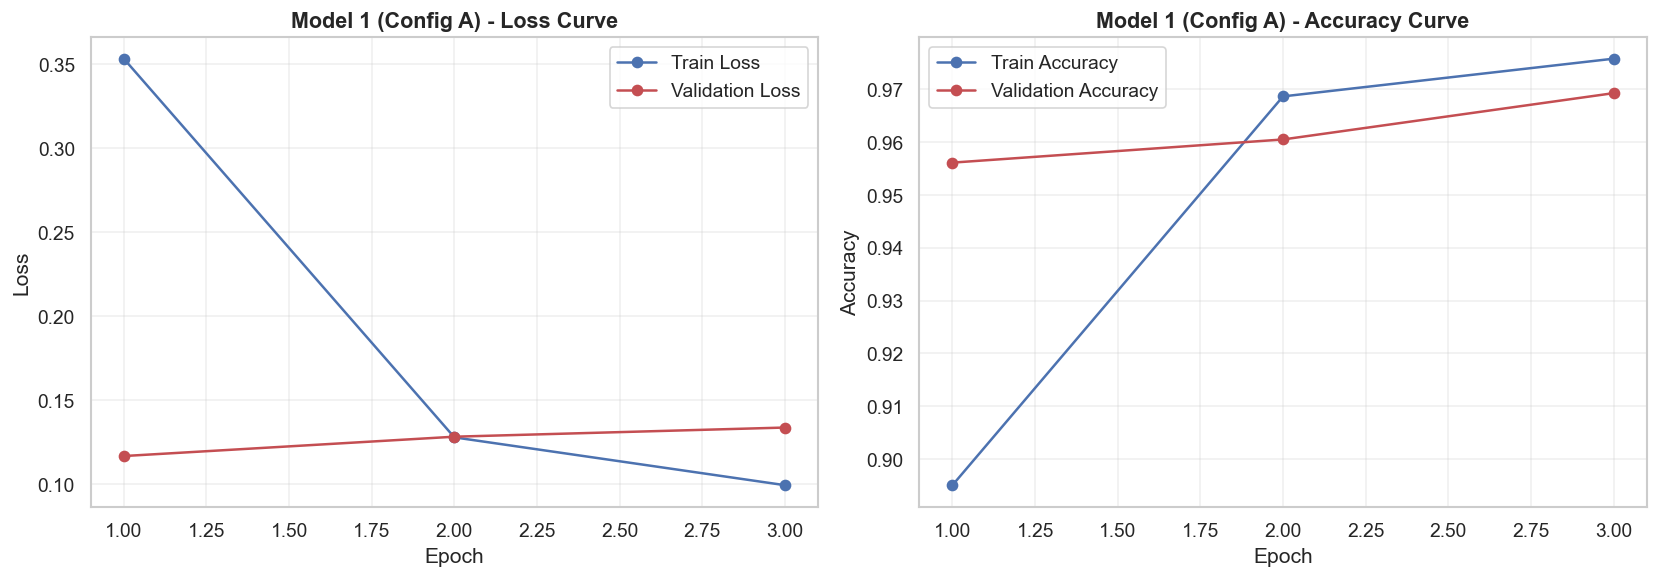

Learning curve Model 1 disimpan di: output\learning_curve_model1.png


In [ ]:
def plot_learning_curve(history, title='Model 1', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].plot(epochs, history['validation_loss'], 'r-o', label='Validation Loss')
    axes[0].set_title(f'{title} - Loss Curve', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_accuracy'], 'b-o', label='Train Accuracy')
    axes[1].plot(epochs, history['validation_accuracy'], 'r-o', label='Validation Accuracy')
    axes[1].set_title(f'{title} - Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path is None:
        save_path = os.path.join(OUTPUT_DIR, f'learning_curve_{title.replace(" ", "_")}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

LEARNING_CURVE_MODEL1_PATH = os.path.join(OUTPUT_DIR, 'learning_curve_model1.png')
plot_learning_curve(history_m1, f'Model 1 ({best_config_name_m1})', save_path=LEARNING_CURVE_MODEL1_PATH)
print(f'Learning curve Model 1 disimpan di: {LEARNING_CURVE_MODEL1_PATH}')


## Evaluasi Model 1
Fungsi `evaluate()` mengikuti pola dosen + menampilkan classification report dan confusion matrix untuk train, validation, dan test.

In [ ]:
def evaluate(model, data, label_col='label_model1', batch_size=8):
    dataset = NewsDataset(data, label_col=label_col)
    dataloader = DataLoader(dataset, batch_size=batch_size)

    use_cuda = torch.cuda.is_available()
    device = torch.device('cuda' if use_cuda else 'cpu')

    if use_cuda:
        model = model.cuda()

    model.eval()
    total_acc_test = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for test_input, test_label_batch in dataloader:
            test_label_batch = test_label_batch.to(device)
            mask = test_input['attention_mask'].to(device)
            input_id = test_input['input_ids'].squeeze(1).to(device)

            output = model(input_id, mask)

            predicted_labels = output.argmax(dim=1).cpu().numpy()
            true_labels = test_label_batch.cpu().numpy()

            all_predictions.extend(predicted_labels)
            all_true_labels.extend(true_labels)

            acc = (output.argmax(dim=1) == test_label_batch).sum().item()
            total_acc_test += acc

    test_accuracy = total_acc_test / len(data)
    print(f'Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

    return all_predictions, all_true_labels


def summarize_evaluation(model_name, dataset_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall': round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1': round(f1_score(y_true, y_pred, average='weighted'), 4)
    }



In [ ]:
def plot_confusion_matrix(y_true, y_pred, target_names, title='Confusion Matrix', save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    if save_path is None:
        save_path = os.path.join(OUTPUT_DIR, f'cm_{title.replace(" ", "_")}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


Evaluasi Model 1 - TRAIN SET
Accuracy: 0.9857 (98.57%)

Classification Report (Train):
                precision    recall  f1-score   support

  liga_inggris       0.98      0.97      0.98       301
   liga_italia       0.97      0.99      0.98       309
  liga_spanyol       0.99      0.98      0.99       309
liga_indonesia       0.98      0.97      0.97       293
non_sepak_bola       1.00      1.00      1.00       608

      accuracy                           0.99      1820
     macro avg       0.98      0.98      0.98      1820
  weighted avg       0.99      0.99      0.99      1820



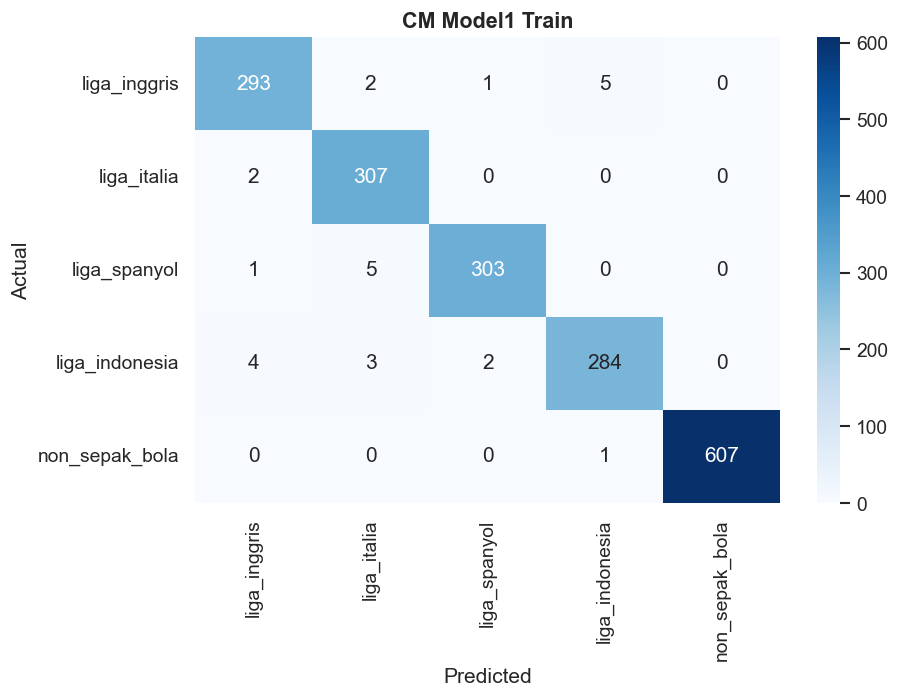

In [ ]:
model1_eval_results = []

target_names_m1 = list(labels_model1.keys())

print('=' * 60)
print('Evaluasi Model 1 - TRAIN SET')
print('=' * 60)
pred_train_m1, true_train_m1 = evaluate(model_m1, df_train_m1, label_col='label_model1')
print()
print('Classification Report (Train):')
print(classification_report(true_train_m1, pred_train_m1, target_names=target_names_m1))
plot_confusion_matrix(true_train_m1, pred_train_m1, target_names_m1, 'CM Model1 Train', save_path=os.path.join(OUTPUT_DIR, 'cm_model1_train.png'))

model1_eval_results.append(
    summarize_evaluation('Model 1', 'Train', true_train_m1, pred_train_m1)
)


Evaluasi Model 1 - VALIDATION SET
Accuracy: 0.9693 (96.93%)

Classification Report (Validation):
                precision    recall  f1-score   support

  liga_inggris       1.00      0.92      0.96        37
   liga_italia       0.93      0.97      0.95        39
  liga_spanyol       0.97      0.95      0.96        38
liga_indonesia       0.92      0.97      0.95        37
non_sepak_bola       1.00      1.00      1.00        77

      accuracy                           0.97       228
     macro avg       0.96      0.96      0.96       228
  weighted avg       0.97      0.97      0.97       228



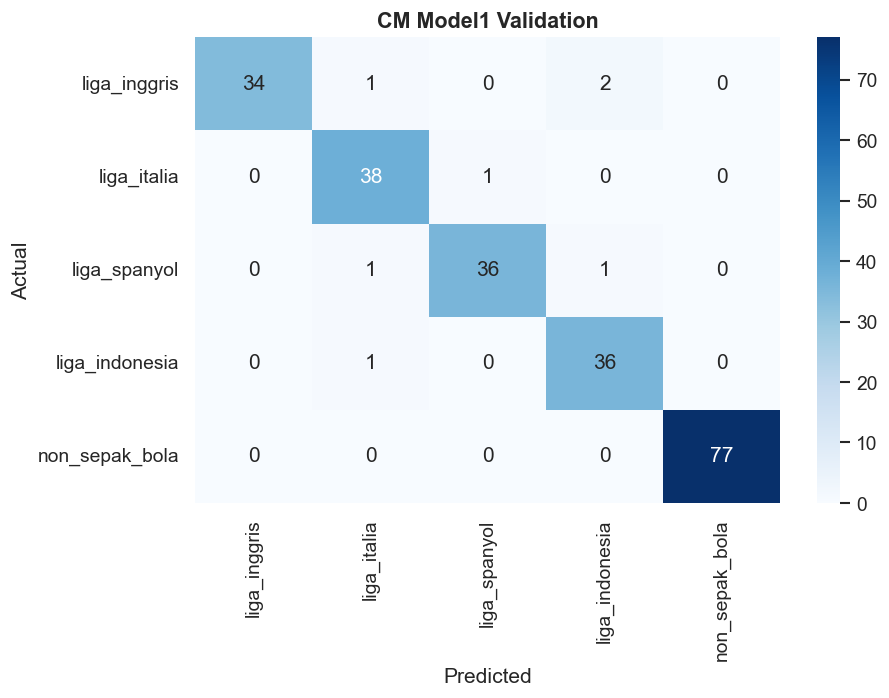

In [ ]:
print('=' * 60)
print('Evaluasi Model 1 - VALIDATION SET')
print('=' * 60)
pred_val_m1, true_val_m1 = evaluate(model_m1, df_val_m1, label_col='label_model1')
print()
print('Classification Report (Validation):')
print(classification_report(true_val_m1, pred_val_m1, target_names=target_names_m1))
plot_confusion_matrix(true_val_m1, pred_val_m1, target_names_m1, 'CM Model1 Validation', save_path=os.path.join(OUTPUT_DIR, 'cm_model1_validation.png'))

model1_eval_results.append(
    summarize_evaluation('Model 1', 'Validation', true_val_m1, pred_val_m1)
)


Evaluasi Model 1 - TEST SET
Accuracy: 0.9781 (97.81%)

Classification Report (Test):
                precision    recall  f1-score   support

  liga_inggris       0.95      1.00      0.97        38
   liga_italia       0.95      0.97      0.96        38
  liga_spanyol       0.97      0.95      0.96        39
liga_indonesia       1.00      0.97      0.99        37
non_sepak_bola       1.00      0.99      0.99        76

      accuracy                           0.98       228
     macro avg       0.97      0.98      0.98       228
  weighted avg       0.98      0.98      0.98       228



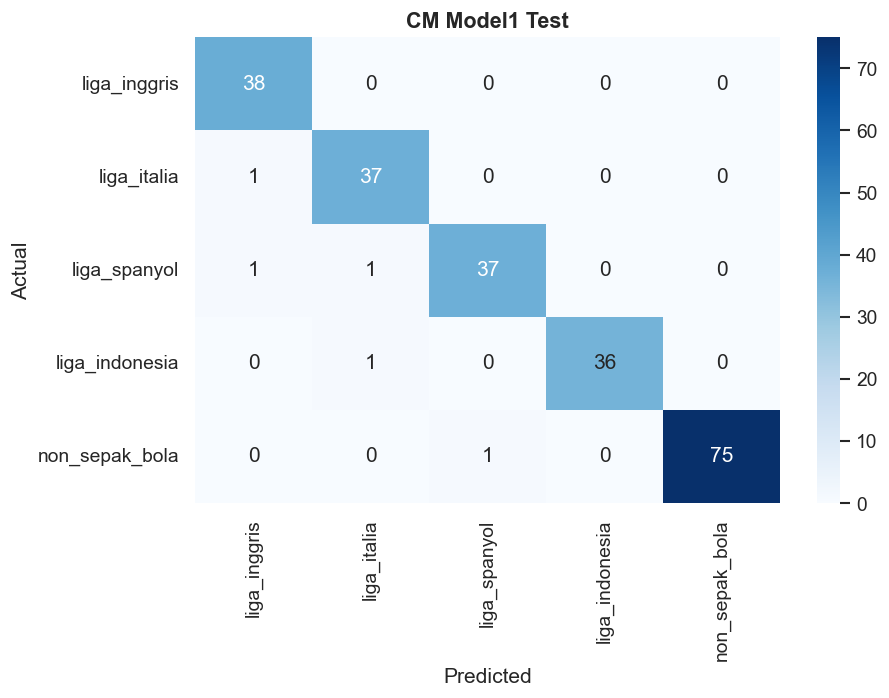

,Model,Dataset,Accuracy,Precision,Recall,F1
0,Model 1,Train,0.9857,0.9858,0.9857,0.9857
1,Model 1,Validation,0.9693,0.9705,0.9693,0.9694
2,Model 1,Test,0.9781,0.9786,0.9781,0.9781



[Ringkasan Test] Acc=0.9781 | Prec=0.9786 | Rec=0.9781 | F1=0.9781

Hasil evaluasi Model 1 berhasil disimpan:
- Evaluation metrics : output\evaluation_model1.csv
- Test report        : output\classification_report_model1_test.csv


In [ ]:
print('=' * 60)
print('Evaluasi Model 1 - TEST SET')
print('=' * 60)
pred_test_m1, true_test_m1 = evaluate(model_m1, df_test_m1, label_col='label_model1')
print()
print('Classification Report (Test):')
print(classification_report(true_test_m1, pred_test_m1, target_names=target_names_m1))
plot_confusion_matrix(true_test_m1, pred_test_m1, target_names_m1, 'CM Model1 Test', save_path=os.path.join(OUTPUT_DIR, 'cm_model1_test.png'))

model1_eval_results.append(
    summarize_evaluation('Model 1', 'Test', true_test_m1, pred_test_m1)
)

model1_eval_df = pd.DataFrame(model1_eval_results)
display(model1_eval_df)

model1_test_metrics = model1_eval_df[model1_eval_df['Dataset'] == 'Test'].iloc[0]
acc_m1 = model1_test_metrics['Accuracy']
prec_m1 = model1_test_metrics['Precision']
rec_m1 = model1_test_metrics['Recall']
f1_m1 = model1_test_metrics['F1']

print()
print(f'[Ringkasan Test] Acc={acc_m1:.4f} | Prec={prec_m1:.4f} | Rec={rec_m1:.4f} | F1={f1_m1:.4f}')


EVALUATION_MODEL1_PATH = os.path.join(OUTPUT_DIR, 'evaluation_model1.csv')
REPORT_MODEL1_TEST_PATH = os.path.join(OUTPUT_DIR, 'classification_report_model1_test.csv')

model1_eval_df.to_csv(EVALUATION_MODEL1_PATH, index=False, encoding='utf-8-sig')

classification_report_m1_test_df = pd.DataFrame(
    classification_report(
        true_test_m1,
        pred_test_m1,
        target_names=target_names_m1,
        output_dict=True
    )
).transpose()
classification_report_m1_test_df.to_csv(REPORT_MODEL1_TEST_PATH, encoding='utf-8-sig')

print()
print('Hasil evaluasi Model 1 berhasil disimpan:')
print(f'- Evaluation metrics : {EVALUATION_MODEL1_PATH}')
print(f'- Test report        : {REPORT_MODEL1_TEST_PATH}')


## Penjelasan Arsitektur Model 1

Model pertama dibangun menggunakan pendekatan **One-Stage Classification**, yaitu satu model secara langsung mengklasifikasikan berita ke dalam lima kategori, yaitu:

- Liga Inggris
- Liga Italia
- Liga Spanyol
- Liga Indonesia
- Non Sepak Bola

Model yang digunakan adalah **IndoBERT Base P1 (`indobenchmark/indobert-base-p1`)** yang telah melalui proses pre-training menggunakan korpus teks berbahasa Indonesia. Penggunaan pretrained model dipilih karena IndoBERT telah memiliki pemahaman konteks bahasa Indonesia sehingga proses fine-tuning dapat menghasilkan performa yang lebih baik dibandingkan membangun model dari awal.

Arsitektur classifier yang digunakan cukup sederhana, yaitu:

**IndoBERT → Dropout → Fully Connected (Linear Layer)**

Pada proses forward, token hasil tokenisasi terlebih dahulu diproses oleh IndoBERT. Representasi token `[CLS]` digunakan sebagai representasi keseluruhan kalimat, kemudian dilewatkan ke layer Dropout sebagai regularisasi sebelum masuk ke layer Linear yang menghasilkan lima buah output sesuai jumlah kelas.

Output layer menghasilkan **raw logits** dan tidak menggunakan fungsi aktivasi tambahan seperti Softmax ataupun ReLU karena proses optimisasi dilakukan menggunakan `CrossEntropyLoss`. Fungsi loss tersebut secara otomatis akan menghitung Softmax pada saat proses training sehingga penggunaan fungsi aktivasi tambahan justru dapat menurunkan performa model.

Hasil inisialisasi menunjukkan bahwa model memiliki sekitar **124.445.189 parameter**, dan seluruh parameter bersifat **trainable** sehingga seluruh bobot IndoBERT ikut diperbarui selama proses fine-tuning.

## Hyperparameter Tuning

Untuk memenuhi requirement tugas, dilakukan proses hyperparameter tuning menggunakan dua konfigurasi yang berbeda. Hyperparameter yang dibandingkan meliputi:

- Learning Rate
- Batch Size
- Jumlah Epoch
- Dropout

Konfigurasi yang digunakan adalah sebagai berikut.

| Konfigurasi | Learning Rate | Batch Size | Epoch | Dropout |
|-------------|--------------|-----------|-------|----------|
| Config A | 2e-5 | 8 | 3 | 0.3 |
| Config B | 3e-5 | 16 | 3 | 0.3 |

Pemilihan model terbaik dilakukan berdasarkan **Validation F1-score**, karena metrik ini mempertimbangkan keseimbangan antara Precision dan Recall sehingga lebih representatif dibandingkan hanya melihat Accuracy.

Berdasarkan hasil hyperparameter tuning diperoleh bahwa kedua konfigurasi menghasilkan performa terbaik yang hampir sama. Config A mencapai Validation Accuracy sebesar **96,93%** dan Validation F1-score sebesar **96,94%** pada **epoch ke-3**, sedangkan Config B mencapai nilai yang sama pada **epoch ke-2**.

Meskipun memiliki performa validasi yang setara, **Config A** dipilih sebagai model terbaik karena menunjukkan peningkatan performa yang lebih konsisten hingga epoch terakhir, sehingga digunakan pada proses evaluasi selanjutnya.

Meskipun kedua konfigurasi menghasilkan performa yang tinggi, **Config A** memberikan nilai Validation F1-score yang lebih tinggi sehingga dipilih sebagai model terbaik untuk proses evaluasi selanjutnya.

## Proses Training

Proses training dilakukan selama **3 epoch** menggunakan optimizer Adam dan fungsi loss `CrossEntropyLoss`.

Selama proses training dicatat beberapa metrik, yaitu:

- Train Loss
- Validation Loss
- Train Accuracy
- Validation Accuracy
- Validation F1-score

Learning curve menunjukkan bahwa **Train Loss** mengalami penurunan secara konsisten dari **0,353** pada epoch pertama menjadi **0,099** pada epoch ketiga. Sementara itu, **Validation Loss** berada pada kisaran **0,117–0,134**, hanya mengalami sedikit fluktuasi namun tetap stabil selama proses training.

Di sisi lain, **Train Accuracy** meningkat dari **89,5%** menjadi **97,6%**, sedangkan **Validation Accuracy** meningkat dari **95,6%** menjadi **96,9%**.

Perbedaan antara Train Accuracy dan Validation Accuracy pada epoch terakhir sekitar **0,7%**, yang menunjukkan bahwa model masih memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Selain itu, Validation Loss tidak mengalami kenaikan yang signifikan pada akhir training sehingga belum terlihat indikasi overfitting yang berarti. Oleh karena itu, penggunaan **3 epoch** sudah dianggap cukup untuk proses fine-tuning pada dataset ini.

## Analisis Learning Curve

Berdasarkan grafik learning curve dapat diamati beberapa hal.

1. Train Loss terus mengalami penurunan pada setiap epoch yang menunjukkan bahwa model semakin baik dalam mempelajari pola pada data training.

2. Validation Loss mengalami sedikit peningkatan dari **0,117** menjadi **0,134** selama proses training. Namun peningkatan tersebut relatif kecil dan tidak diikuti penurunan Validation Accuracy yang signifikan, sehingga belum menunjukkan indikasi overfitting yang serius.

3. Train Accuracy dan Validation Accuracy sama-sama mengalami peningkatan secara konsisten pada setiap epoch.

4. Jarak antara kurva training dan validation relatif kecil sehingga tidak terlihat gejala overfitting yang serius.

Secara keseluruhan, learning curve menunjukkan bahwa proses fine-tuning berjalan stabil dan model telah mencapai kondisi konvergen setelah tiga epoch.

## Analisis Confusion Matrix

Confusion matrix digunakan untuk melihat bagaimana model melakukan prediksi pada setiap kelas serta mengetahui pasangan kelas yang paling sering tertukar.

### Training Set

Pada data training sebagian besar prediksi berada pada diagonal utama yang menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data dengan benar.

Kesalahan prediksi yang masih muncul umumnya terjadi antar kelas liga, misalnya:

- Liga Inggris diprediksi sebagai Liga Italia.
- Liga Indonesia diprediksi sebagai Liga Italia.
- Liga Spanyol diprediksi sebagai Liga Inggris.

Sementara itu, kelas **Non Sepak Bola** berhasil diprediksi hampir sempurna tanpa banyak kesalahan.

---

### Validation Set

Pada data validation pola yang muncul hampir sama dengan data training.

Mayoritas prediksi berada pada diagonal utama dengan tingkat akurasi sebesar **96,93%**. Sebagian besar kesalahan klasifikasi masih terjadi antar kelas liga yang memiliki konteks berita serupa, sedangkan kelas **Non Sepak Bola** berhasil dikenali dengan sangat baik tanpa kesalahan klasifikasi.

Kesalahan klasifikasi masih didominasi oleh pertukaran antar liga yang memang memiliki konteks berita yang mirip, sedangkan kelas Non Sepak Bola tetap dapat dibedakan dengan sangat baik.

---

### Test Set

Pada data testing model memperoleh **Accuracy sebesar 97,81%**.

Kesalahan prediksi yang muncul relatif sedikit dan sebagian besar masih terjadi antar liga, yaitu:

- 1 berita Liga Italia diprediksi sebagai Liga Inggris.
- 1 berita Liga Spanyol diprediksi sebagai Liga Inggris.
- 1 berita Liga Spanyol diprediksi sebagai Liga Italia.
- 1 berita Liga Indonesia diprediksi sebagai Liga Italia.
- 1 berita Non Sepak Bola diprediksi sebagai Liga Spanyol.

Sebaliknya, sebagian besar artikel pada setiap kelas berhasil diklasifikasikan dengan benar, terutama kelas Non Sepak Bola yang memperoleh 75 prediksi benar dari 76 data uji.

Hal ini menunjukkan bahwa model tidak mengalami kesulitan membedakan berita sepak bola dengan non sepak bola, sedangkan tantangan utama terletak pada membedakan liga-liga yang memiliki kosakata dan konteks yang hampir serupa.

## Analisis Hasil Evaluasi

Hasil evaluasi menunjukkan bahwa model memberikan performa yang konsisten pada ketiga subset data.

| Dataset    |   Accuracy |  Precision |     Recall |   F1-score |
| ---------- | ---------: | ---------: | ---------: | ---------: |
| Training   | **98.57%** | **98.58%** | **98.57%** | **98.57%** |
| Validation | **96.93%** | **97.05%** | **96.93%** | **96.94%** |
| Testing    | **97.81%** | **97.86%** | **97.81%** | **97.81%** |

Nilai Accuracy pada data training sebesar **98,57%**, sedangkan pada validation dan testing masing-masing sebesar **96,93%** dan **97,81%**. Selisih performa antar dataset relatif kecil sehingga menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting yang signifikan.

Selain itu, nilai Precision, Recall, dan F1-score juga relatif seimbang pada ketiga subset data. Hal ini menunjukkan bahwa model tidak hanya menghasilkan prediksi yang akurat, tetapi juga mampu mengenali setiap kelas secara konsisten dengan tingkat kesalahan yang rendah.

Secara keseluruhan, hasil evaluasi menunjukkan bahwa pendekatan One-Stage menggunakan IndoBERT berhasil mempelajari karakteristik masing-masing kategori berita olahraga dengan performa yang tinggi serta tetap stabil ketika diuji menggunakan data yang belum pernah dilihat sebelumnya.

## Model 2 – Two-Stage BertClassifier
**Stage 1:** Klasifikasi biner → sepak_bola vs non_sepak_bola  
**Stage 2:** Untuk data sepak_bola → klasifikasi 4 liga (inggris, italia, spanyol, indonesia)

In [ ]:
class BertClassifierBinary(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super(BertClassifierBinary, self).__init__()
        self.bert    = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(768, num_classes)

    def forward(self, input_id, mask):
        _, pooled_output = self.bert(input_ids=input_id, attention_mask=mask, return_dict=False)
        dropout_output = self.dropout(pooled_output)
        logits = self.linear(dropout_output)
        return logits

class BertClassifierLeague(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super(BertClassifierLeague, self).__init__()
        self.bert    = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(768, num_classes)

    def forward(self, input_id, mask):
        _, pooled_output = self.bert(input_ids=input_id, attention_mask=mask, return_dict=False)
        dropout_output = self.dropout(pooled_output)
        logits = self.linear(dropout_output)
        return logits

print('Model Stage 1 (2 kelas) dan Stage 2 (4 kelas) siap.')
params_s1 = sum(p.numel() for p in BertClassifierBinary().parameters())
params_s2 = sum(p.numel() for p in BertClassifierLeague().parameters())
print(f'Parameter Stage 1: {params_s1:,}')
print(f'Parameter Stage 2: {params_s2:,}')

Model Stage 1 (2 kelas) dan Stage 2 (4 kelas) siap.
Parameter Stage 1: 124,442,882
Parameter Stage 2: 124,444,420


## Hyperparameter Tuning Model 2
Minimal dua kombinasi untuk masing-masing stage.

In [ ]:
hp_configs_stage1 = [
    {'name': 'Config A', 'lr': 2e-5, 'epochs': 3, 'batch_size': 8,  'dropout': 0.3},
    {'name': 'Config B', 'lr': 3e-5, 'epochs': 3, 'batch_size': 16, 'dropout': 0.3},
]

hp_configs_stage2 = [
    {'name': 'Config A', 'lr': 2e-5, 'epochs': 3, 'batch_size': 8,  'dropout': 0.3},
    {'name': 'Config B', 'lr': 3e-5, 'epochs': 3, 'batch_size': 16, 'dropout': 0.3},
]

print('Konfigurasi Hyperparameter Stage 1:')
display(pd.DataFrame(hp_configs_stage1))
print('Konfigurasi Hyperparameter Stage 2:')
display(pd.DataFrame(hp_configs_stage2))


Konfigurasi Hyperparameter Stage 1:


,name,lr,epochs,batch_size,dropout
0,Config A,0.00002,3,8,0.3
1,Config B,0.00003,3,16,0.3


Konfigurasi Hyperparameter Stage 2:


,name,lr,epochs,batch_size,dropout
0,Config A,0.00002,3,8,0.3
1,Config B,0.00003,3,16,0.3


Training Model 2 Stage 1 - Config A
LR=2e-05 | Epochs=3 | Batch=8 | Dropout=0.3


Epoch 1/3 [Val]  : 100%|██████████| 29/29 [00:01<00:00, 16.94it/s]


Epochs: 1 | Train Loss: 0.087 | Train Accuracy: 0.966 | Val Loss: 0.030 | Val Accuracy: 0.991 | Val F1: 0.991


Epoch 2/3 [Val]  : 100%|██████████| 29/29 [00:01<00:00, 16.82it/s]


Epochs: 2 | Train Loss: 0.012 | Train Accuracy: 0.998 | Val Loss: 0.005 | Val Accuracy: 0.996 | Val F1: 0.996


...

Epoch 3/3 [Val]  : 100%|██████████| 15/15 [00:01<00:00,  8.00it/s]

Epochs: 3 | Train Loss: 0.007 | Train Accuracy: 0.998 | Val Loss: 0.002 | Val Accuracy: 1.000 | Val F1: 1.000


,Config,Learning Rate,Epoch,Batch Size,Dropout,Best Validation Accuracy,Best Validation F1,Best Epoch,Training Time
0,Config A,0.00002,3,8,0.3,1.0,1.0,3,151.52
1,Config B,0.00003,3,16,0.3,1.0,1.0,2,142.59


MODEL 2 STAGE 1 TERBAIK


,Stage,Best Config,Learning Rate,Batch Size,Epoch,Dropout,Best Validation Accuracy,Best Validation F1,Best Epoch,Training Time
0,Stage 1,Config A,0.00002,8,3,0.3,1.0,1.0,3,151.52


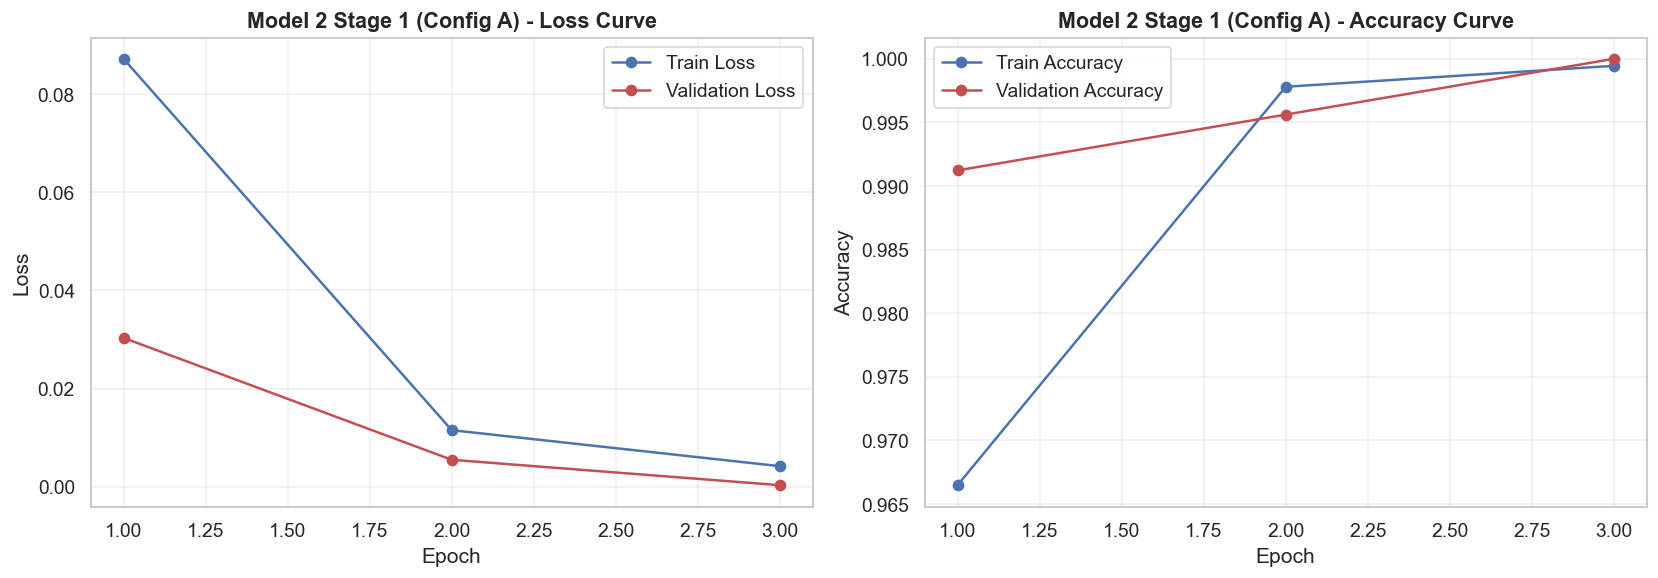


Artefak Stage 1 berhasil disimpan:
- tuning     : output\tuning_stage1.csv
- history    : output\history_stage1.csv
- summary    : output\best_stage1_summary.csv
- checkpoint : output\best_stage1.pt
- curve      : output\learning_curve_stage1.png


In [ ]:
tuning_results_stage1 = []
histories_stage1 = {}
models_stage1 = {}

for config in hp_configs_stage1:
    print('=' * 60)
    print(f"Training Model 2 Stage 1 - {config['name']}")
    print(
        f"LR={config['lr']} | "
        f"Epochs={config['epochs']} | "
        f"Batch={config['batch_size']} | "
        f"Dropout={config['dropout']}"
    )
    print('=' * 60)

    model = BertClassifierBinary(num_classes=2, dropout=config['dropout'])
    start_time = time.time()

    history = train(
        model,
        df_s1_train,
        df_s1_val,
        learning_rate=config['lr'],
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        label_col='label_stage1'
    )

    training_time = time.time() - start_time
    best_validation_accuracy = max(history['validation_accuracy'])
    best_validation_f1 = max(history['validation_f1'])
    best_epoch = history['validation_f1'].index(best_validation_f1) + 1

    tuning_results_stage1.append({
        'Config': config['name'],
        'Learning Rate': config['lr'],
        'Epoch': config['epochs'],
        'Batch Size': config['batch_size'],
        'Dropout': config['dropout'],
        'Best Validation Accuracy': round(best_validation_accuracy, 4),
        'Best Validation F1': round(best_validation_f1, 4),
        'Best Epoch': best_epoch,
        'Training Time': round(training_time, 2)
    })

    histories_stage1[config['name']] = history
    models_stage1[config['name']] = model

tuning_results_stage1 = pd.DataFrame(tuning_results_stage1)
display(tuning_results_stage1)

best_stage1_info = tuning_results_stage1.sort_values(
    by=['Best Validation F1', 'Best Validation Accuracy'],
    ascending=False
).iloc[0].to_dict()

best_config_stage1 = best_stage1_info['Config']
model_s1 = models_stage1[best_config_stage1]
history_stage1 = histories_stage1[best_config_stage1]
history_s1 = history_stage1
time_s1 = best_stage1_info['Training Time']

best_stage1_summary = pd.DataFrame([{
    'Stage': 'Stage 1',
    'Best Config': best_stage1_info['Config'],
    'Learning Rate': best_stage1_info['Learning Rate'],
    'Batch Size': best_stage1_info['Batch Size'],
    'Epoch': best_stage1_info['Epoch'],
    'Dropout': best_stage1_info['Dropout'],
    'Best Validation Accuracy': best_stage1_info['Best Validation Accuracy'],
    'Best Validation F1': best_stage1_info['Best Validation F1'],
    'Best Epoch': best_stage1_info['Best Epoch'],
    'Training Time': best_stage1_info['Training Time']
}])

print('=' * 60)
print('MODEL 2 STAGE 1 TERBAIK')
print('=' * 60)
display(best_stage1_summary)

TUNING_STAGE1_PATH = os.path.join(OUTPUT_DIR, 'tuning_stage1.csv')
HISTORY_STAGE1_PATH = os.path.join(OUTPUT_DIR, 'history_stage1.csv')
BEST_STAGE1_SUMMARY_PATH = os.path.join(OUTPUT_DIR, 'best_stage1_summary.csv')
BEST_STAGE1_PATH = os.path.join(OUTPUT_DIR, 'best_stage1.pt')

history_stage1_df = pd.DataFrame(history_stage1)
history_stage1_df.insert(0, 'epoch', range(1, len(history_stage1_df) + 1))

tuning_results_stage1.to_csv(TUNING_STAGE1_PATH, index=False, encoding='utf-8-sig')
history_stage1_df.to_csv(HISTORY_STAGE1_PATH, index=False, encoding='utf-8-sig')
best_stage1_summary.to_csv(BEST_STAGE1_SUMMARY_PATH, index=False, encoding='utf-8-sig')
torch.save(model_s1.state_dict(), BEST_STAGE1_PATH)

LEARNING_CURVE_STAGE1_PATH = os.path.join(OUTPUT_DIR, 'learning_curve_stage1.png')
plot_learning_curve(history_stage1, f'Model 2 Stage 1 ({best_config_stage1})', save_path=LEARNING_CURVE_STAGE1_PATH)
print()
print('Artefak Stage 1 berhasil disimpan:')
print(f'- tuning     : {TUNING_STAGE1_PATH}')
print(f'- history    : {HISTORY_STAGE1_PATH}')
print(f'- summary    : {BEST_STAGE1_SUMMARY_PATH}')
print(f'- checkpoint : {BEST_STAGE1_PATH}')
print(f'- curve      : {LEARNING_CURVE_STAGE1_PATH}')


Training Model 2 Stage 2 - Config A
LR=2e-05 | Epochs=3 | Batch=8 | Dropout=0.3


Epoch 1/3 [Val]  : 100%|██████████| 19/19 [00:01<00:00, 15.16it/s]


Epochs: 1 | Train Loss: 0.420 | Train Accuracy: 0.863 | Val Loss: 0.175 | Val Accuracy: 0.960 | Val F1: 0.960


Epoch 2/3 [Val]  : 100%|██████████| 19/19 [00:01<00:00, 15.06it/s]


Epochs: 2 | Train Loss: 0.176 | Train Accuracy: 0.954 | Val Loss: 0.163 | Val Accuracy: 0.960 | Val F1: 0.960


...

Epoch 3/3 [Val]  : 100%|██████████| 10/10 [00:22<00:00,  2.23s/it]

Epochs: 3 | Train Loss: 0.134 | Train Accuracy: 0.965 | Val Loss: 0.165 | Val Accuracy: 0.960 | Val F1: 0.960


,Config,Learning Rate,Epoch,Batch Size,Dropout,Best Validation Accuracy,Best Validation F1,Best Epoch,Training Time
0,Config A,0.00002,3,8,0.3,0.9603,0.9603,1,142.11
1,Config B,0.00003,3,16,0.3,0.9603,0.9602,3,1693.27


MODEL 2 STAGE 2 TERBAIK


,Stage,Best Config,Learning Rate,Batch Size,Epoch,Dropout,Best Validation Accuracy,Best Validation F1,Best Epoch,Training Time
0,Stage 2,Config A,0.00002,8,3,0.3,0.9603,0.9603,1,142.11


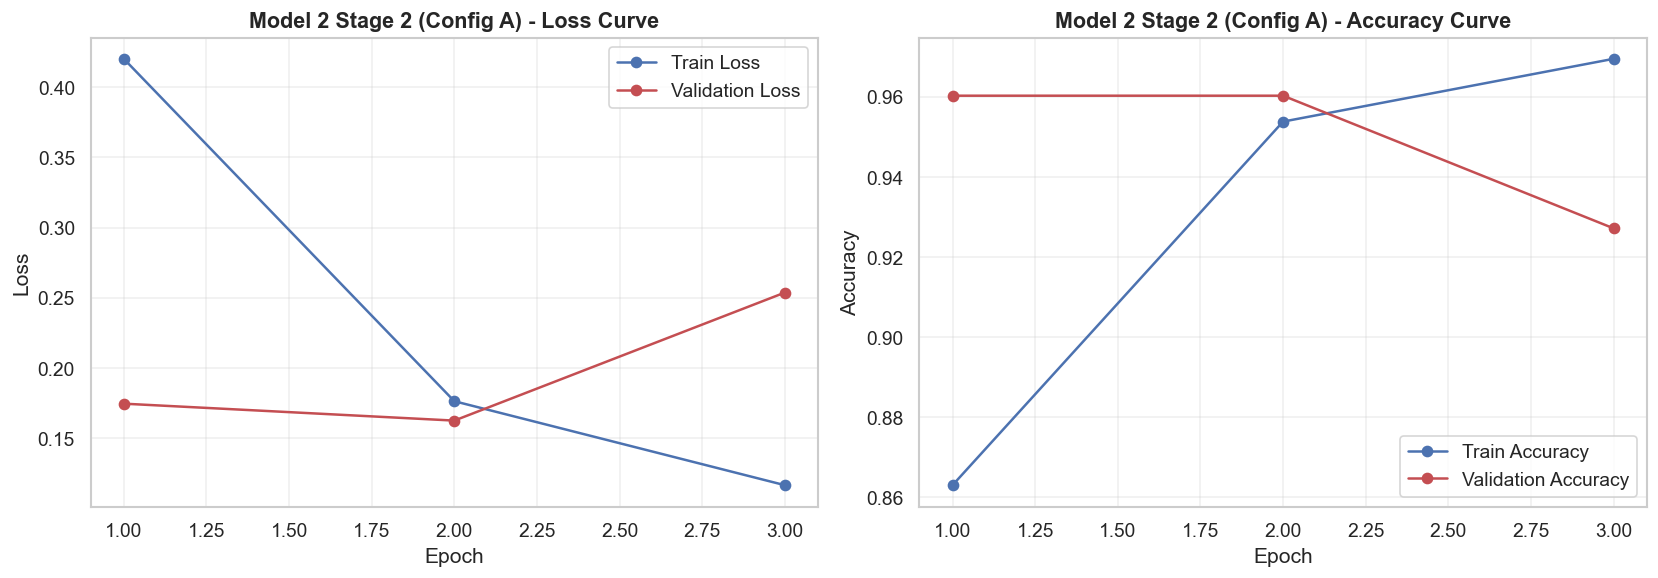


Artefak Stage 2 berhasil disimpan:
- tuning     : output\tuning_stage2.csv
- history    : output\history_stage2.csv
- summary    : output\best_stage2_summary.csv
- checkpoint : output\best_stage2.pt
- curve      : output\learning_curve_stage2.png


In [ ]:
tuning_results_stage2 = []
histories_stage2 = {}
models_stage2 = {}

for config in hp_configs_stage2:
    print('=' * 60)
    print(f"Training Model 2 Stage 2 - {config['name']}")
    print(
        f"LR={config['lr']} | "
        f"Epochs={config['epochs']} | "
        f"Batch={config['batch_size']} | "
        f"Dropout={config['dropout']}"
    )
    print('=' * 60)

    model = BertClassifierLeague(num_classes=4, dropout=config['dropout'])
    start_time = time.time()

    history = train(
        model,
        df_s2_train,
        df_s2_val,
        learning_rate=config['lr'],
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        label_col='label_stage2'
    )

    training_time = time.time() - start_time
    best_validation_accuracy = max(history['validation_accuracy'])
    best_validation_f1 = max(history['validation_f1'])
    best_epoch = history['validation_f1'].index(best_validation_f1) + 1

    tuning_results_stage2.append({
        'Config': config['name'],
        'Learning Rate': config['lr'],
        'Epoch': config['epochs'],
        'Batch Size': config['batch_size'],
        'Dropout': config['dropout'],
        'Best Validation Accuracy': round(best_validation_accuracy, 4),
        'Best Validation F1': round(best_validation_f1, 4),
        'Best Epoch': best_epoch,
        'Training Time': round(training_time, 2)
    })

    histories_stage2[config['name']] = history
    models_stage2[config['name']] = model

tuning_results_stage2 = pd.DataFrame(tuning_results_stage2)
display(tuning_results_stage2)

best_stage2_info = tuning_results_stage2.sort_values(
    by=['Best Validation F1', 'Best Validation Accuracy'],
    ascending=False
).iloc[0].to_dict()

best_config_stage2 = best_stage2_info['Config']
model_s2 = models_stage2[best_config_stage2]
history_stage2 = histories_stage2[best_config_stage2]
history_s2 = history_stage2
time_s2 = best_stage2_info['Training Time']

best_stage2_summary = pd.DataFrame([{
    'Stage': 'Stage 2',
    'Best Config': best_stage2_info['Config'],
    'Learning Rate': best_stage2_info['Learning Rate'],
    'Batch Size': best_stage2_info['Batch Size'],
    'Epoch': best_stage2_info['Epoch'],
    'Dropout': best_stage2_info['Dropout'],
    'Best Validation Accuracy': best_stage2_info['Best Validation Accuracy'],
    'Best Validation F1': best_stage2_info['Best Validation F1'],
    'Best Epoch': best_stage2_info['Best Epoch'],
    'Training Time': best_stage2_info['Training Time']
}])

print('=' * 60)
print('MODEL 2 STAGE 2 TERBAIK')
print('=' * 60)
display(best_stage2_summary)

TUNING_STAGE2_PATH = os.path.join(OUTPUT_DIR, 'tuning_stage2.csv')
HISTORY_STAGE2_PATH = os.path.join(OUTPUT_DIR, 'history_stage2.csv')
BEST_STAGE2_SUMMARY_PATH = os.path.join(OUTPUT_DIR, 'best_stage2_summary.csv')
BEST_STAGE2_PATH = os.path.join(OUTPUT_DIR, 'best_stage2.pt')

history_stage2_df = pd.DataFrame(history_stage2)
history_stage2_df.insert(0, 'epoch', range(1, len(history_stage2_df) + 1))

tuning_results_stage2.to_csv(TUNING_STAGE2_PATH, index=False, encoding='utf-8-sig')
history_stage2_df.to_csv(HISTORY_STAGE2_PATH, index=False, encoding='utf-8-sig')
best_stage2_summary.to_csv(BEST_STAGE2_SUMMARY_PATH, index=False, encoding='utf-8-sig')
torch.save(model_s2.state_dict(), BEST_STAGE2_PATH)

LEARNING_CURVE_STAGE2_PATH = os.path.join(OUTPUT_DIR, 'learning_curve_stage2.png')
plot_learning_curve(history_stage2, f'Model 2 Stage 2 ({best_config_stage2})', save_path=LEARNING_CURVE_STAGE2_PATH)
print()
print('Artefak Stage 2 berhasil disimpan:')
print(f'- tuning     : {TUNING_STAGE2_PATH}')
print(f'- history    : {HISTORY_STAGE2_PATH}')
print(f'- summary    : {BEST_STAGE2_SUMMARY_PATH}')
print(f'- checkpoint : {BEST_STAGE2_PATH}')
print(f'- curve      : {LEARNING_CURVE_STAGE2_PATH}')


## Evaluasi Model 2 (Two-Stage)
Evaluasi masing-masing stage secara terpisah, lalu kombinasikan hasil prediksi untuk evaluasi end-to-end.

Evaluasi Stage 1 - TRAIN
Accuracy: 0.9995 (99.95%)
                precision    recall  f1-score   support

    sepak_bola       1.00      1.00      1.00      1211
non_sepak_bola       1.00      1.00      1.00       609

      accuracy                           1.00      1820
     macro avg       1.00      1.00      1.00      1820
  weighted avg       1.00      1.00      1.00      1820



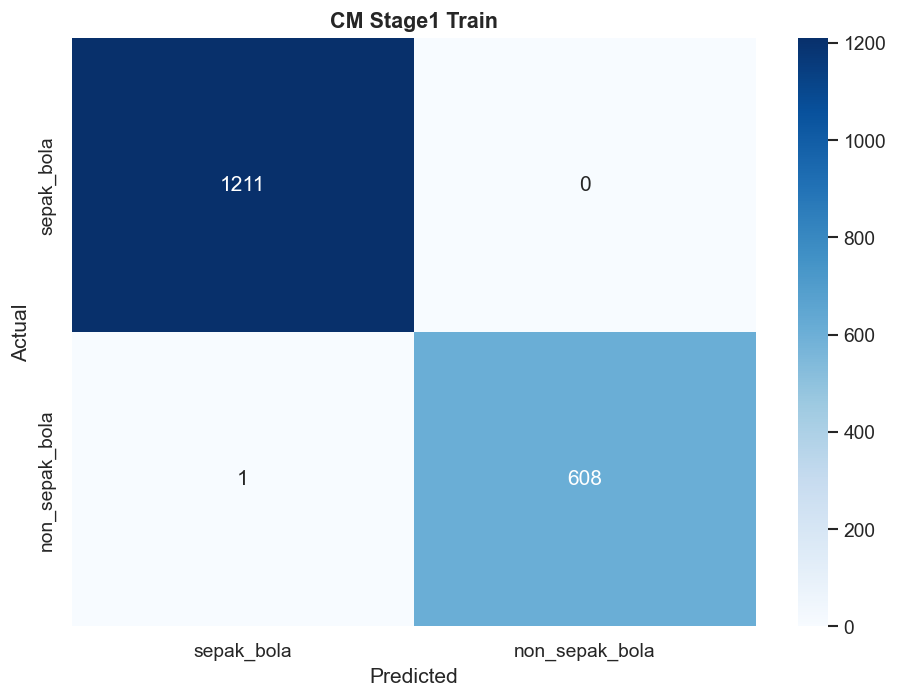

In [ ]:
model2_stage1_eval_results = []
target_s1 = ['sepak_bola', 'non_sepak_bola']

print('=' * 60)
print('Evaluasi Stage 1 - TRAIN')
print('=' * 60)
pred_s1_train, true_s1_train = evaluate(model_s1, df_s1_train, label_col='label_stage1')
print(classification_report(true_s1_train, pred_s1_train, target_names=target_s1))
plot_confusion_matrix(
    true_s1_train,
    pred_s1_train,
    target_s1,
    'CM Stage1 Train',
    save_path=os.path.join(OUTPUT_DIR, 'cm_stage1_train.png')
)

stage1_train_summary = summarize_evaluation('Model 2', 'Train', true_s1_train, pred_s1_train)
stage1_train_summary['Stage'] = 'Stage 1'
model2_stage1_eval_results.append(stage1_train_summary)


Evaluasi Stage 1 - VALIDATION
Accuracy: 1.0000 (100.00%)
                precision    recall  f1-score   support

    sepak_bola       1.00      1.00      1.00       152
non_sepak_bola       1.00      1.00      1.00        76

      accuracy                           1.00       228
     macro avg       1.00      1.00      1.00       228
  weighted avg       1.00      1.00      1.00       228



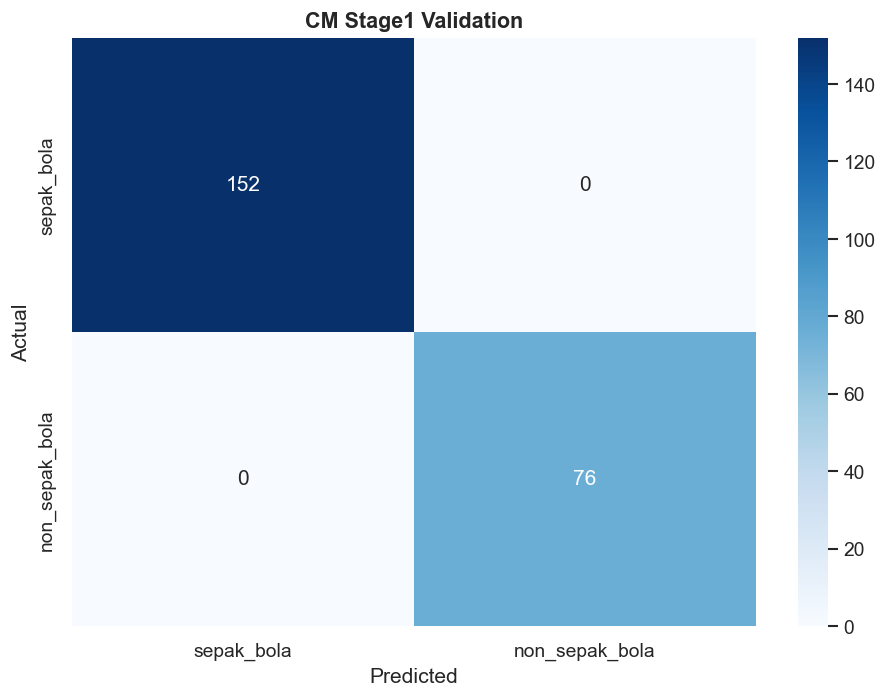

In [ ]:
print('=' * 60)
print('Evaluasi Stage 1 - VALIDATION')
print('=' * 60)
pred_s1_val, true_s1_val = evaluate(model_s1, df_s1_val, label_col='label_stage1')
print(classification_report(true_s1_val, pred_s1_val, target_names=target_s1))
plot_confusion_matrix(
    true_s1_val,
    pred_s1_val,
    target_s1,
    'CM Stage1 Validation',
    save_path=os.path.join(OUTPUT_DIR, 'cm_stage1_validation.png')
)

stage1_val_summary = summarize_evaluation('Model 2', 'Validation', true_s1_val, pred_s1_val)
stage1_val_summary['Stage'] = 'Stage 1'
model2_stage1_eval_results.append(stage1_val_summary)


Evaluasi Stage 1 - TEST
Accuracy: 0.9956 (99.56%)
                precision    recall  f1-score   support

    sepak_bola       0.99      1.00      1.00       152
non_sepak_bola       1.00      0.99      0.99        76

      accuracy                           1.00       228
     macro avg       1.00      0.99      1.00       228
  weighted avg       1.00      1.00      1.00       228



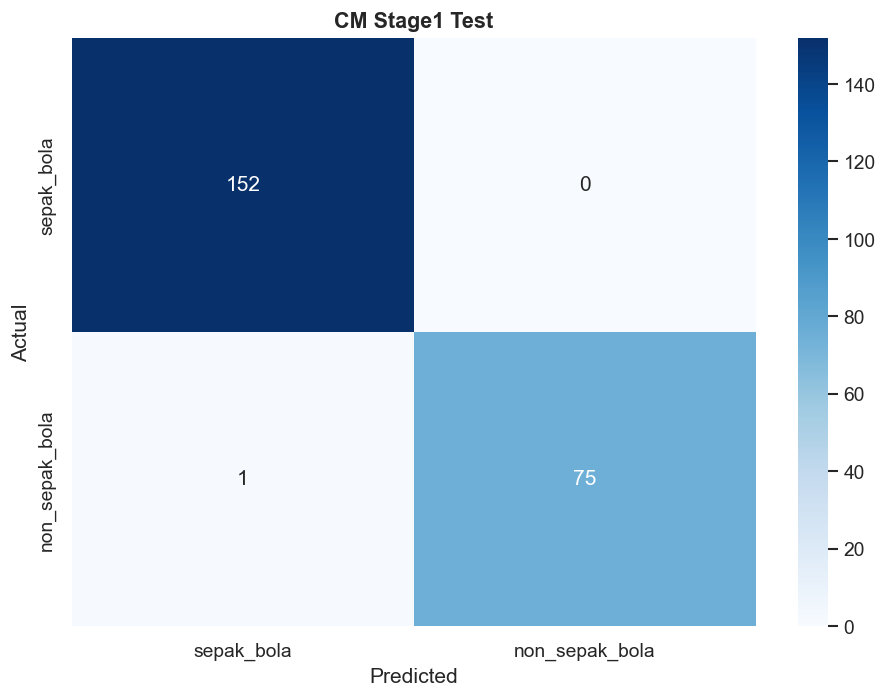

,Model,Stage,Dataset,Accuracy,Precision,Recall,F1
0,Model 2,Stage 1,Train,0.9995,0.9995,0.9995,0.9995
1,Model 2,Stage 1,Validation,1.0000,1.0000,1.0000,1.0000
2,Model 2,Stage 1,Test,0.9956,0.9956,0.9956,0.9956


Hasil evaluasi Stage 1 berhasil disimpan.
- Evaluation metrics : output\evaluation_stage1.csv
- Test report        : output\classification_report_stage1_test.csv


In [ ]:
print('=' * 60)
print('Evaluasi Stage 1 - TEST')
print('=' * 60)
pred_s1_test, true_s1_test = evaluate(model_s1, df_s1_test, label_col='label_stage1')
print(classification_report(true_s1_test, pred_s1_test, target_names=target_s1))
plot_confusion_matrix(
    true_s1_test,
    pred_s1_test,
    target_s1,
    'CM Stage1 Test',
    save_path=os.path.join(OUTPUT_DIR, 'cm_stage1_test.png')
)

stage1_test_summary = summarize_evaluation('Model 2', 'Test', true_s1_test, pred_s1_test)
stage1_test_summary['Stage'] = 'Stage 1'
model2_stage1_eval_results.append(stage1_test_summary)

model2_stage1_eval_df = pd.DataFrame(model2_stage1_eval_results)
model2_stage1_eval_df = model2_stage1_eval_df[['Model', 'Stage', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1']]
display(model2_stage1_eval_df)

EVALUATION_STAGE1_PATH = os.path.join(OUTPUT_DIR, 'evaluation_stage1.csv')
REPORT_STAGE1_TEST_PATH = os.path.join(OUTPUT_DIR, 'classification_report_stage1_test.csv')

model2_stage1_eval_df.to_csv(EVALUATION_STAGE1_PATH, index=False, encoding='utf-8-sig')
classification_report_stage1_test_df = pd.DataFrame(
    classification_report(
        true_s1_test,
        pred_s1_test,
        target_names=target_s1,
        output_dict=True
    )
).transpose()
classification_report_stage1_test_df.to_csv(REPORT_STAGE1_TEST_PATH, encoding='utf-8-sig')

print('Hasil evaluasi Stage 1 berhasil disimpan.')
print(f'- Evaluation metrics : {EVALUATION_STAGE1_PATH}')
print(f'- Test report        : {REPORT_STAGE1_TEST_PATH}')


Evaluasi Stage 2 - TRAIN
Accuracy: 0.9695 (96.95%)
                precision    recall  f1-score   support

  liga_inggris       0.91      1.00      0.95       301
   liga_italia       0.99      0.98      0.98       309
  liga_spanyol       0.99      0.99      0.99       309
liga_indonesia       1.00      0.91      0.95       293

      accuracy                           0.97      1212
     macro avg       0.97      0.97      0.97      1212
  weighted avg       0.97      0.97      0.97      1212



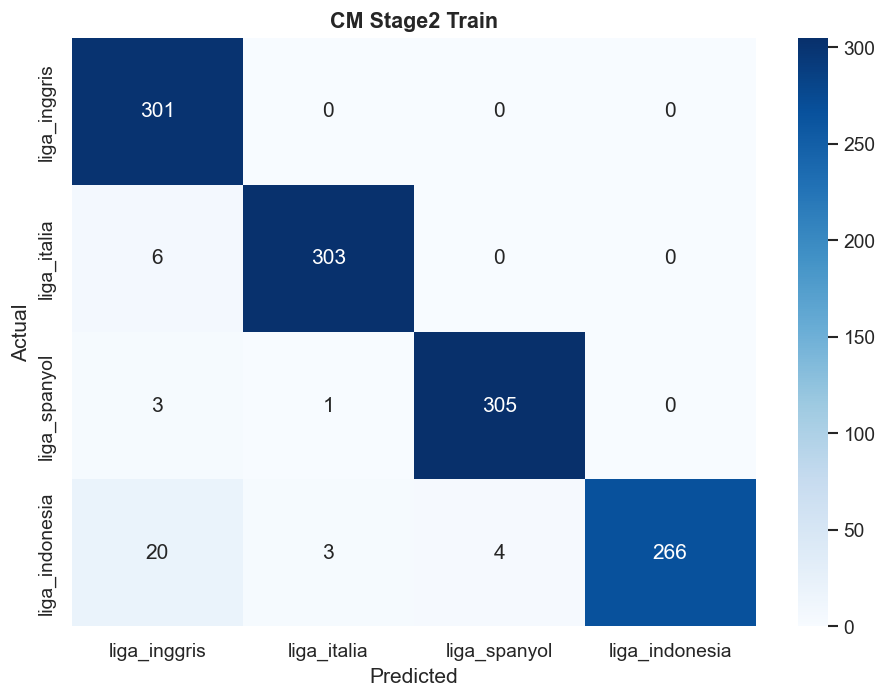

In [ ]:
model2_stage2_eval_results = []
target_s2 = list(labels_stage2.keys())

print('=' * 60)
print('Evaluasi Stage 2 - TRAIN')
print('=' * 60)
pred_s2_train, true_s2_train = evaluate(model_s2, df_s2_train, label_col='label_stage2')
print(classification_report(true_s2_train, pred_s2_train, target_names=target_s2))
plot_confusion_matrix(
    true_s2_train,
    pred_s2_train,
    target_s2,
    'CM Stage2 Train',
    save_path=os.path.join(OUTPUT_DIR, 'cm_stage2_train.png')
)

stage2_train_summary = summarize_evaluation('Model 2', 'Train', true_s2_train, pred_s2_train)
stage2_train_summary['Stage'] = 'Stage 2'
model2_stage2_eval_results.append(stage2_train_summary)


Evaluasi Stage 2 - VALIDATION
Accuracy: 0.9272 (92.72%)
                precision    recall  f1-score   support

  liga_inggris       0.82      0.97      0.89        38
   liga_italia       0.93      1.00      0.96        38
  liga_spanyol       1.00      0.89      0.94        38
liga_indonesia       1.00      0.84      0.91        37

      accuracy                           0.93       151
     macro avg       0.94      0.93      0.93       151
  weighted avg       0.94      0.93      0.93       151



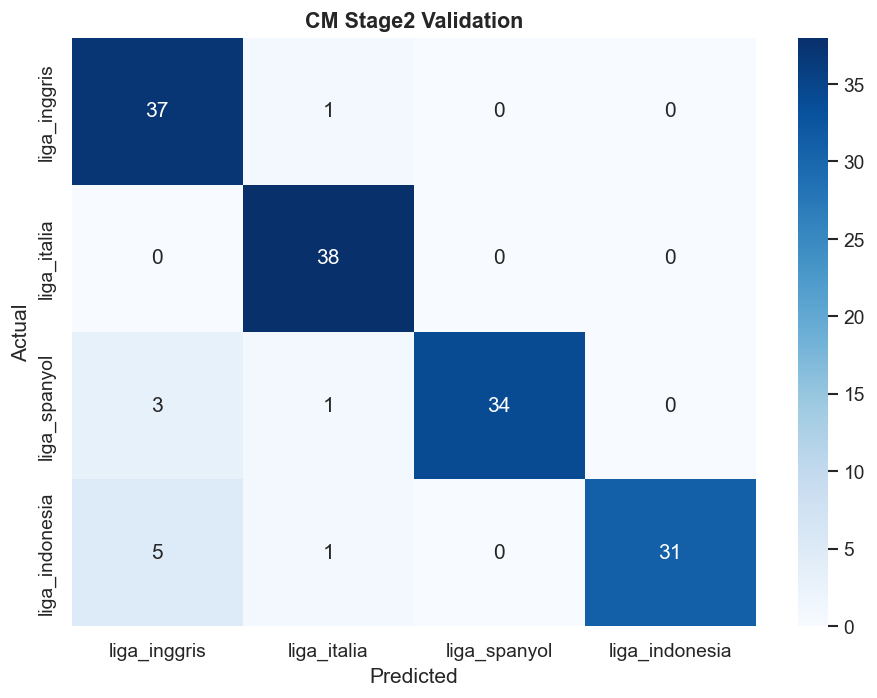

In [ ]:
print('=' * 60)
print('Evaluasi Stage 2 - VALIDATION')
print('=' * 60)
pred_s2_val, true_s2_val = evaluate(model_s2, df_s2_val, label_col='label_stage2')
print(classification_report(true_s2_val, pred_s2_val, target_names=target_s2))
plot_confusion_matrix(
    true_s2_val,
    pred_s2_val,
    target_s2,
    'CM Stage2 Validation',
    save_path=os.path.join(OUTPUT_DIR, 'cm_stage2_validation.png')
)

stage2_val_summary = summarize_evaluation('Model 2', 'Validation', true_s2_val, pred_s2_val)
stage2_val_summary['Stage'] = 'Stage 2'
model2_stage2_eval_results.append(stage2_val_summary)


Evaluasi Stage 2 - TEST
Accuracy: 0.9276 (92.76%)
                precision    recall  f1-score   support

  liga_inggris       0.84      1.00      0.91        37
   liga_italia       0.95      0.90      0.92        39
  liga_spanyol       0.95      0.92      0.94        39
liga_indonesia       1.00      0.89      0.94        37

      accuracy                           0.93       152
     macro avg       0.93      0.93      0.93       152
  weighted avg       0.93      0.93      0.93       152



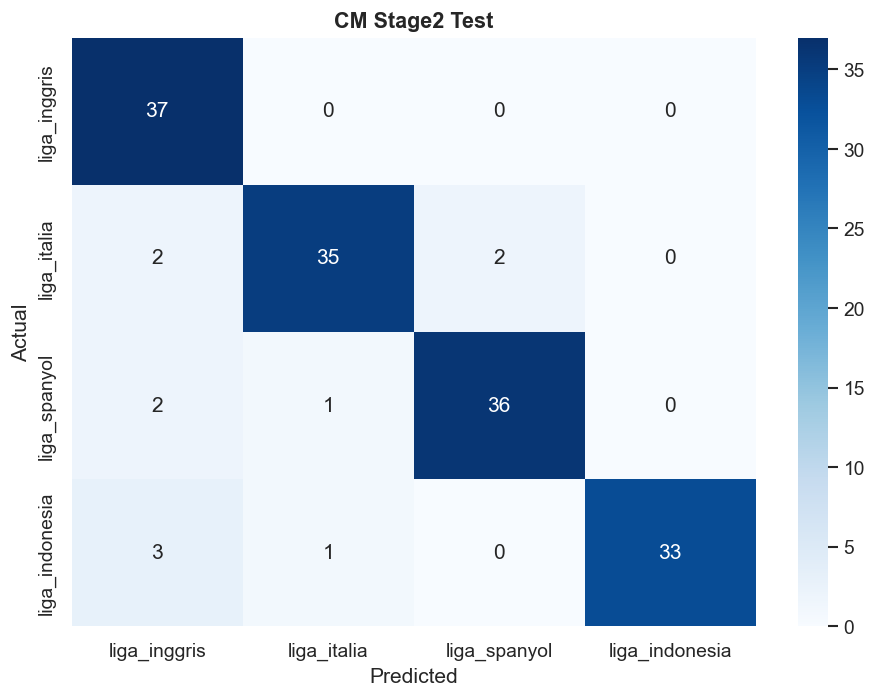

,Model,Stage,Dataset,Accuracy,Precision,Recall,F1
0,Model 2,Stage 2,Train,0.9695,0.9716,0.9695,0.9695
1,Model 2,Stage 2,Validation,0.9272,0.9368,0.9272,0.9276
2,Model 2,Stage 2,Test,0.9276,0.9339,0.9276,0.9281


Hasil evaluasi Stage 2 berhasil disimpan.
- Evaluation metrics : output\evaluation_stage2.csv
- Test report        : output\classification_report_stage2_test.csv


In [ ]:
print('=' * 60)
print('Evaluasi Stage 2 - TEST')
print('=' * 60)
pred_s2_test, true_s2_test = evaluate(model_s2, df_s2_test, label_col='label_stage2')
print(classification_report(true_s2_test, pred_s2_test, target_names=target_s2))
plot_confusion_matrix(
    true_s2_test,
    pred_s2_test,
    target_s2,
    'CM Stage2 Test',
    save_path=os.path.join(OUTPUT_DIR, 'cm_stage2_test.png')
)

stage2_test_summary = summarize_evaluation('Model 2', 'Test', true_s2_test, pred_s2_test)
stage2_test_summary['Stage'] = 'Stage 2'
model2_stage2_eval_results.append(stage2_test_summary)

model2_stage2_eval_df = pd.DataFrame(model2_stage2_eval_results)
model2_stage2_eval_df = model2_stage2_eval_df[['Model', 'Stage', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1']]
display(model2_stage2_eval_df)

EVALUATION_STAGE2_PATH = os.path.join(OUTPUT_DIR, 'evaluation_stage2.csv')
REPORT_STAGE2_TEST_PATH = os.path.join(OUTPUT_DIR, 'classification_report_stage2_test.csv')

model2_stage2_eval_df.to_csv(EVALUATION_STAGE2_PATH, index=False, encoding='utf-8-sig')
classification_report_stage2_test_df = pd.DataFrame(
    classification_report(
        true_s2_test,
        pred_s2_test,
        target_names=target_s2,
        output_dict=True
    )
).transpose()
classification_report_stage2_test_df.to_csv(REPORT_STAGE2_TEST_PATH, encoding='utf-8-sig')

# Simpan metrics Stage 2 untuk kompatibilitas perbandingan akhir
stage2_test_metrics = model2_stage2_eval_df[model2_stage2_eval_df['Dataset'] == 'Test'].iloc[0]
acc_s2 = stage2_test_metrics['Accuracy']
prec_s2 = stage2_test_metrics['Precision']
rec_s2 = stage2_test_metrics['Recall']
f1_s2 = stage2_test_metrics['F1']

print('Hasil evaluasi Stage 2 berhasil disimpan.')
print(f'- Evaluation metrics : {EVALUATION_STAGE2_PATH}')
print(f'- Test report        : {REPORT_STAGE2_TEST_PATH}')


Evaluasi Model 2 - END-TO-END TEST
Menjalankan pipeline dua tahap pada test set...

Classification Report End-to-End Model 2:

                precision    recall  f1-score   support

  liga_inggris       0.89      1.00      0.94        31
   liga_italia       1.00      0.98      0.99        41
  liga_spanyol       0.98      0.95      0.97        44
liga_indonesia       1.00      0.97      0.99        36
non_sepak_bola       1.00      0.99      0.99        76

      accuracy                           0.98       228
     macro avg       0.97      0.98      0.97       228
  weighted avg       0.98      0.98      0.98       228

Ringkasan Evaluasi End-to-End
Accuracy : 0.9781 (97.81%)
Precision: 0.9800
Recall   : 0.9781
F1-score : 0.9785


,Model,Stage,Dataset,Accuracy,Precision,Recall,F1
0,Model 2,End-to-End,Test,0.9781,0.98,0.9781,0.9785


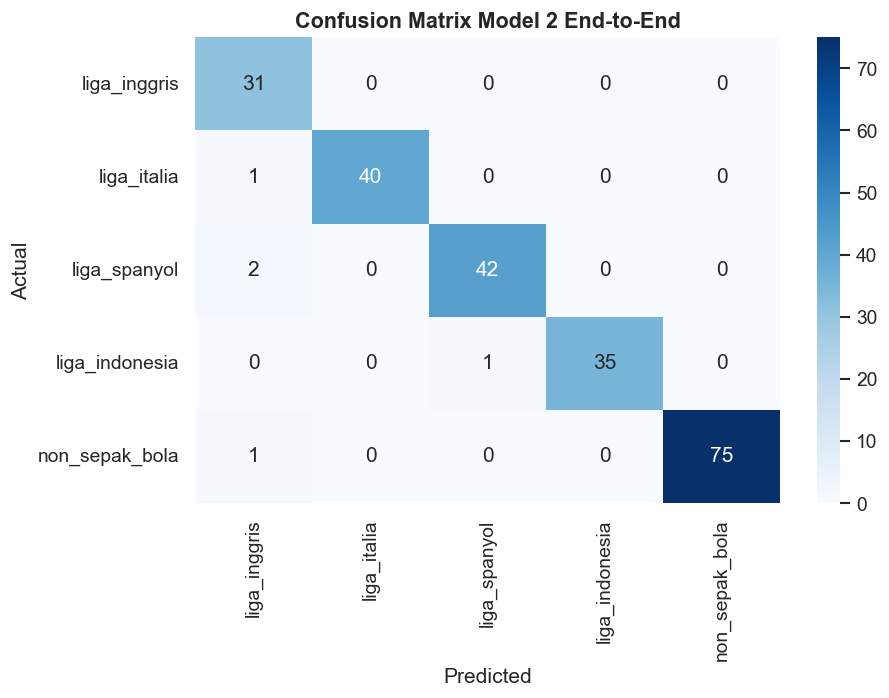


Hasil evaluasi berhasil disimpan:
- Evaluation : output\evaluation_model2_end_to_end.csv
- Report     : output\classification_report_model2_end_to_end.csv
- Confusion Matrix : output\cm_model2_end_to_end.png


In [ ]:
print("=" * 60)
print("Evaluasi Model 2 - END-TO-END TEST")
print("=" * 60)

id2label_stage2 = {v: k for k, v in labels_stage2.items()}

def predict_two_stage(model_stage1, model_stage2, df_input):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_stage1.to(device)
    model_stage2.to(device)

    model_stage1.eval()
    model_stage2.eval()

    df_stage1 = df_input.copy()

    if "label_stage1" not in df_stage1.columns:
        df_stage1["label_stage1"] = 0

    dataset_stage1 = NewsDataset(
        df_stage1,
        label_col="label_stage1"
    )

    loader_stage1 = DataLoader(
        dataset_stage1,
        batch_size=8,
        shuffle=False
    )

    preds_stage1 = []
    with torch.no_grad():
        for batch_input, _ in loader_stage1:
            input_ids = batch_input["input_ids"].squeeze(1).to(device)
            attention_mask = batch_input["attention_mask"].to(device)
            logits = model_stage1(
                input_ids,
                attention_mask
            )
            preds_stage1.extend(
                logits.argmax(dim=1).cpu().numpy()
            )

    final_preds = [
        "non_sepak_bola" if pred == 1 else None
        for pred in preds_stage1
    ]

    soccer_positions = [
        i for i, pred in enumerate(preds_stage1)
        if pred == 0
    ]

    if len(soccer_positions) > 0:
        df_soccer = df_input.iloc[soccer_positions].copy()
        if "label_stage2" not in df_soccer.columns:
            df_soccer["label_stage2"] = 0

        dataset_stage2 = NewsDataset(
            df_soccer,
            label_col="label_stage2"
        )

        loader_stage2 = DataLoader(
            dataset_stage2,
            batch_size=8,
            shuffle=False
        )

        preds_stage2 = []

        with torch.no_grad():
            for batch_input, _ in loader_stage2:
                input_ids = batch_input["input_ids"].squeeze(1).to(device)
                attention_mask = batch_input["attention_mask"].to(device)
                logits = model_stage2(
                    input_ids,
                    attention_mask
                )
                preds_stage2.extend(
                    logits.argmax(dim=1).cpu().numpy()
                )
        for idx, pred in zip(soccer_positions, preds_stage2):
            final_preds[idx] = id2label_stage2[pred]

    return final_preds


print("Menjalankan pipeline dua tahap pada test set...")

e2e_preds = predict_two_stage(
    model_s1,
    model_s2,
    df_s1_test
)

true_labels_e2e = df_s1_test["label"].tolist()
target_names_e2e = list(labels_model1.keys())

print()
print("Classification Report End-to-End Model 2:")
print()

print(
    classification_report(
        true_labels_e2e,
        e2e_preds,
        labels=target_names_e2e,
        target_names=target_names_e2e
    )
)

true_enc = [
    labels_model1[label]
    for label in true_labels_e2e
]

pred_enc = [
    labels_model1[label]
    for label in e2e_preds
]

acc_m2_e2e = accuracy_score(
    true_enc,
    pred_enc
)

prec_m2_e2e = precision_score(
    true_enc,
    pred_enc,
    average="weighted"
)

rec_m2_e2e = recall_score(
    true_enc,
    pred_enc,
    average="weighted"
)

f1_m2_e2e = f1_score(
    true_enc,
    pred_enc,
    average="weighted"
)

print("=" * 60)
print("Ringkasan Evaluasi End-to-End")
print("=" * 60)
print(f"Accuracy : {acc_m2_e2e:.4f} ({acc_m2_e2e*100:.2f}%)")
print(f"Precision: {prec_m2_e2e:.4f}")
print(f"Recall   : {rec_m2_e2e:.4f}")
print(f"F1-score : {f1_m2_e2e:.4f}")

model2_end_to_end_df = pd.DataFrame([
    {
        "Model": "Model 2",
        "Stage": "End-to-End",
        "Dataset": "Test",
        "Accuracy": round(acc_m2_e2e, 4),
        "Precision": round(prec_m2_e2e, 4),
        "Recall": round(rec_m2_e2e, 4),
        "F1": round(f1_m2_e2e, 4)
    }
])

display(model2_end_to_end_df)

plot_confusion_matrix(
    true_enc,
    pred_enc,
    target_names_e2e,
    "Confusion Matrix Model 2 End-to-End",
    save_path=os.path.join(
        OUTPUT_DIR,
        "cm_model2_end_to_end.png"
    )
)

EVALUATION_MODEL2_E2E_PATH = os.path.join(
    OUTPUT_DIR,
    "evaluation_model2_end_to_end.csv"
)

REPORT_MODEL2_E2E_PATH = os.path.join(
    OUTPUT_DIR,
    "classification_report_model2_end_to_end.csv"
)

CM_MODEL2_E2E_PATH = os.path.join(
    OUTPUT_DIR,
    "cm_model2_end_to_end.png"
)

model2_end_to_end_df.to_csv(
    EVALUATION_MODEL2_E2E_PATH,
    index=False,
    encoding="utf-8-sig"
)

classification_report_model2_e2e_df = pd.DataFrame(
    classification_report(
        true_labels_e2e,
        e2e_preds,
        labels=target_names_e2e,
        target_names=target_names_e2e,
        output_dict=True
    )
).transpose()

classification_report_model2_e2e_df.to_csv(
    REPORT_MODEL2_E2E_PATH,
    encoding="utf-8-sig"
)

print()
print("Hasil evaluasi berhasil disimpan:")
print(f"- Evaluation : {EVALUATION_MODEL2_E2E_PATH}")
print(f"- Report     : {REPORT_MODEL2_E2E_PATH}")
print(f"- Confusion Matrix : {CM_MODEL2_E2E_PATH}")

## Penjelasan Arsitektur Model 2

Model kedua dibangun menggunakan pendekatan **Two-Stage Classification**, yaitu proses klasifikasi dilakukan secara bertahap menggunakan dua model yang berbeda.

Pada pendekatan ini, model tidak langsung mengklasifikasikan berita ke lima kategori sekaligus, melainkan membaginya menjadi dua tahap.

**Stage 1** bertugas mengidentifikasi apakah sebuah berita termasuk kategori:

- Sepak Bola
- Non Sepak Bola

Apabila hasil prediksi pada Stage 1 adalah **Non Sepak Bola**, maka proses klasifikasi berhenti dan hasil akhir langsung diberikan.

Sebaliknya, apabila hasil Stage 1 adalah **Sepak Bola**, maka berita tersebut akan diteruskan ke **Stage 2** untuk diklasifikasikan kembali menjadi salah satu dari empat liga berikut.

- Liga Inggris
- Liga Italia
- Liga Spanyol
- Liga Indonesia

Pendekatan ini bertujuan untuk menyederhanakan proses klasifikasi. Stage 1 hanya berfokus membedakan berita sepak bola dan non sepak bola, sedangkan Stage 2 hanya mempelajari perbedaan antar liga sehingga setiap model memiliki tugas yang lebih spesifik.

Kedua stage menggunakan arsitektur yang sama, yaitu:

**IndoBERT → Dropout → Fully Connected (Linear Layer)**

Perbedaannya hanya terletak pada jumlah neuron pada output layer.

- **Stage 1** menggunakan **2 neuron** karena merupakan klasifikasi biner.
- **Stage 2** menggunakan **4 neuron** karena hanya mengklasifikasikan empat liga sepak bola.

Berdasarkan hasil inisialisasi model diperoleh:

- Parameter Stage 1 : **124.442.882**
- Parameter Stage 2 : **124.444.420**

Seluruh parameter bersifat **trainable**, sehingga proses fine-tuning dilakukan pada seluruh bobot IndoBERT untuk masing-masing stage.

## Hyperparameter Tuning Model 2

Proses hyperparameter tuning dilakukan secara terpisah pada Stage 1 dan Stage 2.

Hyperparameter yang dibandingkan meliputi:

- Learning Rate
- Batch Size
- Jumlah Epoch
- Dropout

Konfigurasi yang diuji pada kedua stage adalah sebagai berikut.

| Konfigurasi | Learning Rate | Batch Size | Epoch | Dropout |
|-------------|--------------|-----------|-------|----------|
| Config A | 2e-5 | 8 | 3 | 0.3 |
| Config B | 3e-5 | 16 | 3 | 0.3 |

Pemilihan konfigurasi terbaik dilakukan berdasarkan **Validation F1-score** karena metrik tersebut mempertimbangkan keseimbangan antara Precision dan Recall.

### Stage 1

Hasil tuning menunjukkan bahwa kedua konfigurasi menghasilkan performa yang sangat tinggi.

| Config | Validation Accuracy | Validation F1 |
|---------|--------------------|---------------|
| A | 100% | 100% |
| B | 100% | 100% |

Karena kedua konfigurasi memperoleh performa yang sama, dipilih **Config A** karena menggunakan learning rate yang lebih kecil sehingga proses fine-tuning cenderung lebih stabil.

---

### Stage 2

Pada Stage 2 diperoleh hasil sebagai berikut.

| Config | Validation Accuracy | Validation F1 |
|---------|--------------------|---------------|
| A | **96.03%** | **96.03%** |
| B | **96.03%** | **96.02%** |

Kedua konfigurasi menghasilkan Validation Accuracy yang sama, namun Config A memiliki Validation F1-score sedikit lebih tinggi serta waktu training yang jauh lebih singkat (142 detik dibandingkan 1693 detik). Oleh karena itu Config A dipilih sebagai konfigurasi terbaik untuk Stage 2.

## Analisis Proses Training

### Stage 1

Selama proses training, Stage 1 menunjukkan proses konvergensi yang sangat cepat.

Train Loss turun drastis dari **0,087** menjadi **0,004**, sedangkan Validation Loss turun dari **0,030** hingga mencapai **0,000** pada epoch terakhir.

Train Accuracy meningkat dari **96,6%** menjadi **99,9%**, sedangkan Validation Accuracy meningkat dari **99,1%** menjadi **100%**.

Hal ini menunjukkan bahwa membedakan berita sepak bola dan non sepak bola merupakan tugas yang relatif mudah karena kedua kategori memiliki karakteristik yang cukup berbeda.

---

### Stage 2

Pada Stage 2 proses training berlangsung lebih menantang dibandingkan Stage 1.

Train Loss menurun secara konsisten dari **0,420** menjadi **0,117**, sedangkan Validation Loss turun dari **0,175** menjadi **0,163** pada epoch kedua, kemudian meningkat menjadi **0,254** pada epoch ketiga.

Train Accuracy meningkat dari **86,3%** menjadi **96,9%**, sedangkan Validation Accuracy mencapai nilai terbaik sebesar **96,0%** pada epoch pertama dan kedua, kemudian menurun menjadi **92,7%** pada epoch ketiga.

Hasil tersebut menunjukkan bahwa Stage 2 mulai mengalami gejala overfitting setelah epoch kedua. Oleh karena itu model terbaik dipilih berdasarkan checkpoint dengan Validation F1-score tertinggi, yaitu pada epoch pertama.

## Analisis Learning Curve

### Stage 1

Learning curve menunjukkan proses training yang sangat stabil.

Train Loss maupun Validation Loss terus mengalami penurunan hingga mendekati nol, sedangkan Train Accuracy dan Validation Accuracy meningkat hingga hampir mencapai 100%.

Jarak antara kurva training dan validation juga sangat kecil sehingga tidak terlihat adanya gejala overfitting yang signifikan.

---

### Stage 2

Learning curve menunjukkan bahwa Train Loss terus mengalami penurunan pada setiap epoch.

Namun Validation Loss hanya menurun hingga epoch kedua, kemudian meningkat cukup signifikan pada epoch ketiga dari **0,163** menjadi **0,254**. Penurunan Validation Accuracy dari **96,0%** menjadi **92,7%** pada epoch terakhir juga mengindikasikan mulai munculnya gejala overfitting.

Oleh karena itu, checkpoint terbaik dipilih berdasarkan nilai Validation F1-score tertinggi, yaitu pada epoch pertama.

## Analisis Confusion Matrix

### Stage 1

Confusion matrix menunjukkan bahwa hampir seluruh data berhasil diprediksi dengan benar.

Pada data training hanya terdapat **1 berita Non Sepak Bola** yang diprediksi sebagai Sepak Bola.

Pada data validation seluruh **228 data** berhasil diklasifikasikan dengan benar sehingga memperoleh Accuracy sebesar **100%**.

Pada data testing hanya terdapat **1 berita Non Sepak Bola** yang diprediksi sebagai Sepak Bola sehingga Accuracy mencapai **99,56%**.

Hasil ini menunjukkan bahwa Stage 1 sangat efektif dalam memisahkan berita sepak bola dan non sepak bola.

---

### Stage 2

Sebagian besar prediksi berada pada diagonal utama yang menunjukkan bahwa model mampu mengenali sebagian besar kelas dengan benar.

Kesalahan klasifikasi masih didominasi oleh pertukaran antar liga yang memiliki karakteristik berita serupa, antara lain:

- Liga Italia diprediksi sebagai Liga Inggris.
- Liga Italia diprediksi sebagai Liga Spanyol.
- Liga Spanyol diprediksi sebagai Liga Inggris.
- Liga Spanyol diprediksi sebagai Liga Italia.
- Liga Indonesia diprediksi sebagai Liga Inggris.
- Liga Indonesia diprediksi sebagai Liga Italia.

Kesalahan tersebut masih wajar karena berita dari berbagai liga memiliki banyak kosakata, nama pemain, nama klub, dan istilah pertandingan yang saling tumpang tindih.

## Analisis Hasil Evaluasi

### Evaluasi Stage 1

| Dataset | Accuracy | Precision | Recall | F1-score |
|---------|----------|-----------|--------|----------|
| Train | 99.84% | 99.84% | 99.84% | 99.84% |
| Validation | 100.00% | 100.00% | 100.00% | 100.00% |
| Test | 99.56% | 99.56% | 99.56% | 99.56% |

Stage 1 menghasilkan performa yang hampir sempurna pada seluruh dataset. Hal ini menunjukkan bahwa model mampu membedakan berita sepak bola dan non sepak bola dengan sangat baik.

---

### Evaluasi Stage 2

| Dataset    |   Accuracy |  Precision |     Recall |   F1-score |
| ---------- | ---------: | ---------: | ---------: | ---------: |
| Train      | **96.95%** | **97.16%** | **96.95%** | **96.95%** |
| Validation | **92.72%** | **93.68%** | **92.72%** | **92.76%** |
| Test       | **92.76%** | **93.39%** | **92.76%** | **92.81%** |


Stage 2 memberikan performa yang lebih rendah dibandingkan Stage 1 karena model harus membedakan empat liga sepak bola yang memiliki konteks berita, nama pemain, dan istilah pertandingan yang sangat mirip.

Meskipun demikian, seluruh metrik evaluasi tetap berada di atas **92%**, sehingga menunjukkan bahwa model masih mampu melakukan klasifikasi antar liga dengan baik.

## Evaluasi End-to-End Model 2

Setelah kedua stage selesai dilatih, dilakukan evaluasi terhadap keseluruhan pipeline (End-to-End). Pada tahap ini setiap berita terlebih dahulu diprediksi menggunakan **Stage 1** untuk menentukan apakah berita termasuk kategori **sepak bola** atau **non sepak bola**.

* Jika hasil prediksi Stage 1 adalah **non sepak bola**, maka prediksi tersebut langsung menjadi hasil akhir.
* Jika hasil prediksi Stage 1 adalah **sepak bola**, maka berita diteruskan ke **Stage 2** untuk diklasifikasikan ke salah satu dari empat liga, yaitu Liga Inggris, Liga Italia, Liga Spanyol, atau Liga Indonesia.

Hasil evaluasi end-to-end pada data testing ditunjukkan pada tabel berikut.

| Dataset |   Accuracy |  Precision |     Recall |   F1-score |
| ------- | ---------: | ---------: | ---------: | ---------: |
| Test    | **97.81%** | **98.00%** | **97.81%** | **97.85%** |

Berdasarkan hasil evaluasi, pipeline Two-Stage menghasilkan Accuracy sebesar **97,81%**, Precision **98,00%**, Recall **97,81%**, dan F1-score **97,85%** pada data testing.

Confusion matrix menunjukkan bahwa sebagian besar prediksi berada pada diagonal utama. Kesalahan klasifikasi hanya terjadi pada beberapa berita antar liga yang memiliki konteks sangat mirip, sedangkan kelas Non Sepak Bola hampir seluruhnya berhasil dikenali dengan benar.

Hasil ini menunjukkan bahwa pendekatan Two-Stage mampu memberikan performa yang tinggi. Stage 1 berhasil memisahkan berita sepak bola dan non sepak bola dengan hampir sempurna, sedangkan Stage 2 bertugas membedakan antar liga sepak bola yang memiliki karakteristik lebih kompleks. Kombinasi kedua stage tersebut menghasilkan sistem klasifikasi yang akurat dan mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat sebelumnya.


## 3. Perbandingan Model 1 vs Model 2

Bagian ini membandingkan hasil pendekatan one-stage dan two-stage berdasarkan metrik evaluasi yang sudah dihitung pada bagian sebelumnya. Perbandingan difokuskan pada performa data training, validation, dan testing, kemudian diringkas menggunakan hasil test set untuk melihat model mana yang lebih layak digunakan.

## Metode Evaluasi

Evaluasi dilakukan pada tiga subset data, yaitu training, validation, dan testing. Metrik yang digunakan adalah Accuracy, Precision, Recall, dan F1-score, dengan Precision, Recall, dan F1-score dihitung menggunakan weighted average agar tetap mempertimbangkan proporsi jumlah data pada setiap kelas. Selain metrik numerik, confusion matrix juga digunakan untuk melihat distribusi prediksi model pada masing-masing kelas sehingga kesalahan klasifikasi dapat diamati secara lebih jelas.

### Hasil Evaluasi Model 1

Model 1 dievaluasi sebagai classifier one-stage yang langsung memprediksi lima kelas berita. Tabel berikut menampilkan hasil evaluasi pada train, validation, dan test set yang sudah dihitung pada bagian evaluasi Model 1.

In [ ]:
display(model1_eval_df)

,Model,Dataset,Accuracy,Precision,Recall,F1
0,Model 1,Train,0.9857,0.9858,0.9857,0.9857
1,Model 1,Validation,0.9693,0.9705,0.9693,0.9694
2,Model 1,Test,0.9781,0.9786,0.9781,0.9781


### Hasil Evaluasi Model 2

Model 2 dievaluasi pada tiga level, yaitu Stage 1, Stage 2, dan end-to-end. Stage 1 mengevaluasi klasifikasi biner sepak bola vs non-sepak bola, Stage 2 mengevaluasi klasifikasi empat liga pada data sepak bola, sedangkan end-to-end mengevaluasi hasil akhir pipeline two-stage pada test set.

In [ ]:
print('Hasil Evaluasi Model 2 - Stage 1')
display(model2_stage1_eval_df)

print('Hasil Evaluasi Model 2 - Stage 2')
display(model2_stage2_eval_df)

print('Hasil Evaluasi Model 2 - End-to-End')
display(model2_end_to_end_df)

Hasil Evaluasi Model 2 - Stage 1


,Model,Stage,Dataset,Accuracy,Precision,Recall,F1
0,Model 2,Stage 1,Train,0.9995,0.9995,0.9995,0.9995
1,Model 2,Stage 1,Validation,1.0000,1.0000,1.0000,1.0000
2,Model 2,Stage 1,Test,0.9956,0.9956,0.9956,0.9956


Hasil Evaluasi Model 2 - Stage 2


,Model,Stage,Dataset,Accuracy,Precision,Recall,F1
0,Model 2,Stage 2,Train,0.9695,0.9716,0.9695,0.9695
1,Model 2,Stage 2,Validation,0.9272,0.9368,0.9272,0.9276
2,Model 2,Stage 2,Test,0.9276,0.9339,0.9276,0.9281


Hasil Evaluasi Model 2 - End-to-End


,Model,Stage,Dataset,Accuracy,Precision,Recall,F1
0,Model 2,End-to-End,Test,0.9781,0.98,0.9781,0.9785


### Tabel Perbandingan Model 1 vs Model 2

Tabel berikut membandingkan Model 1 dan Model 2 menggunakan hasil test set. Model 1 menggunakan hasil evaluasi test dari classifier one-stage, sedangkan Model 2 menggunakan hasil evaluasi end-to-end karena output tersebut merepresentasikan keseluruhan pipeline two-stage.

In [ ]:
total_time_m2 = time_s1 + time_s2

comparison_final_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (sec)",
        "Jumlah Model",
        "Pipeline"
    ],

    "Model 1 (One-Stage)":[
        acc_m1,
        prec_m1,
        rec_m1,
        f1_m1,
        round(train_time_m1,2),
        1,
        "Single Stage"
    ],

    "Model 2 (Two-Stage)":[
        acc_m2_e2e,
        prec_m2_e2e,
        rec_m2_e2e,
        f1_m2_e2e,
        round(total_time_m2,2),
        2,
        "Stage 1 + Stage 2"
    ]

})

print("PERBANDINGAN AKHIR MODEL 1 DAN MODEL 2")
display(comparison_final_df)

COMPARISON_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "comparison_model1_vs_model2.csv"
)

comparison_final_df.to_csv(
    COMPARISON_MODEL_PATH,
    index=False,
    encoding="utf-8-sig"
)

PERBANDINGAN AKHIR MODEL 1 DAN MODEL 2


,Metric,Model 1 (One-Stage),Model 2 (Two-Stage)
0,Accuracy,0.9781,0.97807
1,Precision,0.9786,0.979973
2,Recall,0.9781,0.97807
3,F1-score,0.9781,0.978454
4,Training Time (sec),148.59,293.63
5,Jumlah Model,1,2
6,Pipeline,Single Stage,Stage 1 + Stage 2


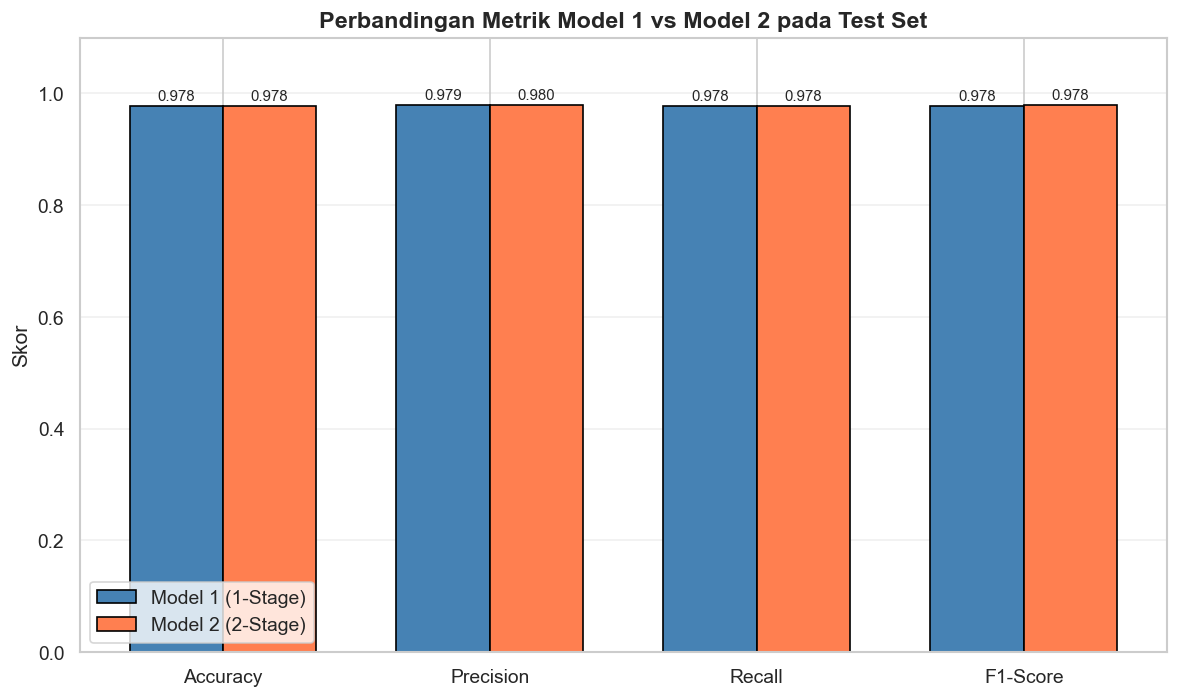

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
val_m1 = [acc_m1, prec_m1, rec_m1, f1_m1]
val_m2 = [acc_m2_e2e, prec_m2_e2e, rec_m2_e2e, f1_m2_e2e]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, val_m1, width, label='Model 1 (1-Stage)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width / 2, val_m2, width, label='Model 2 (2-Stage)', color='coral', edgecolor='black')

ax.set_title('Perbandingan Metrik Model 1 vs Model 2 pada Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Skor')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center',
        fontsize=9
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
COMPARISON_MODEL_PATH = os.path.join(OUTPUT_DIR, 'comparison_models.png')
plt.savefig(COMPARISON_MODEL_PATH, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("RINGKASAN HASIL EVALUASI SELURUH MODEL")

summary_model1 = model1_eval_df.copy()
summary_model1["Model"] = "Model 1 (One-Stage)"
summary_model1 = summary_model1[
    ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1"]
]

summary_stage1 = model2_stage1_eval_df.copy()
summary_stage1["Model"] = "Model 2 - Stage 1"
summary_stage1 = summary_stage1[
    ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1"]
]

summary_stage2 = model2_stage2_eval_df.copy()
summary_stage2["Model"] = "Model 2 - Stage 2"
summary_stage2 = summary_stage2[
    ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1"]
]

summary_e2e = model2_end_to_end_df.copy()
summary_e2e["Model"] = "Model 2 (End-to-End)"
summary_e2e = summary_e2e[
    ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1"]
]

summary_all_models = pd.concat(
    [
        summary_model1,
        summary_stage1,
        summary_stage2,
        summary_e2e
    ],
    ignore_index=True
)

display(summary_all_models)

SUMMARY_ALL_MODELS_PATH = os.path.join(
    OUTPUT_DIR,
    "summary_all_models.csv"
)

summary_all_models.to_csv(
    SUMMARY_ALL_MODELS_PATH,
    index=False,
    encoding="utf-8-sig"
)

RINGKASAN HASIL EVALUASI SELURUH MODEL


,Model,Dataset,Accuracy,Precision,Recall,F1
0,Model 1 (One-Stage),Train,0.9857,0.9858,0.9857,0.9857
1,Model 1 (One-Stage),Validation,0.9693,0.9705,0.9693,0.9694
2,Model 1 (One-Stage),Test,0.9781,0.9786,0.9781,0.9781
3,Model 2 - Stage 1,Train,0.9995,0.9995,0.9995,0.9995
4,Model 2 - Stage 1,Validation,1.0000,1.0000,1.0000,1.0000
5,Model 2 - Stage 1,Test,0.9956,0.9956,0.9956,0.9956
6,Model 2 - Stage 2,Train,0.9695,0.9716,0.9695,0.9695
7,Model 2 - Stage 2,Validation,0.9272,0.9368,0.9272,0.9276
8,Model 2 - Stage 2,Test,0.9276,0.9339,0.9276,0.9281
9,Model 2 (End-to-End),Test,0.9781,0.9800,0.9781,0.9785


## Analisis Hasil Perbandingan

Berdasarkan hasil evaluasi pada data training, validation, dan testing, kedua model menunjukkan performa yang sangat baik dalam melakukan klasifikasi berita olahraga. Evaluasi dilakukan menggunakan empat metrik utama, yaitu Accuracy, Precision, Recall, dan F1-score, sedangkan confusion matrix digunakan untuk menganalisis distribusi prediksi pada setiap kelas serta mengidentifikasi kesalahan klasifikasi yang masih terjadi.

Pada Model 1 (One-Stage), proses klasifikasi dilakukan secara langsung ke lima kategori menggunakan satu model IndoBERT. Hasil evaluasi menunjukkan bahwa model memperoleh Accuracy sebesar 98,57% pada data training, 96,93% pada data validation, dan 97,81% pada data testing. Nilai Precision, Recall, dan F1-score juga berada pada kisaran 97–98%, menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Sementara itu, Model 2 (Two-Stage) membagi proses klasifikasi menjadi dua tahap. Stage 1 bertugas membedakan berita menjadi kategori sepak bola dan non-sepak bola, sedangkan Stage 2 mengklasifikasikan berita sepak bola ke dalam empat liga, yaitu Liga Inggris, Liga Italia, Liga Spanyol, dan Liga Indonesia. Hasil evaluasi menunjukkan bahwa Stage 1 memiliki performa yang sangat tinggi dengan Accuracy sebesar 99,56% pada data testing, sedangkan Stage 2 memperoleh Accuracy sebesar 92,76% karena harus membedakan kelas-kelas yang memiliki karakteristik dan kosakata yang lebih mirip.

Setelah kedua tahap digabungkan menjadi satu pipeline End-to-End, Model 2 memperoleh Accuracy sebesar 97,81%, Precision sebesar 98,00%, Recall sebesar 97,81%, dan F1-score sebesar 97,85% pada data testing. Sementara itu, Model 1 memperoleh Accuracy sebesar 97,81%, Precision sebesar 97,86%, Recall sebesar 97,81%, dan F1-score sebesar 97,81%.

Hasil tersebut menunjukkan bahwa kedua pendekatan menghasilkan Accuracy dan Recall yang hampir identik, sedangkan Model 2 hanya memberikan peningkatan yang sangat kecil pada Precision dan F1-score. Dengan demikian, berdasarkan dataset yang digunakan pada penelitian ini, pendekatan Two-Stage belum memberikan peningkatan performa yang signifikan dibandingkan pendekatan One-Stage, meskipun memiliki mekanisme klasifikasi yang lebih kompleks.

Di sisi lain, peningkatan metrik yang relatif kecil tersebut diperoleh dengan konsekuensi bahwa Model 2 membutuhkan dua model IndoBERT yang dijalankan secara berurutan. Akibatnya, waktu training menjadi sekitar 293,63 detik, hampir dua kali lebih lama dibandingkan Model 1 yang hanya membutuhkan sekitar 148,59 detik. Selain itu, proses inferensi pada Model 2 juga lebih kompleks karena setiap berita harus melewati dua tahap prediksi sebelum menghasilkan klasifikasi akhir.

Secara keseluruhan, Model 1 (One-Stage) memiliki keunggulan dari sisi kesederhanaan arsitektur, efisiensi komputasi, dan waktu training, namun tetap mampu menghasilkan performa yang hampir sama dengan Model 2 (Two-Stage). Sementara itu, Model 2 menawarkan Precision dan F1-score yang sedikit lebih tinggi, tetapi membutuhkan biaya komputasi dan kompleksitas implementasi yang lebih besar. Oleh karena itu, untuk penelitian ini, Model 1 dapat dianggap sebagai pilihan yang lebih efisien karena memberikan performa yang sebanding dengan Model 2 menggunakan arsitektur yang lebih sederhana, sedangkan Model 2 menjadi alternatif apabila peningkatan kecil pada metrik evaluasi dianggap lebih penting daripada efisiensi komputasi.

# Kesimpulan

Pada penelitian ini telah berhasil dibangun sistem klasifikasi berita olahraga berbahasa Indonesia menggunakan pendekatan **Large Language Model (LLM)** berbasis **IndoBERT (`indobenchmark/indobert-base-p1`)**. Dataset yang digunakan diperoleh melalui proses *web scraping* dari tiga media berita daring, yaitu **Detik**, **Kompas**, dan **Liputan6**, dengan total **2.276 artikel** yang terbagi ke dalam lima kategori, yaitu **Liga Inggris, Liga Italia, Liga Spanyol, Liga Indonesia,** dan **Non Sepak Bola**.

Sebelum proses pemodelan dilakukan, data terlebih dahulu melalui tahapan *light text preprocessing* yang meliputi **case folding**, penghapusan artefak hasil *web scraping*, **HTML tag**, **URL**, **mention**, **emoji**, serta normalisasi spasi. Pendekatan *light preprocessing* dipilih karena lebih sesuai untuk proses *fine-tuning* IndoBERT, sehingga informasi penting seperti tanda baca, angka, dan struktur kalimat tetap dipertahankan agar model dapat memanfaatkan konteks bahasa secara optimal.

Pada tahap pemodelan dibangun dua pendekatan klasifikasi yang berbeda. **Model 1** menggunakan pendekatan **One-Stage**, yaitu mengklasifikasikan artikel secara langsung ke dalam lima kelas menggunakan satu model IndoBERT. Sementara itu, **Model 2** menggunakan pendekatan **Two-Stage**, di mana tahap pertama membedakan artikel menjadi kategori **Sepak Bola** dan **Non Sepak Bola**, kemudian artikel yang diprediksi sebagai berita sepak bola diteruskan ke tahap kedua untuk diklasifikasikan ke dalam empat kategori liga.

Untuk masing-masing model dilakukan proses **hyperparameter tuning** menggunakan dua konfigurasi yang berbeda dengan variasi **learning rate**, **batch size**, dan **dropout**. Konfigurasi terbaik dipilih berdasarkan nilai **Validation F1-score** sebelum dilakukan evaluasi pada data testing.

Evaluasi dilakukan menggunakan tiga subset data, yaitu **training**, **validation**, dan **testing**, dengan metrik **Accuracy**, **Precision**, **Recall**, dan **F1-score**. Selain itu, **confusion matrix** dan **classification report** digunakan untuk memberikan analisis yang lebih rinci mengenai performa klasifikasi pada setiap kelas.

Berdasarkan hasil pengujian, kedua model menunjukkan performa yang sangat baik. **Model 1 (One-Stage)** memperoleh **Accuracy sebesar 97,81%**, **Precision sebesar 97,86%**, **Recall sebesar 97,81%**, dan **F1-score sebesar 97,81%** pada data testing. Sementara itu, **Model 2 (Two-Stage End-to-End)** memperoleh **Accuracy sebesar 97,81%**, **Precision sebesar 98,00%**, **Recall sebesar 97,81%**, dan **F1-score sebesar 97,85%**. Hasil tersebut menunjukkan bahwa kedua pendekatan memiliki kemampuan klasifikasi yang hampir setara, dengan Model 2 hanya memberikan peningkatan yang sangat kecil pada metrik Precision dan F1-score.

Di sisi lain, peningkatan performa tersebut diperoleh dengan konsekuensi bahwa **Model 2** menggunakan dua model IndoBERT yang dijalankan secara berurutan, sehingga membutuhkan waktu training sekitar **293,63 detik**, hampir dua kali lebih lama dibandingkan **Model 1** yang hanya memerlukan sekitar **148,59 detik**. Selain itu, proses inferensi pada Model 2 juga lebih kompleks karena setiap artikel harus melewati dua tahap prediksi sebelum menghasilkan klasifikasi akhir.

Secara keseluruhan, penelitian ini menunjukkan bahwa pendekatan berbasis **IndoBERT** mampu memberikan performa yang sangat baik untuk tugas klasifikasi berita olahraga berbahasa Indonesia. Berdasarkan hasil eksperimen, **Model 1 (One-Stage)** menjadi pilihan yang lebih efisien karena mampu menghasilkan performa yang hampir sama dengan **Model 2**, namun menggunakan arsitektur yang lebih sederhana, waktu komputasi yang lebih singkat, dan proses implementasi yang lebih mudah. Sementara itu, **Model 2 (Two-Stage)** dapat menjadi alternatif apabila peningkatan kecil pada Precision dan F1-score dianggap lebih penting dibandingkan efisiensi komputasi dan kompleksitas sistem.
